# Tutorial for visualizing predicates

In [1]:
from commonroad.common.file_reader import CommonRoadFileReader
import sys
import os
path_notebook = os.getcwd()

# add the crmonitor folder to python path
sys.path.append(os.path.join(path_notebook, "../"))

from crmonitor.common.world import World
from crmonitor.evaluation.evaluation import RuleEvaluator
from crmonitor.evaluation.visualization import plot_rule_visualization

from matplotlib import pyplot as plt
from commonroad.visualization.mp_renderer import MPRenderer

## Load scenario & plot

In [2]:
# scenario_name = "USA_US101-15_2_T-1" # take this alternatively for having a non-horizontal road orientation...
scenario_name = 'test_interstate/DEU_test_safe_distance'
scenario_path = f"../scenarios/{scenario_name}.xml"

scenario, planning_problem_set = CommonRoadFileReader(scenario_path).open(lanelet_assignment=True)
ego_vehicle = next(iter(scenario.dynamic_obstacles))
# ego_vehicle = scenario.obstacle_by_id(462) # ...with e.g. this ego vehicle

/home/yuanfei/commonroad/commonroad-io/commonroad/scenario/scenario.py:397: UserWarning: Not a valid scenario ID: DEU_test_safe_distance
  warnings.warn('Not a valid scenario ID: ' + benchmark_id)


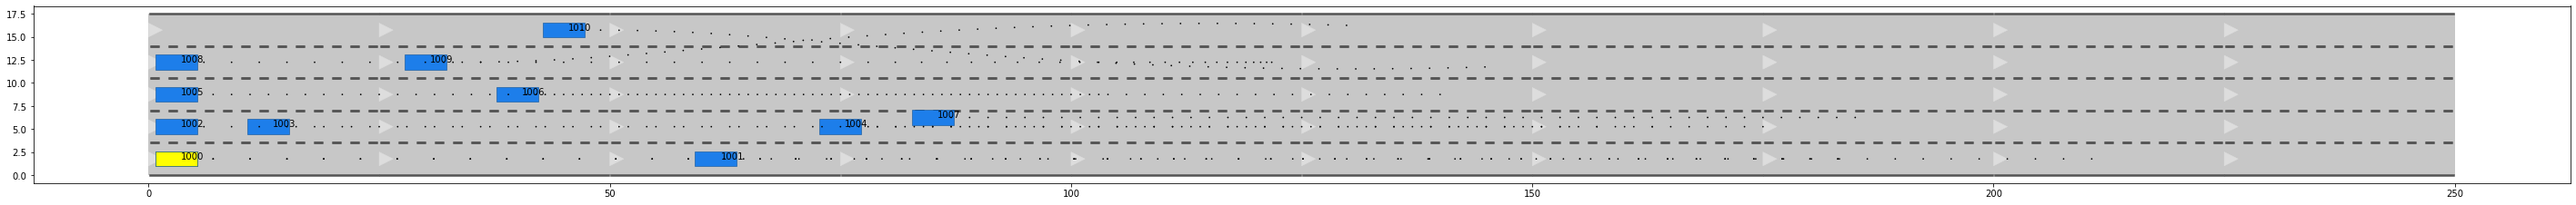

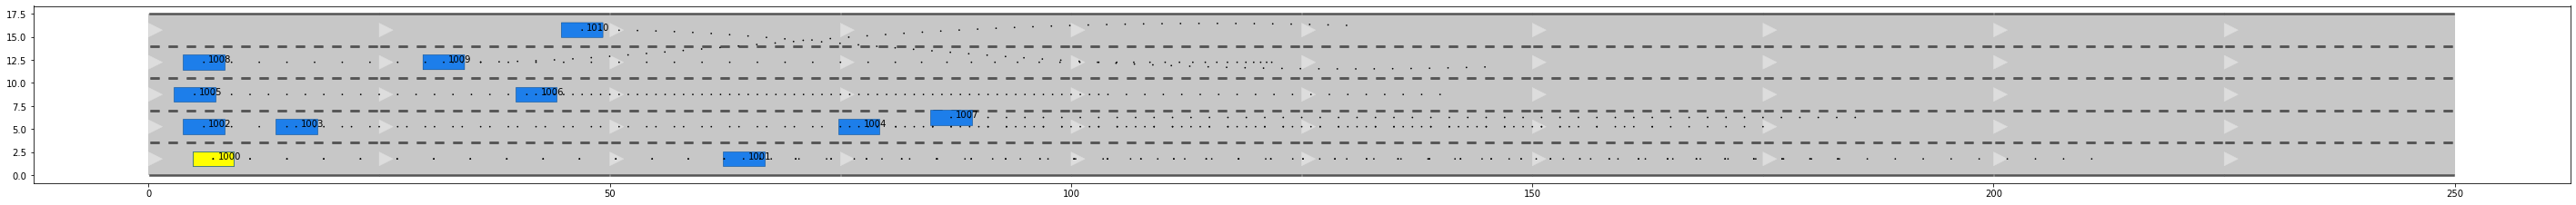

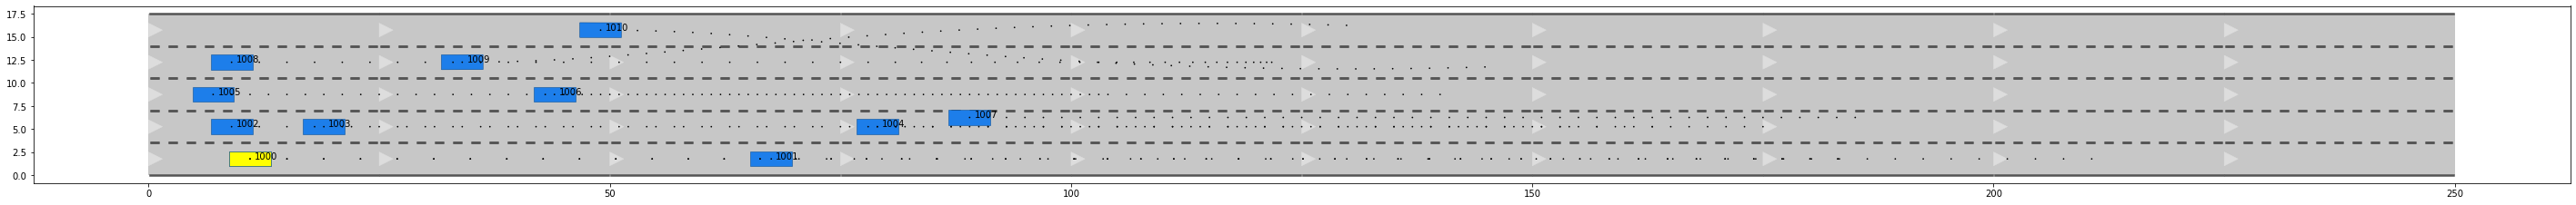

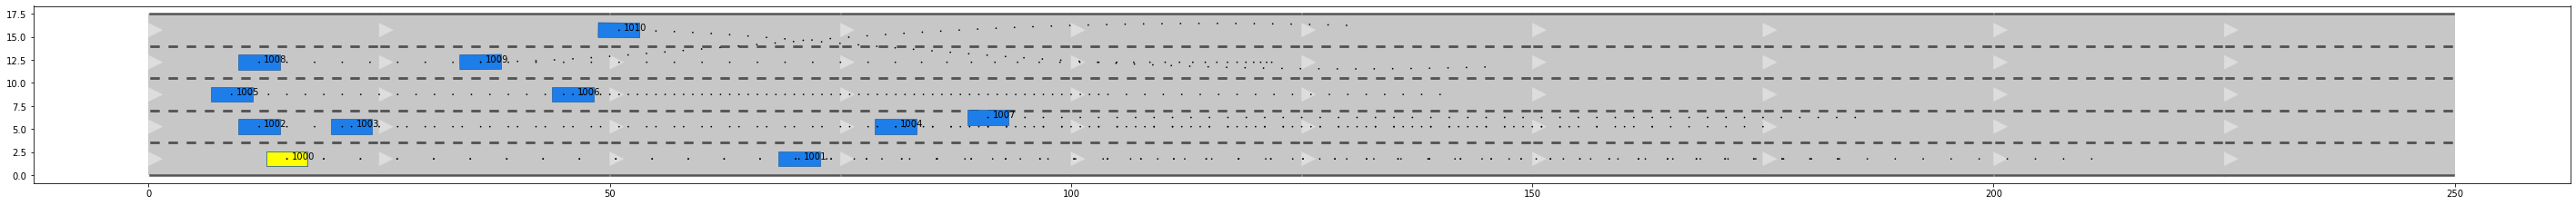

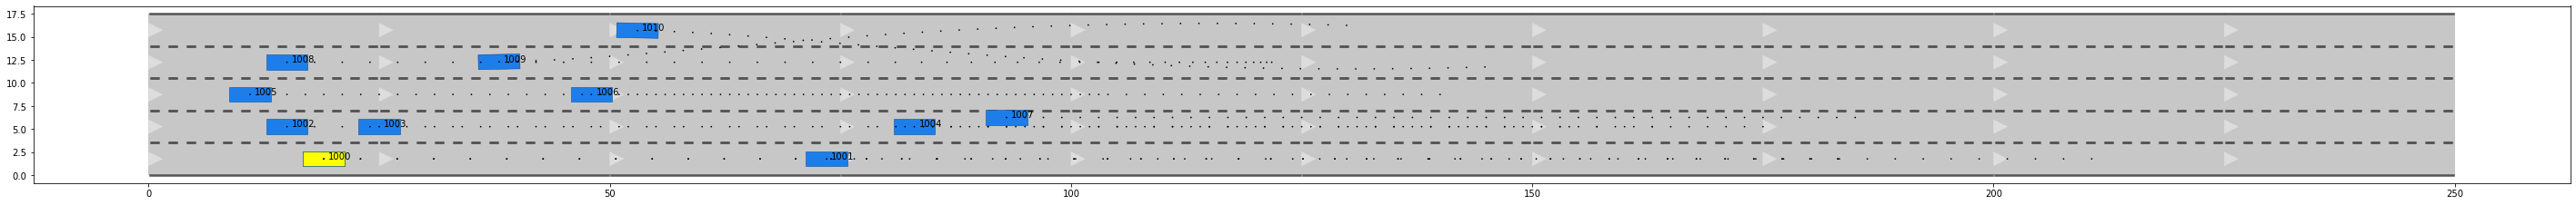

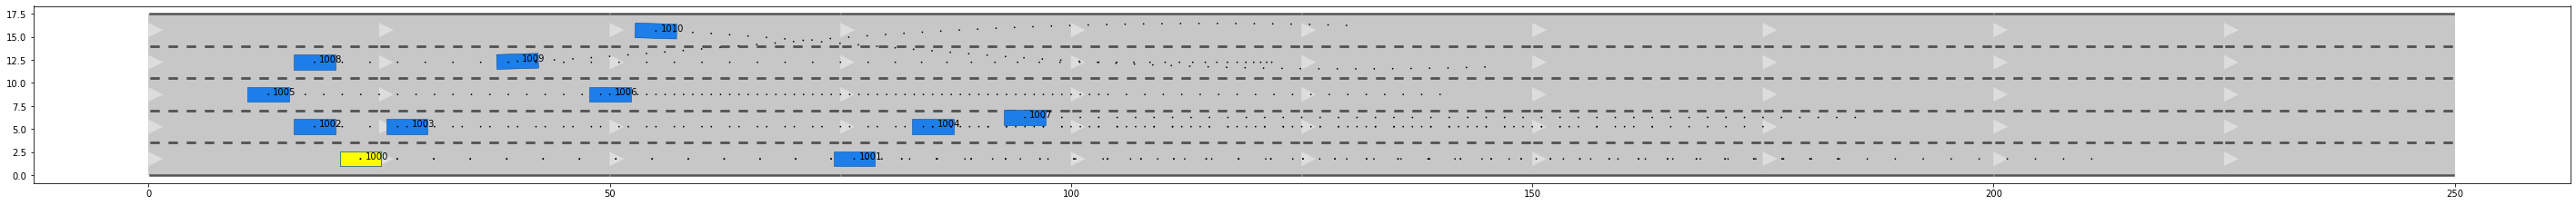

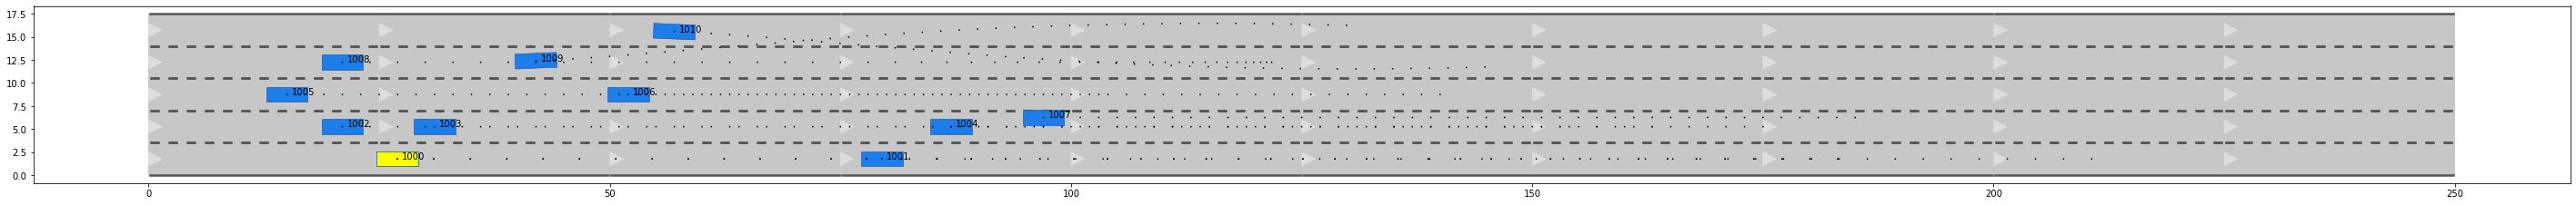

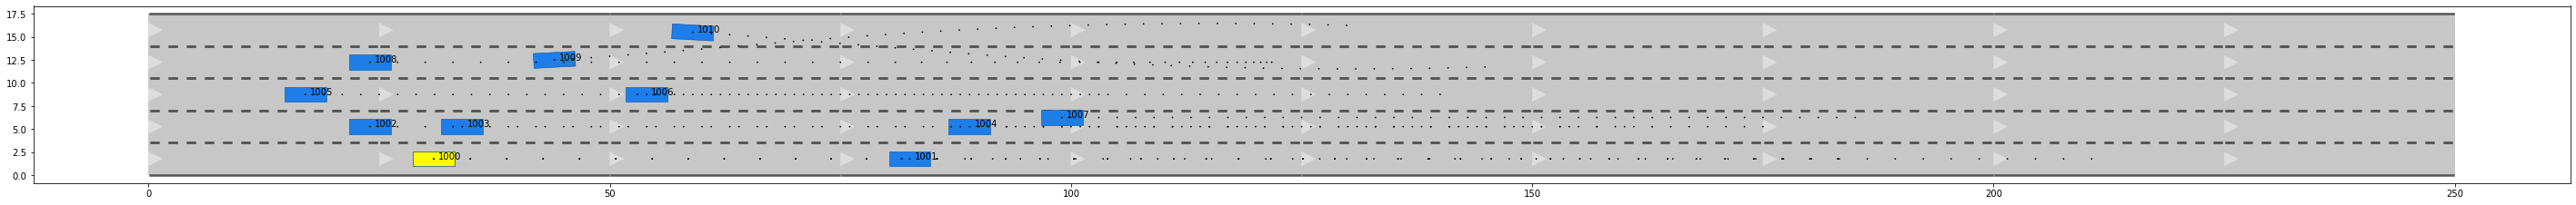

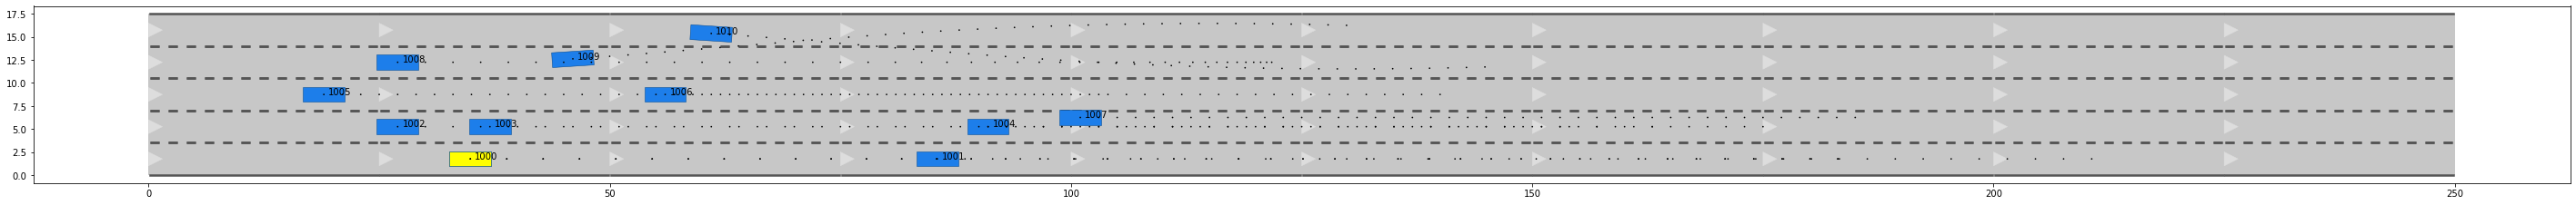

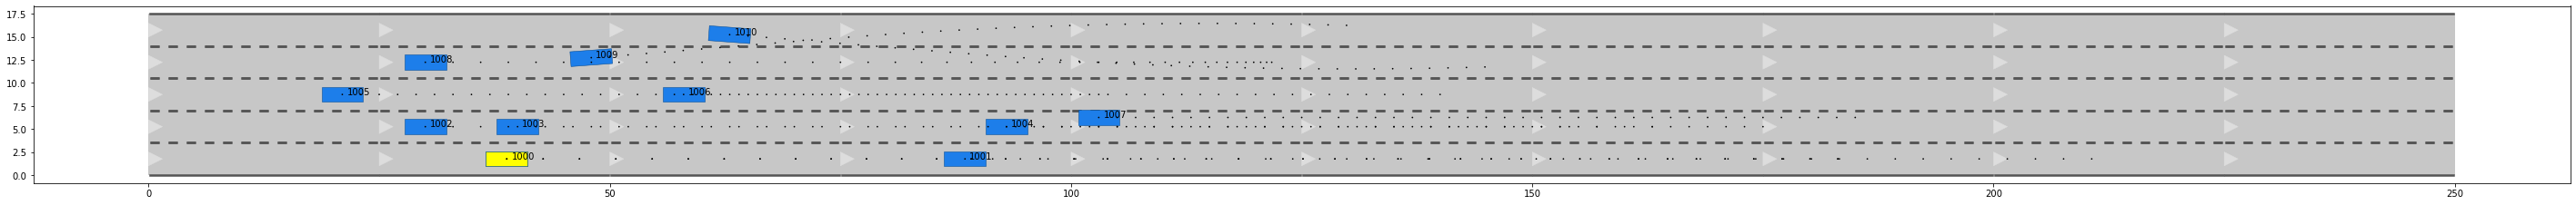

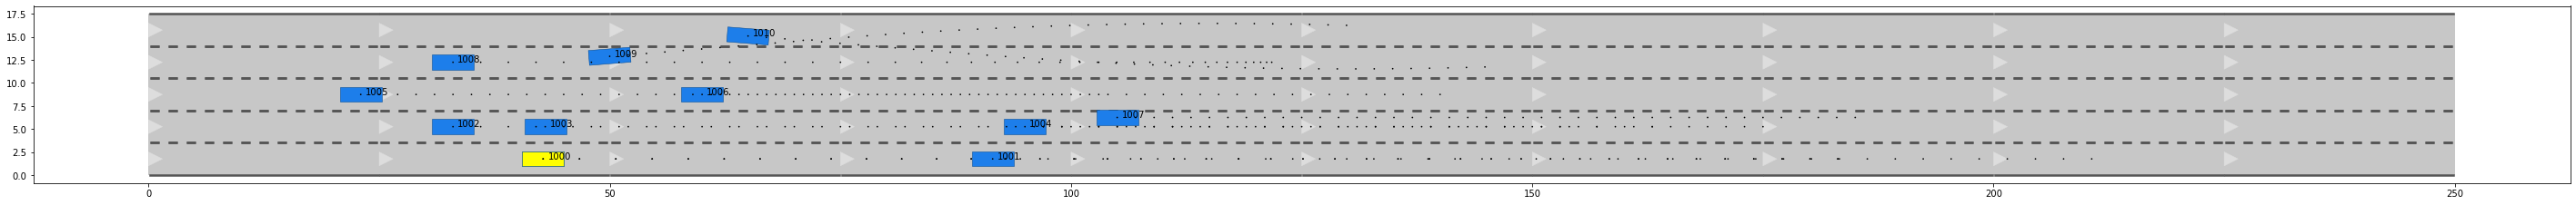

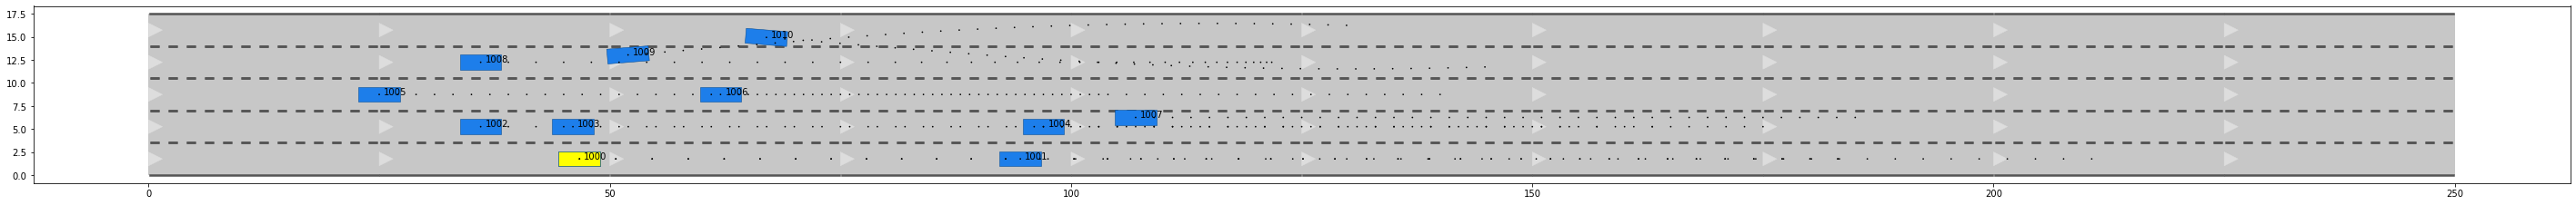

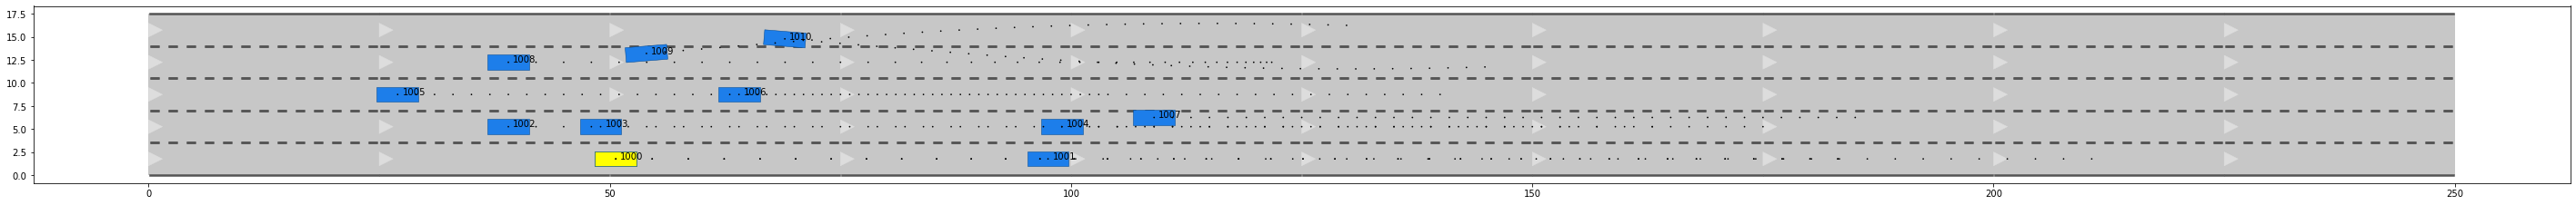

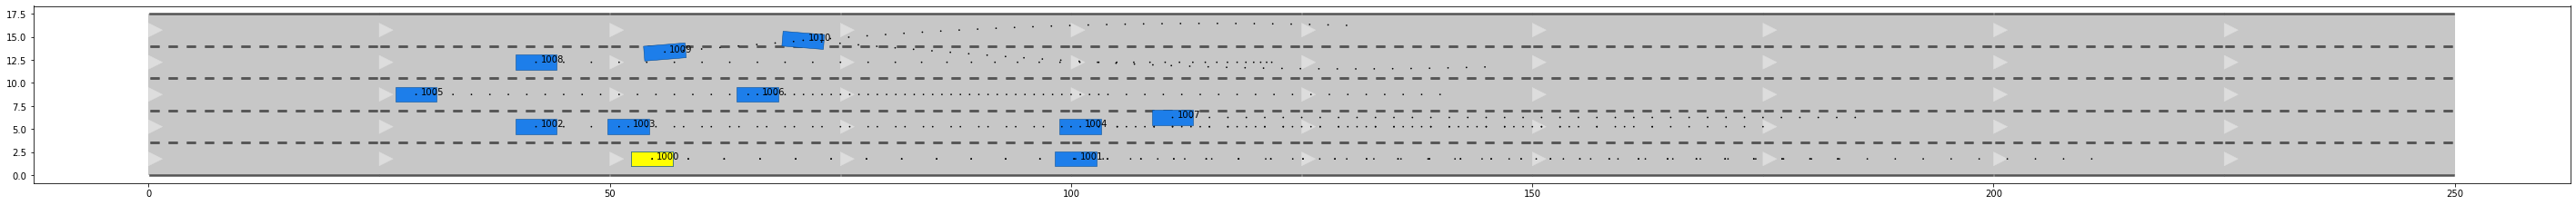

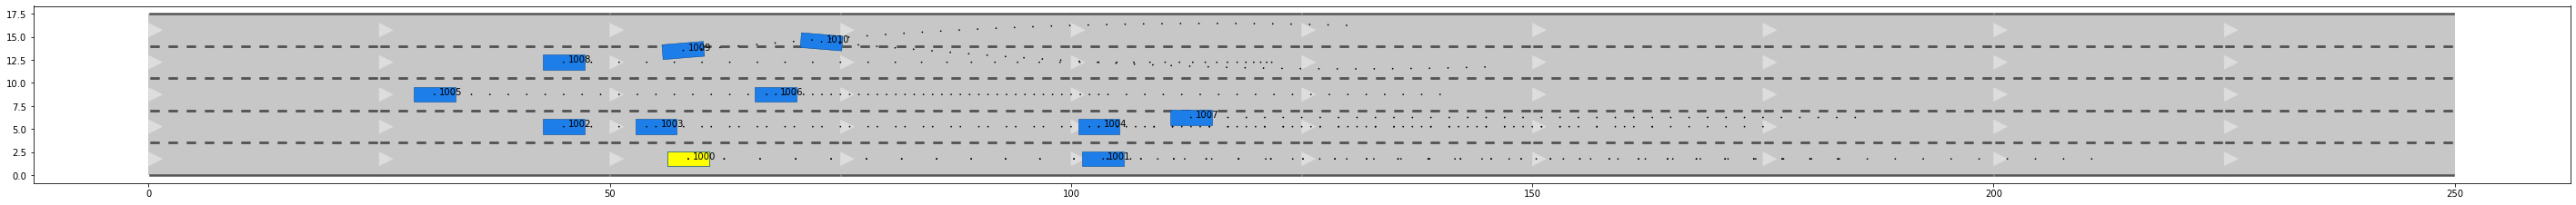

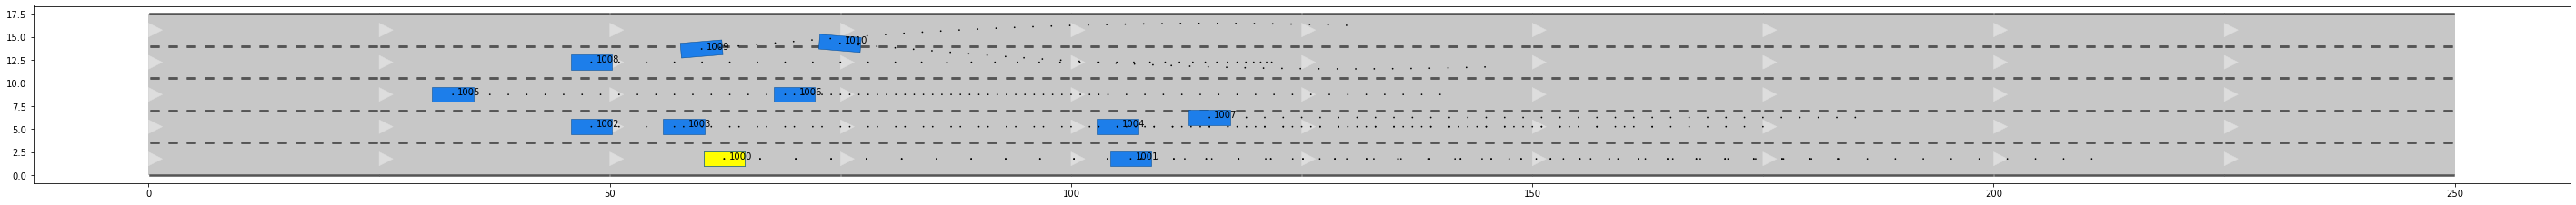

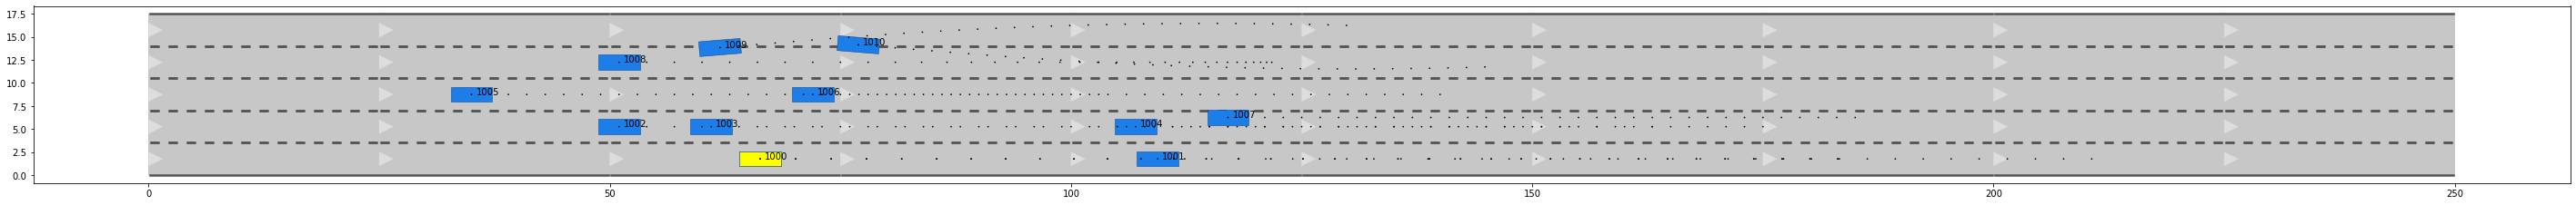

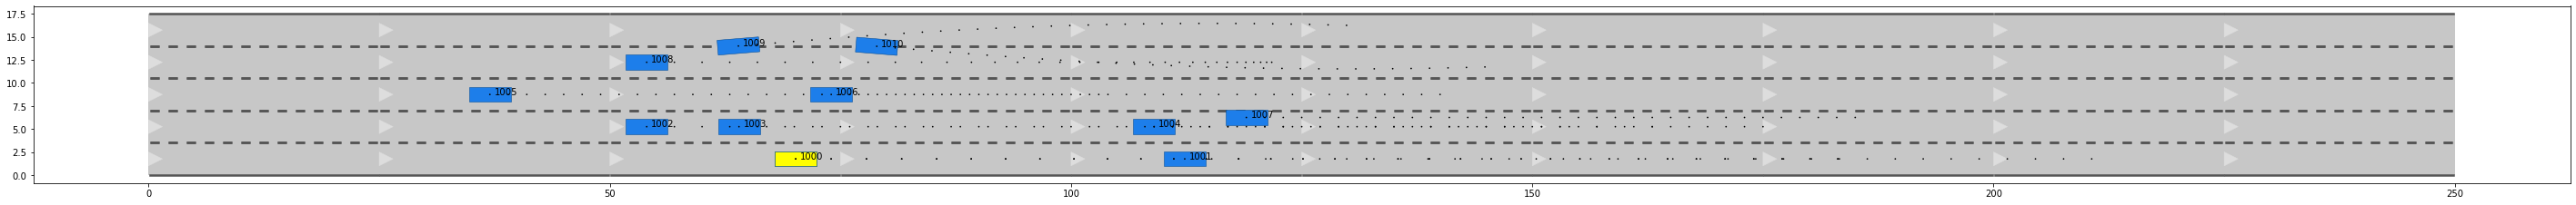

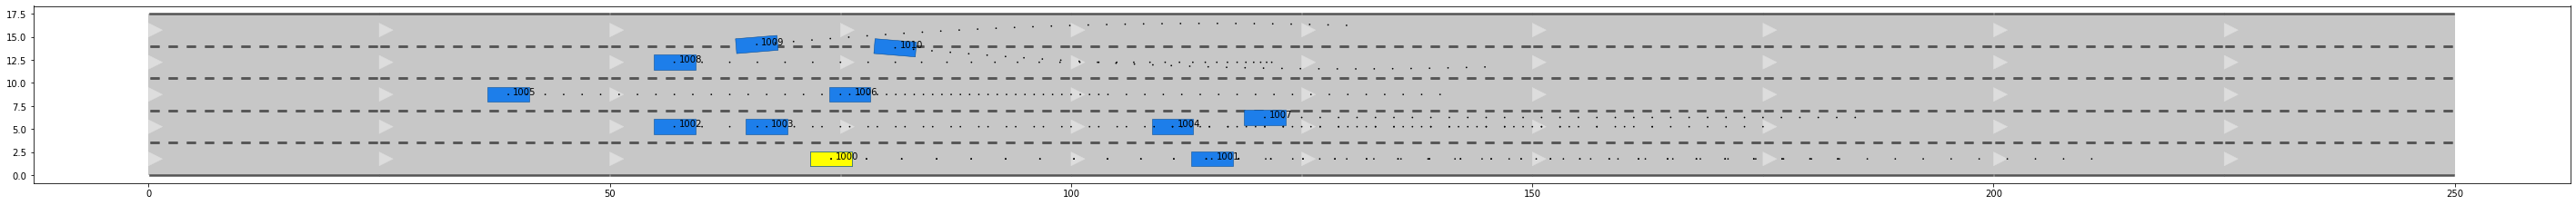

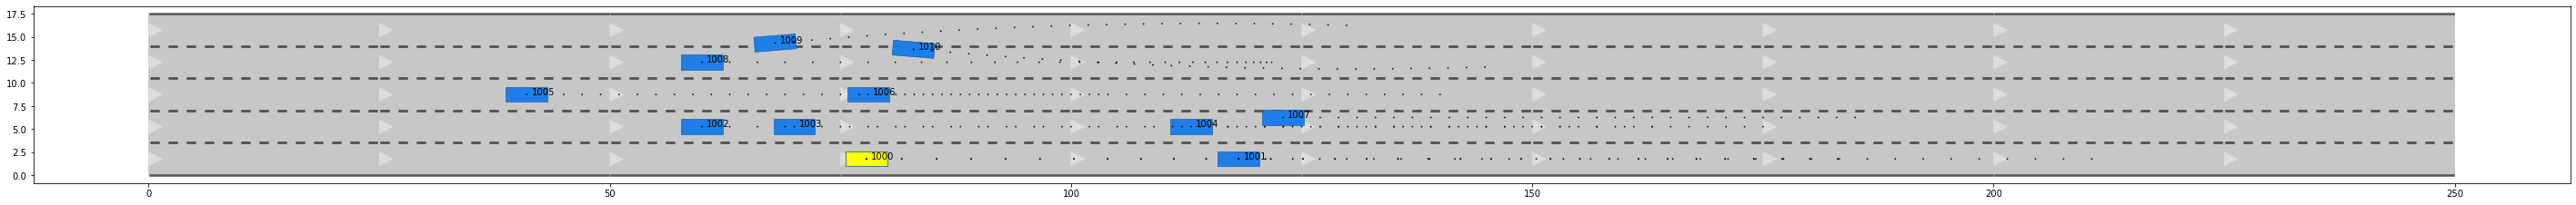

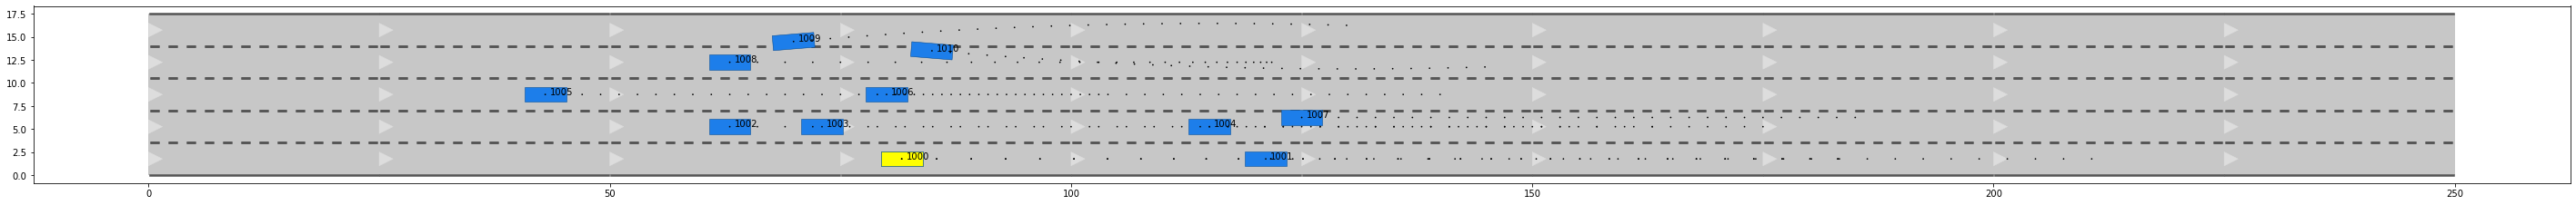

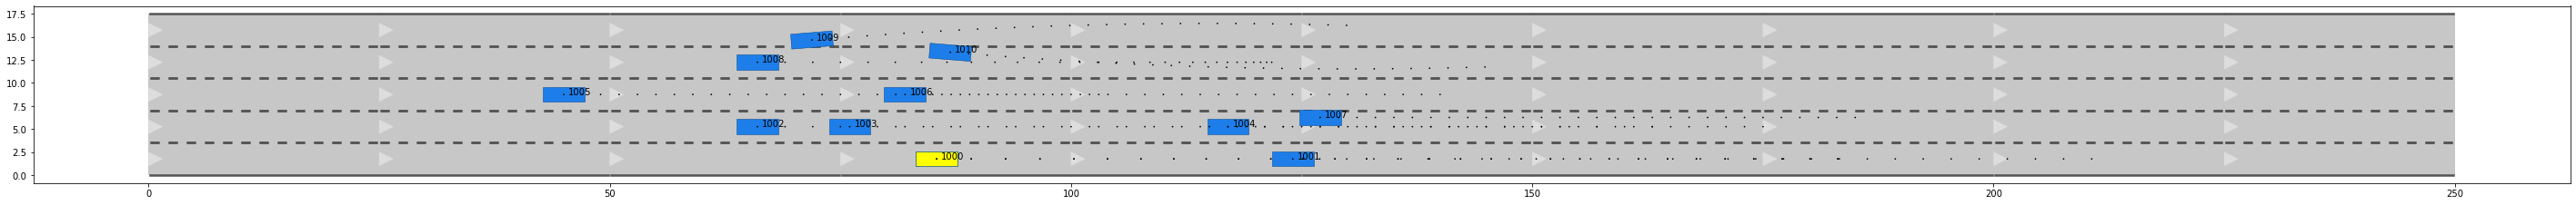

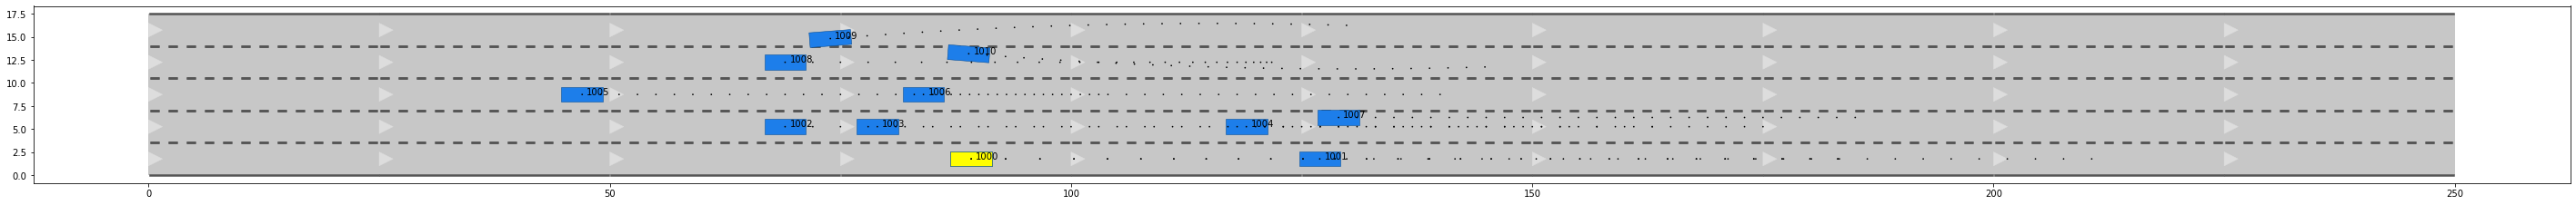

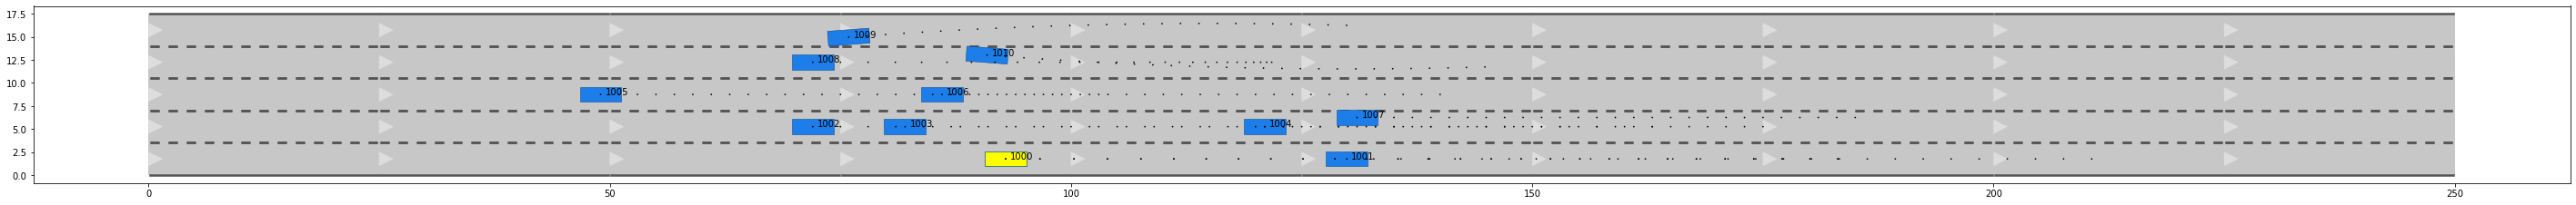

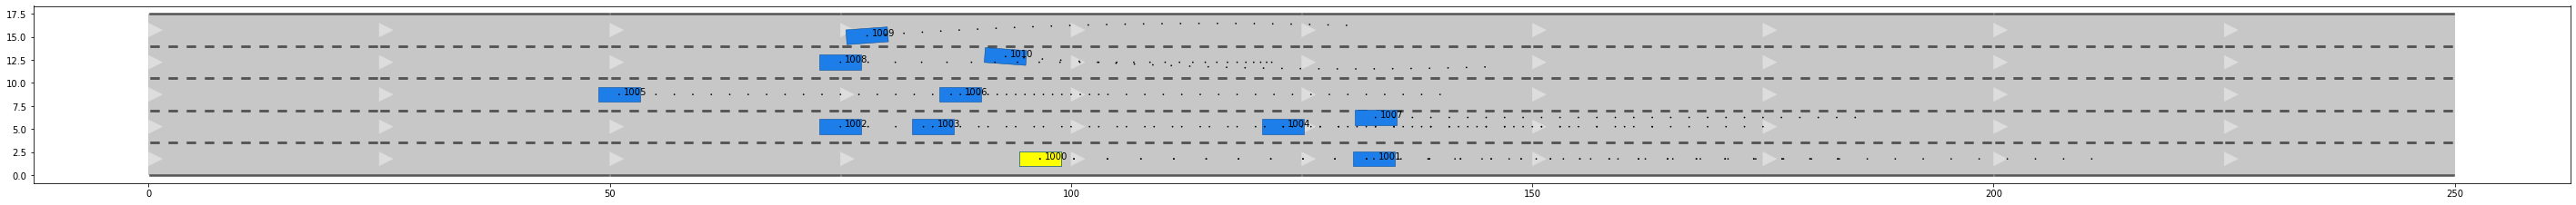

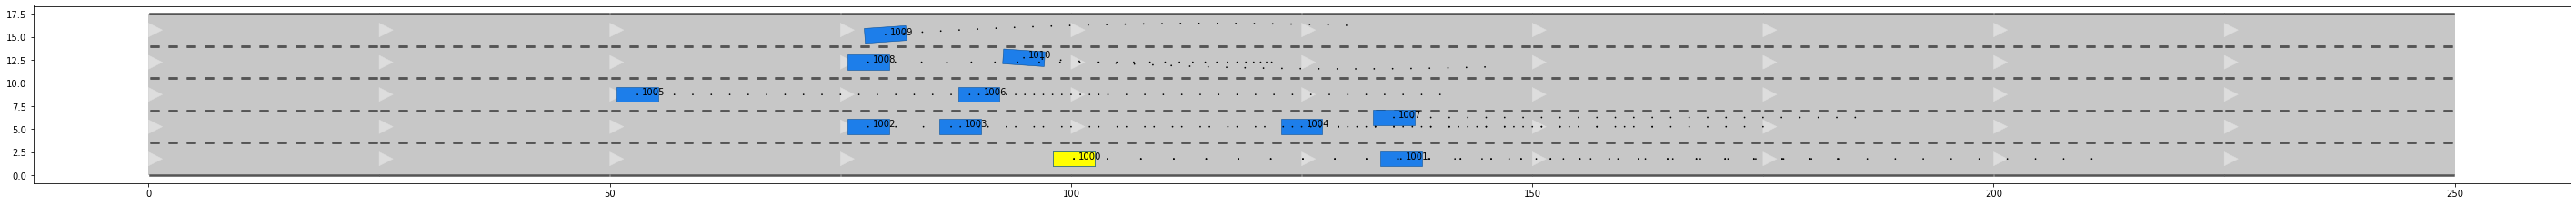

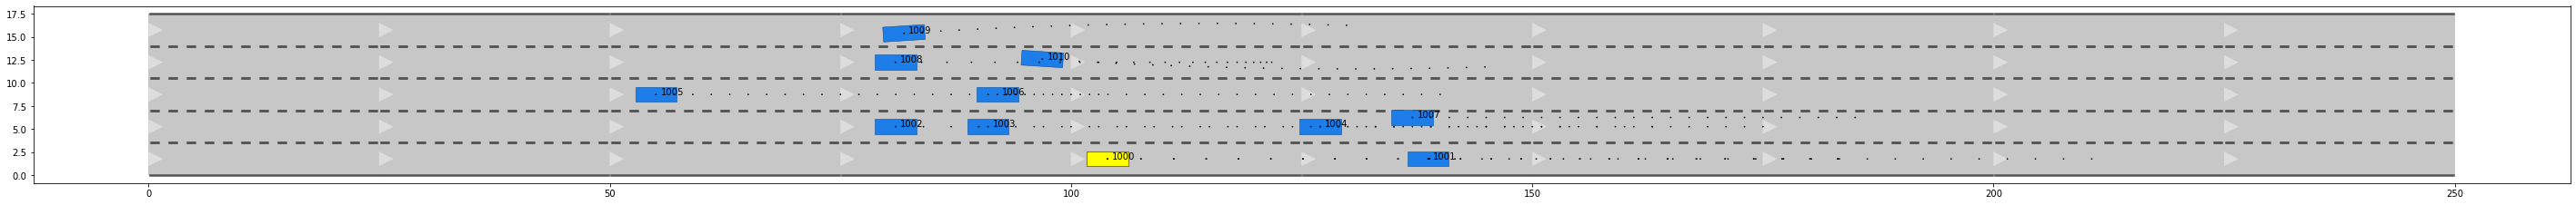

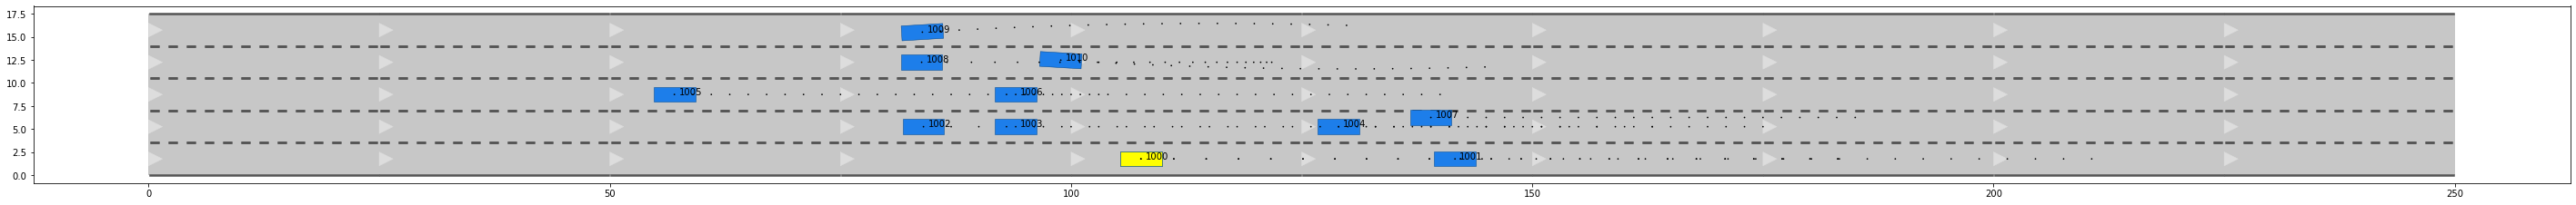

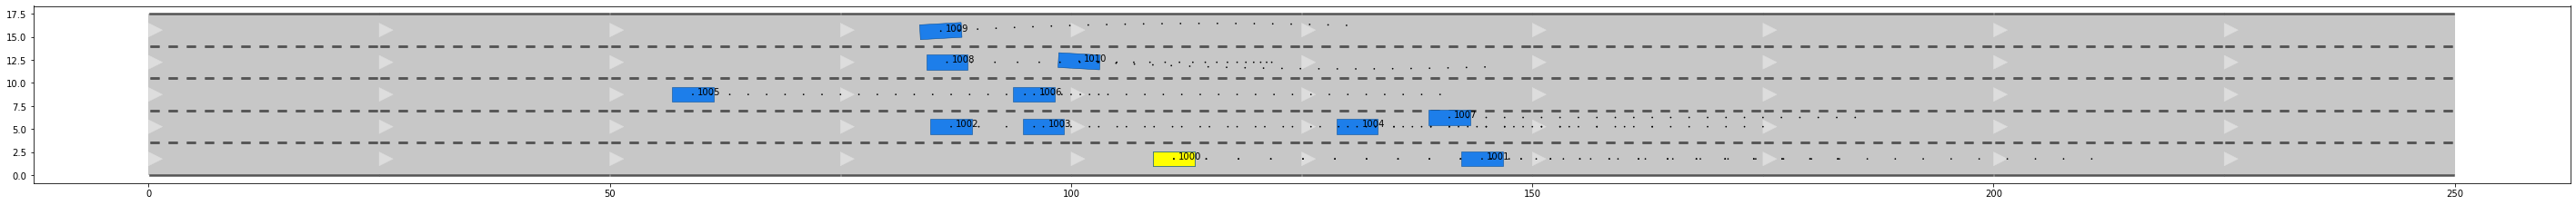

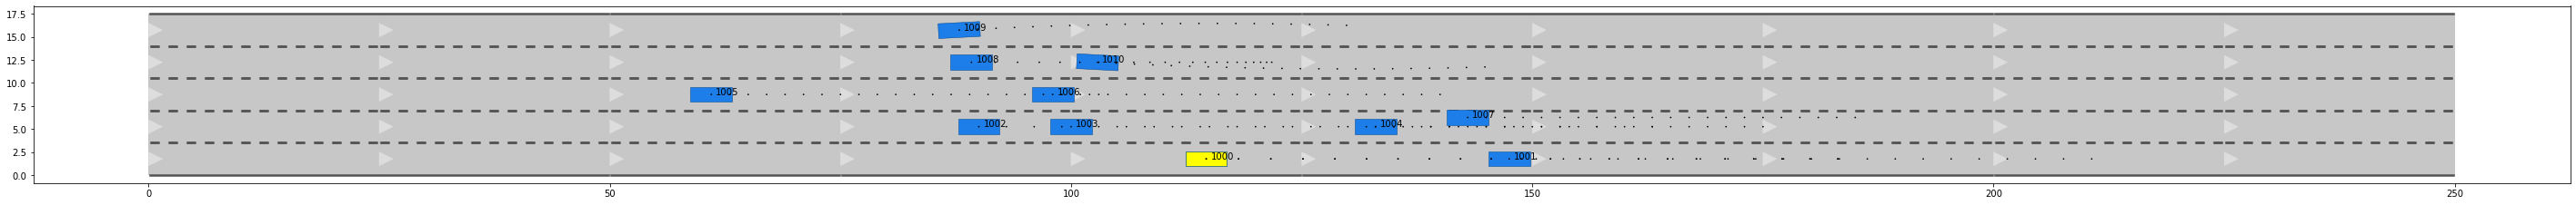

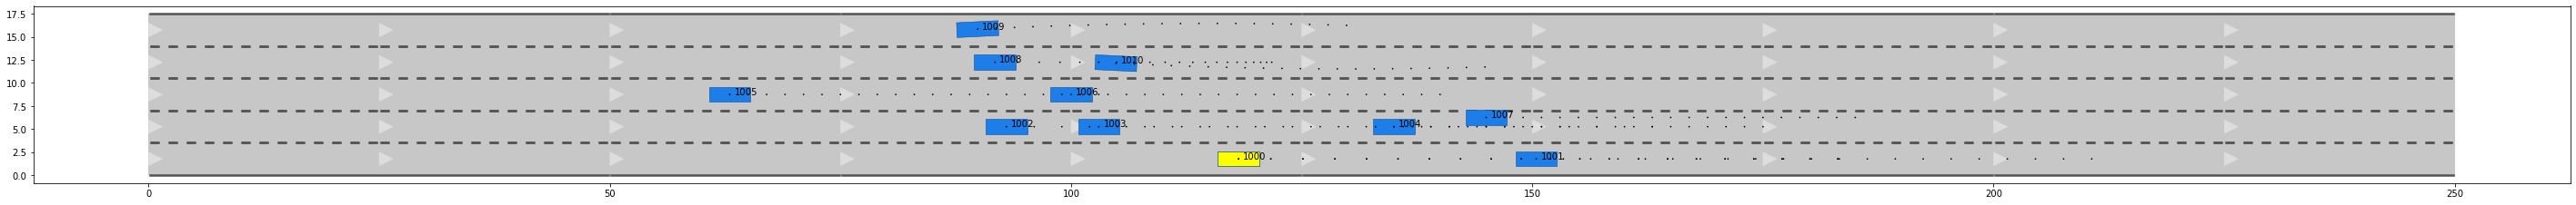

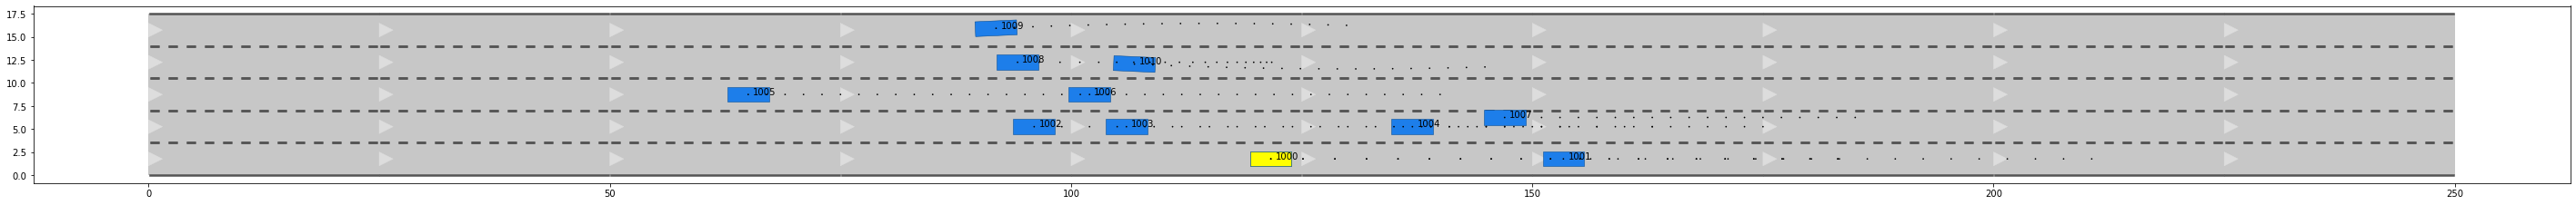

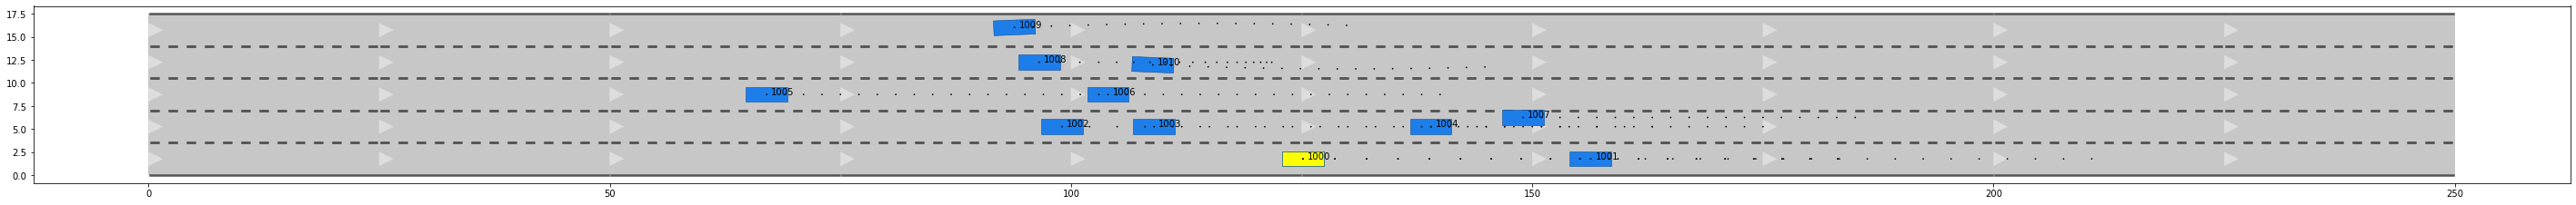

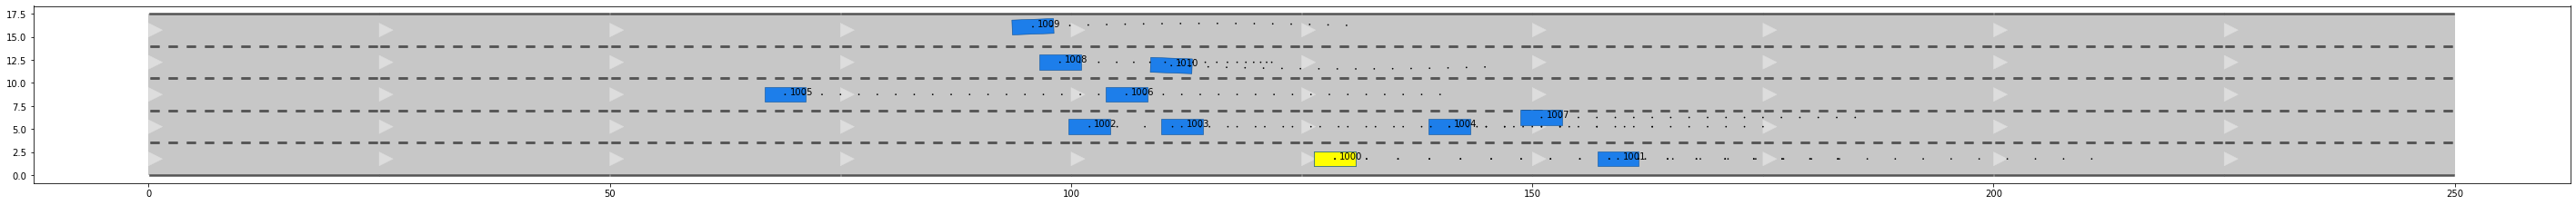

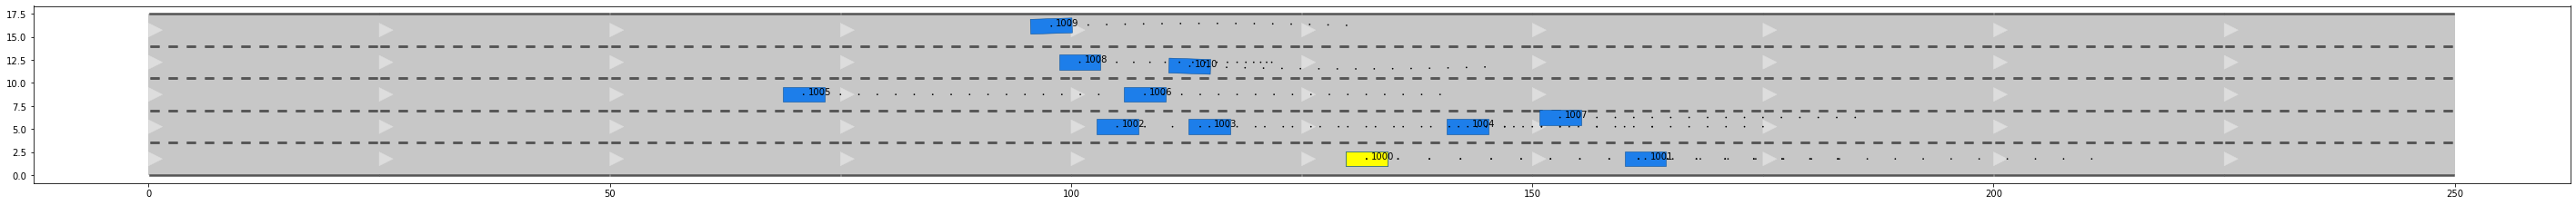

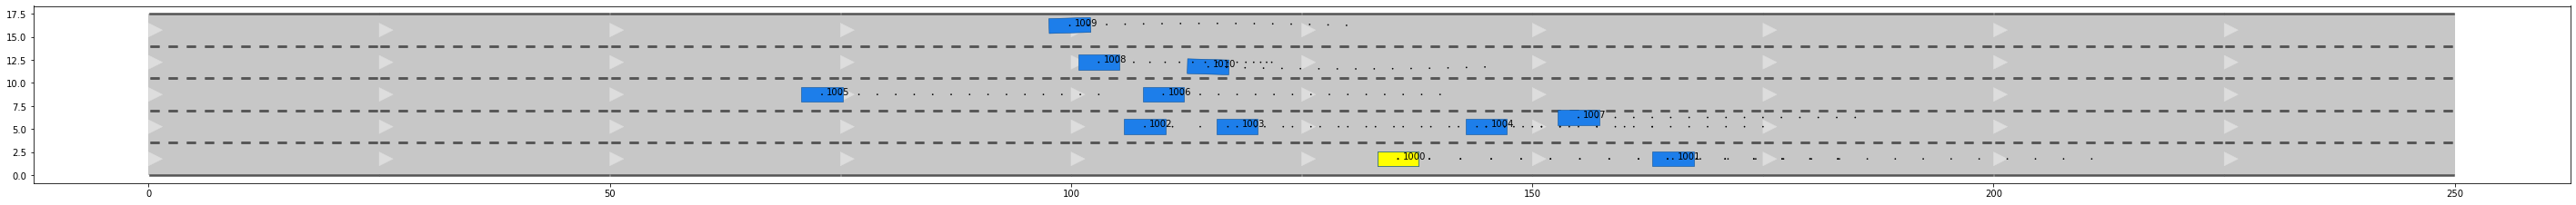

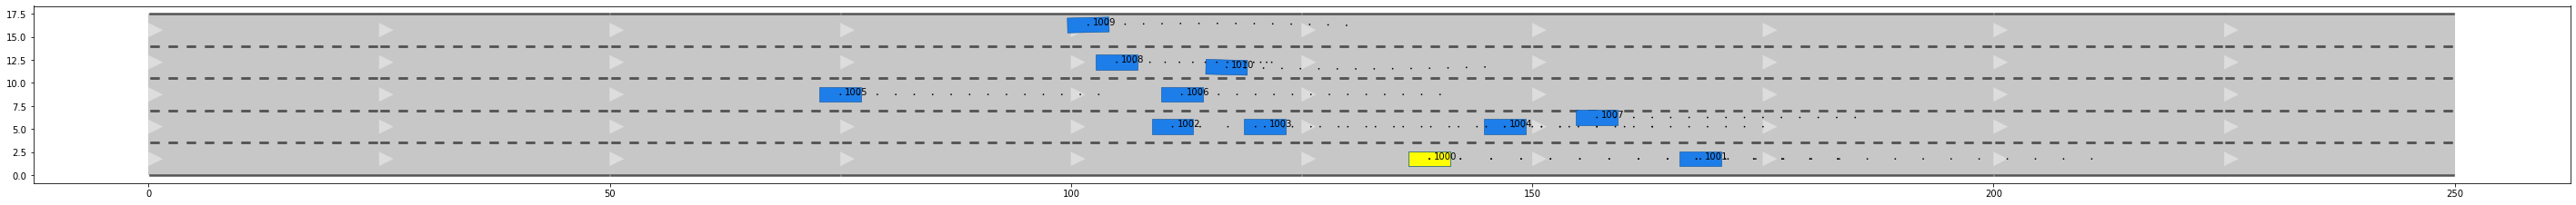

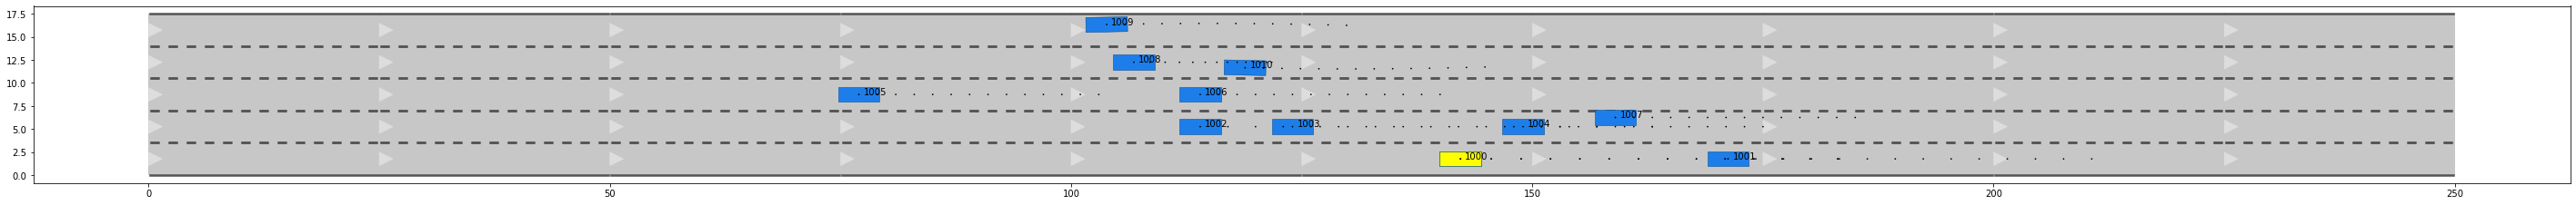

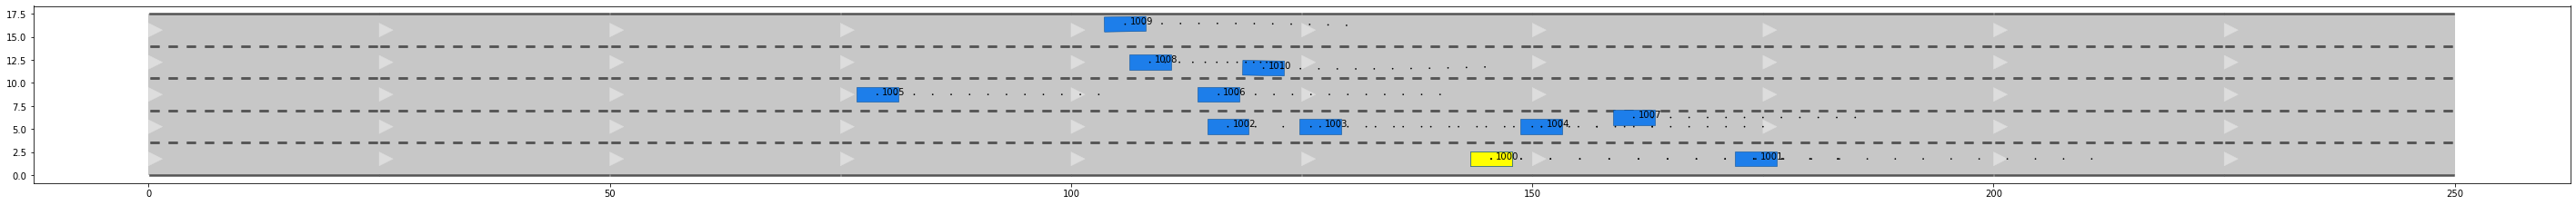

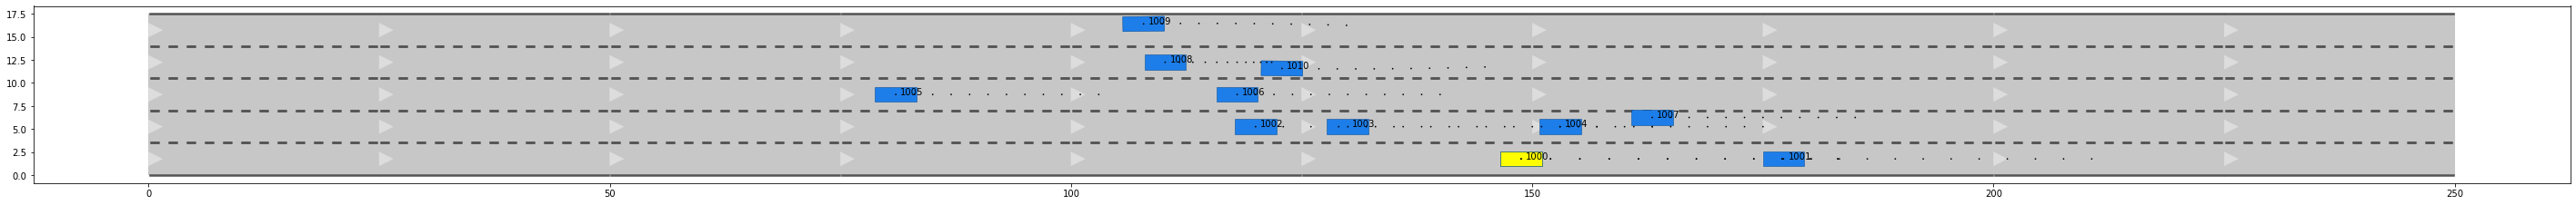

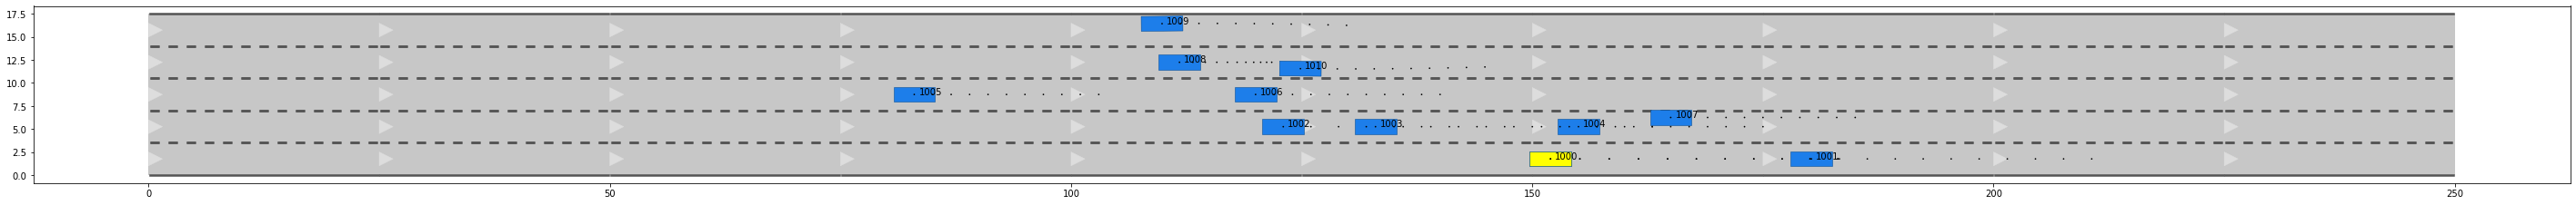

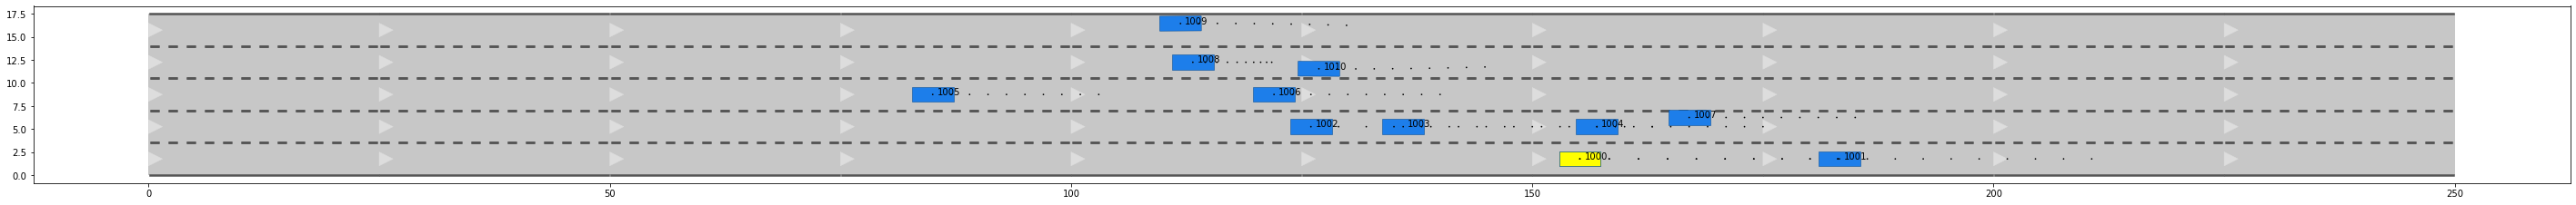

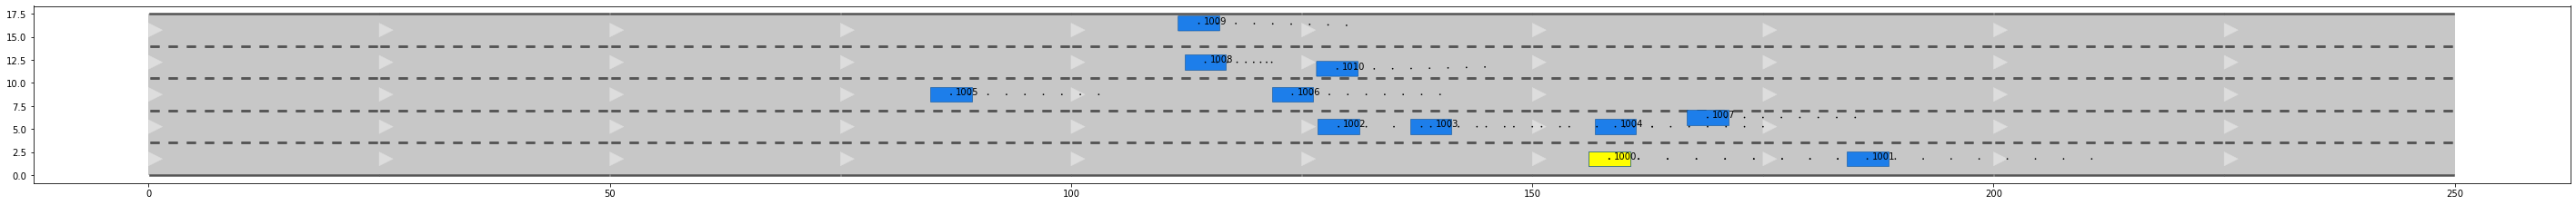

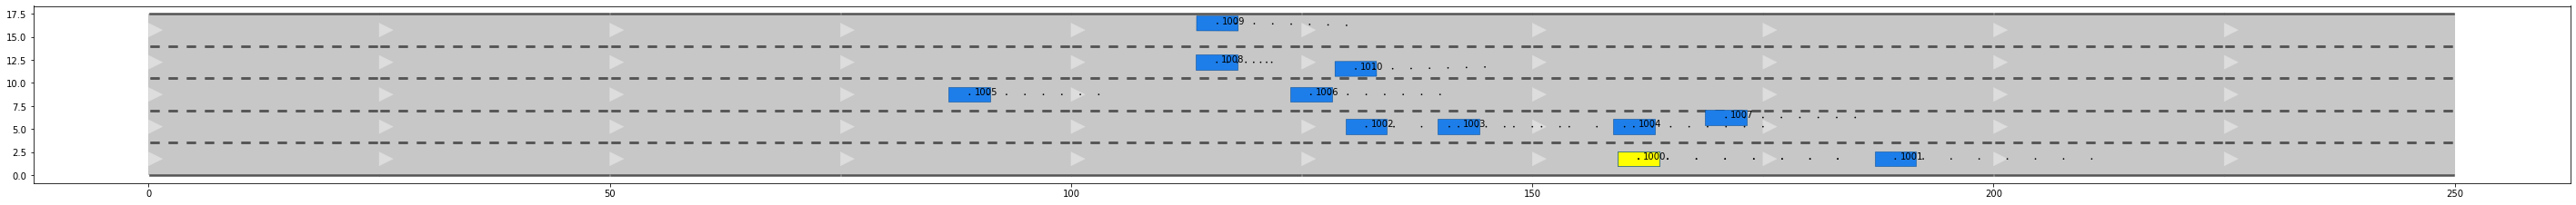

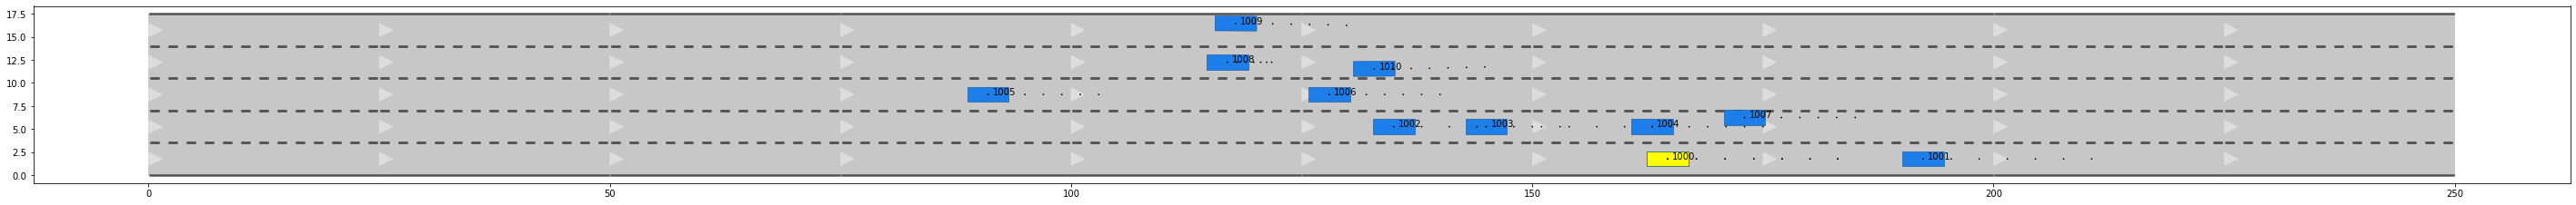

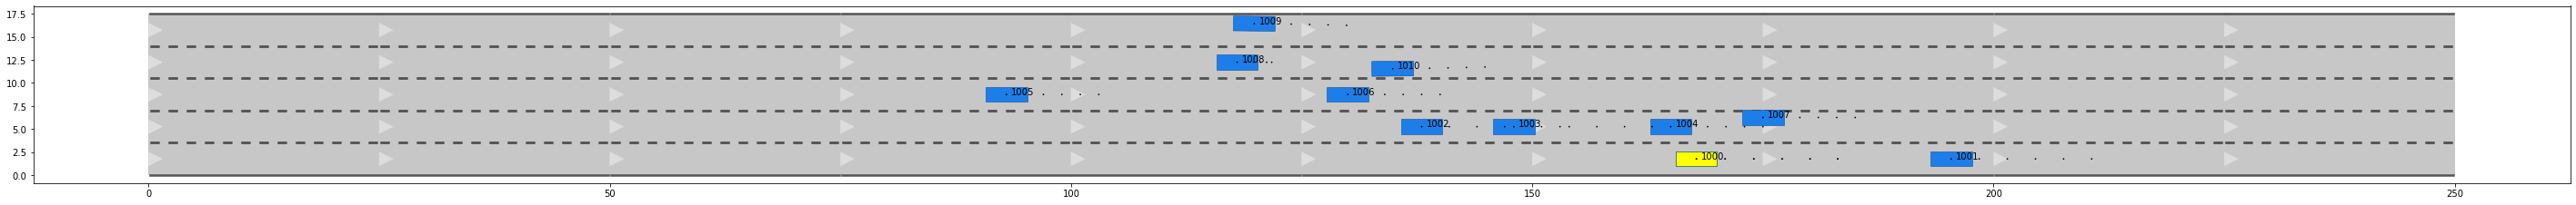

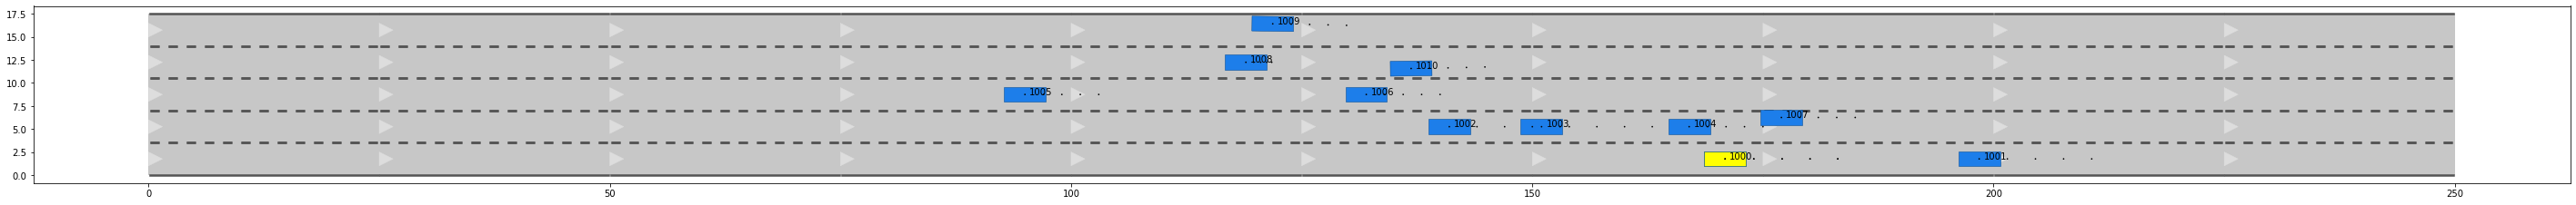

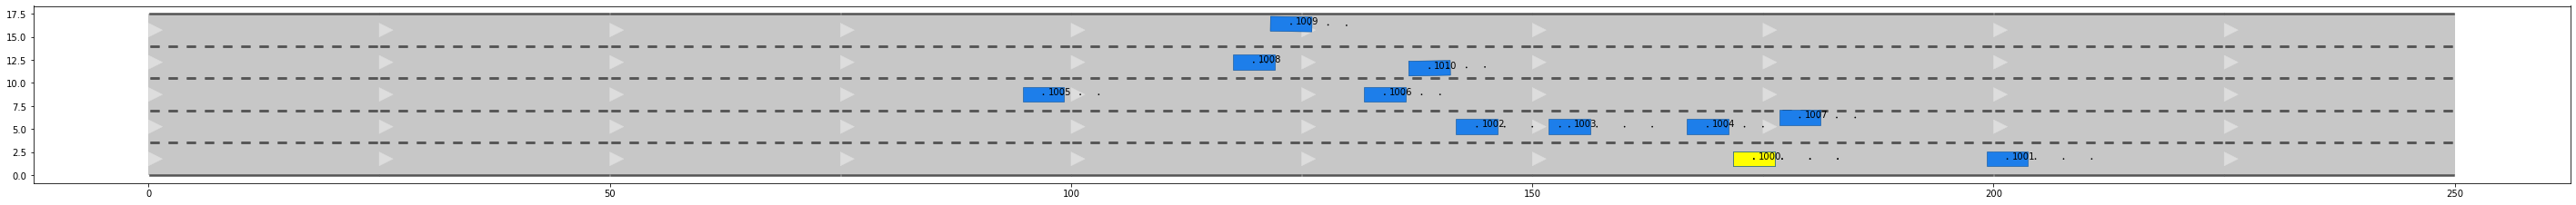

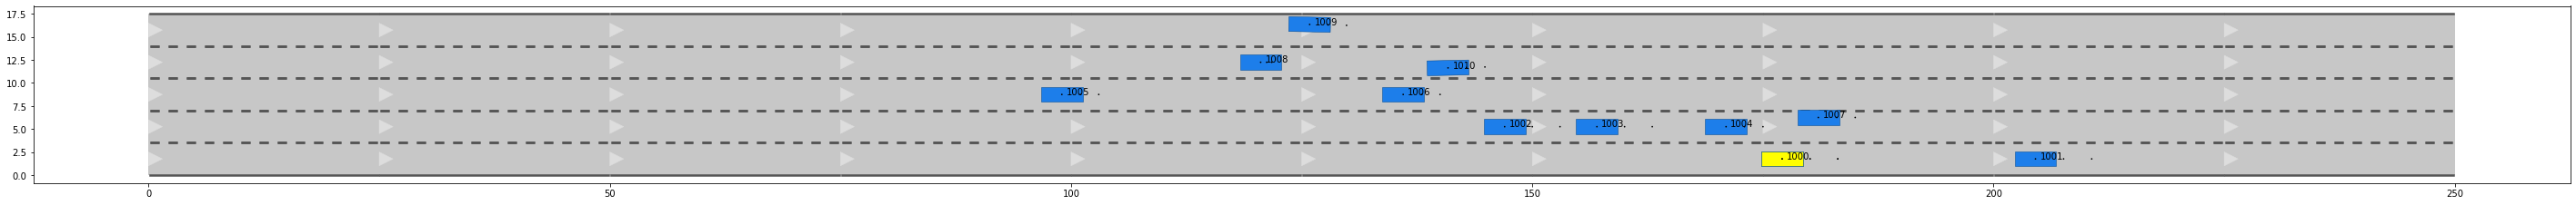

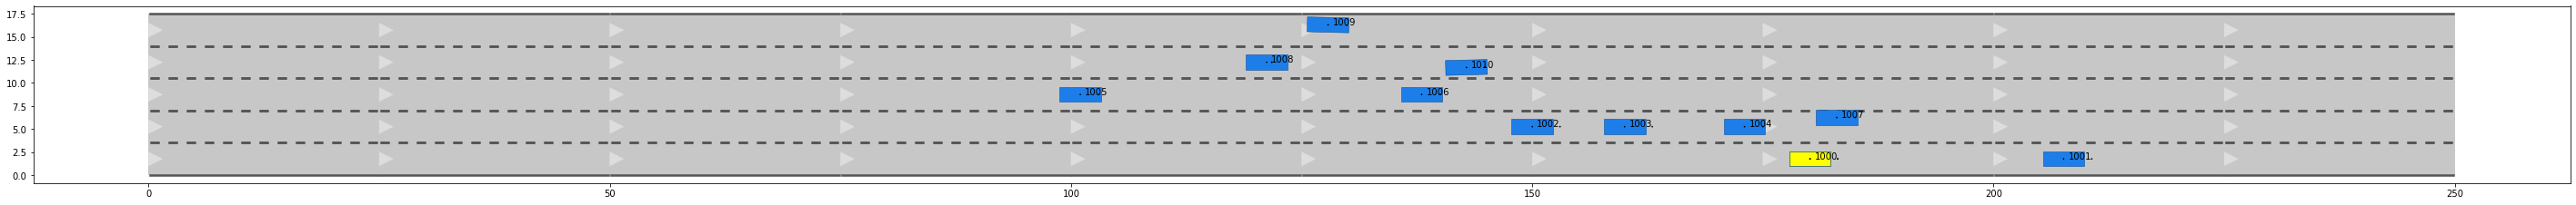

In [3]:
for i in range(0, 50):
    plt.figure(figsize=(50, 20))
    rnd = MPRenderer()
    scenario.draw(rnd, draw_params={'time_begin': i, 'dynamic_obstacle': {'show_label': True}})
    ego_vehicle.draw(rnd, draw_params={'time_begin': i, 'dynamic_obstacle': { 'vehicle_shape': {'occupancy': {'shape': {'rectangle': {'facecolor': 'yellow'}}}}}})
    rnd.render()
    plt.show()

## Create rule evaluator

In [4]:
world = World.create_from_scenario(scenario)
world_ego_vehicle = world.vehicle_by_id(ego_vehicle.obstacle_id)
rule_set = ["R_G1", "R_G2", "R_G3"]
rule_evaluator_list = list()
for rule in rule_set:
    rule_evaluator_list.append(RuleEvaluator.create_from_config(world, world_ego_vehicle, rule=rule))

## Evaluate rule for each time step & visualize predicates

/home/yuanfei/commonroad/commonroad-stl-monitor/crmonitor/evaluation/visualization.py:37: UserWarning: Attempting to set identical left == right == 0.0 results in singular transformations; automatically expanding.
  ax.set_xlim([np_rule_robustness_course[0, 0], np_rule_robustness_course[-1, 0]])


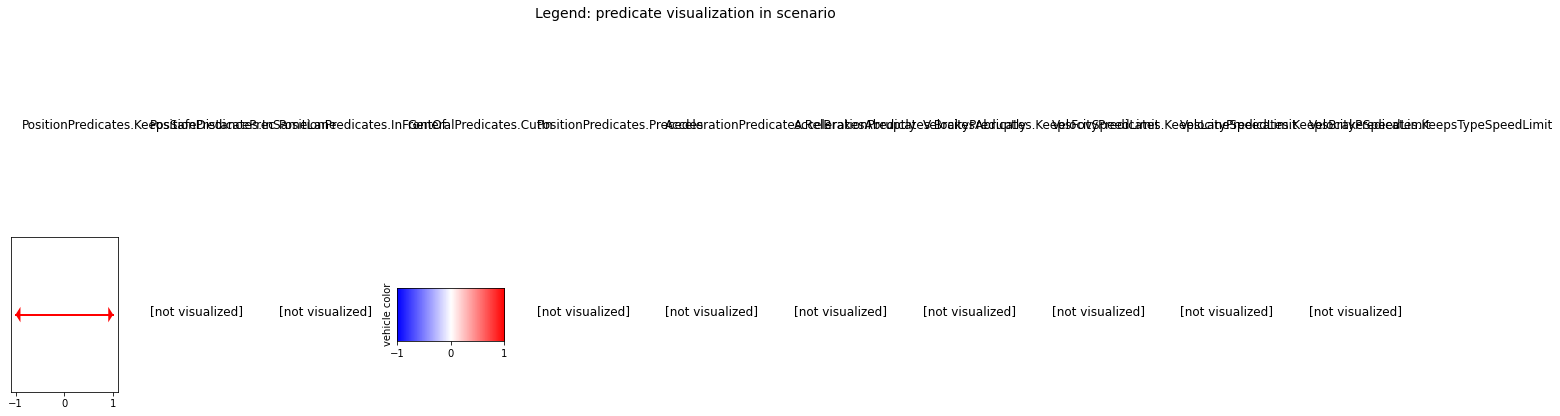

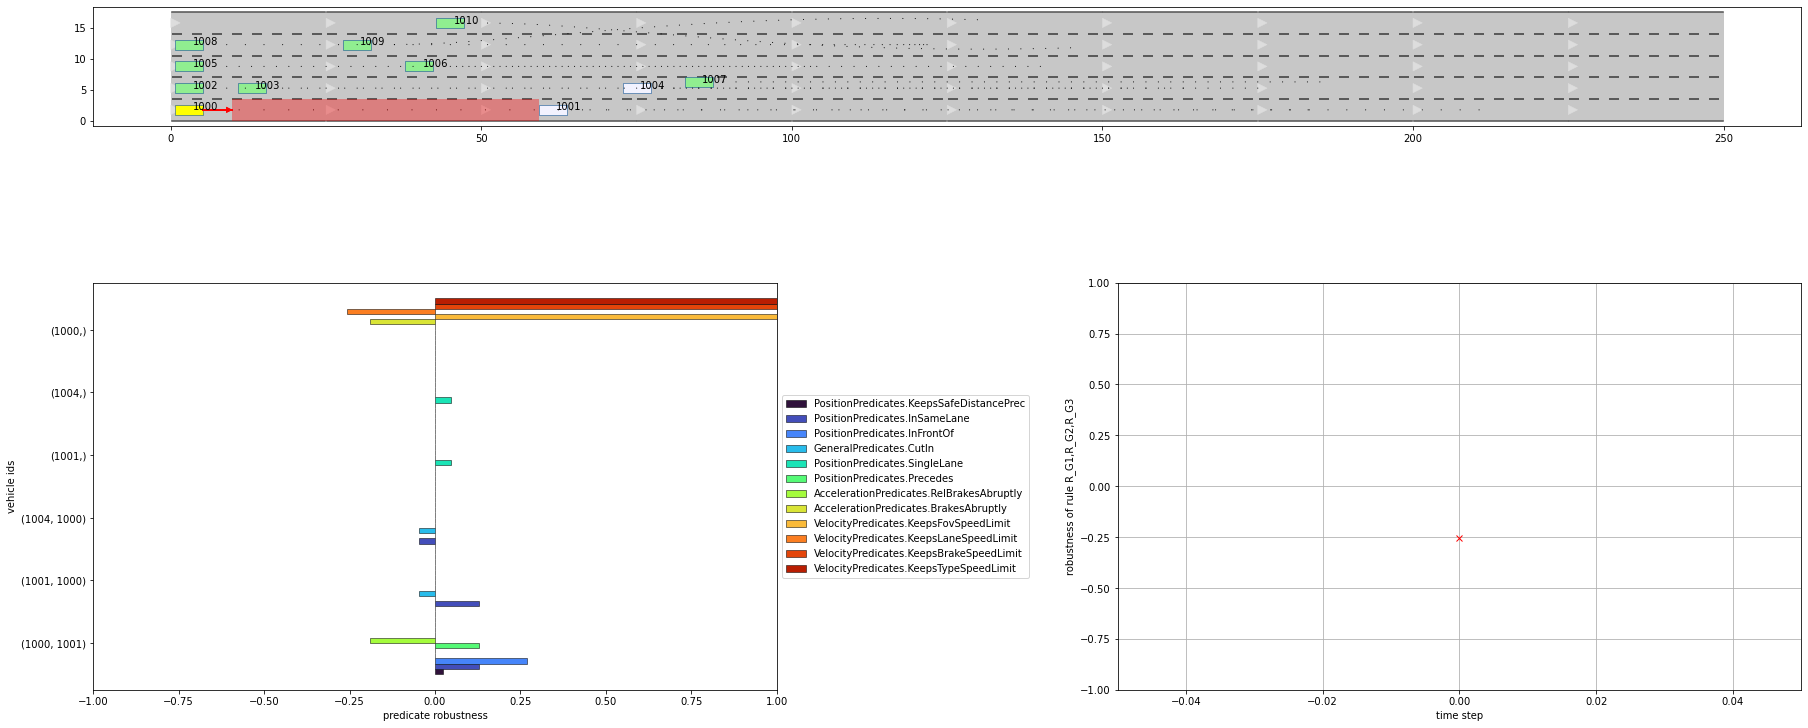

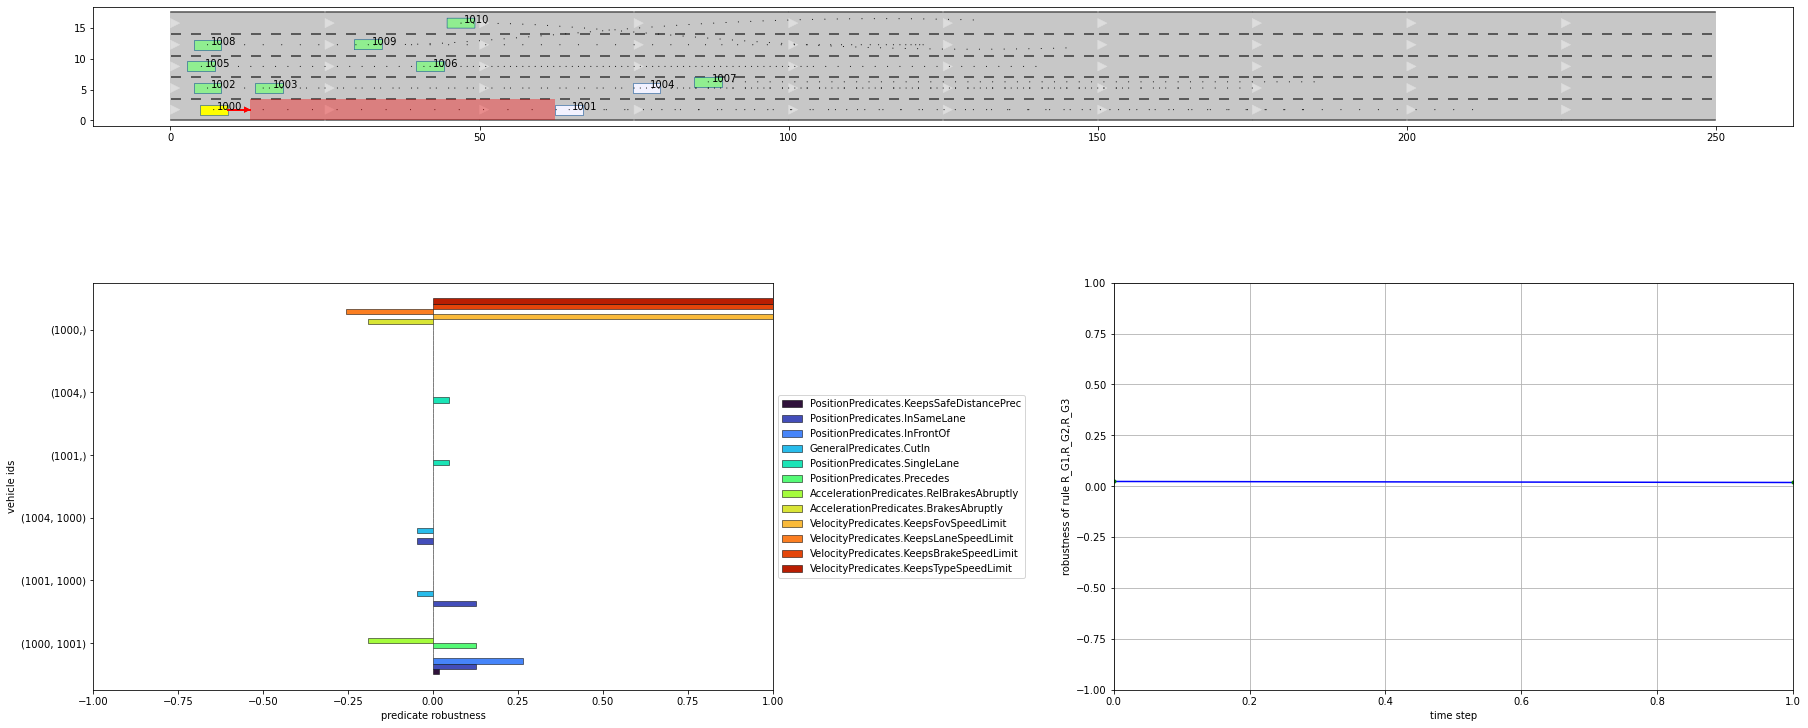

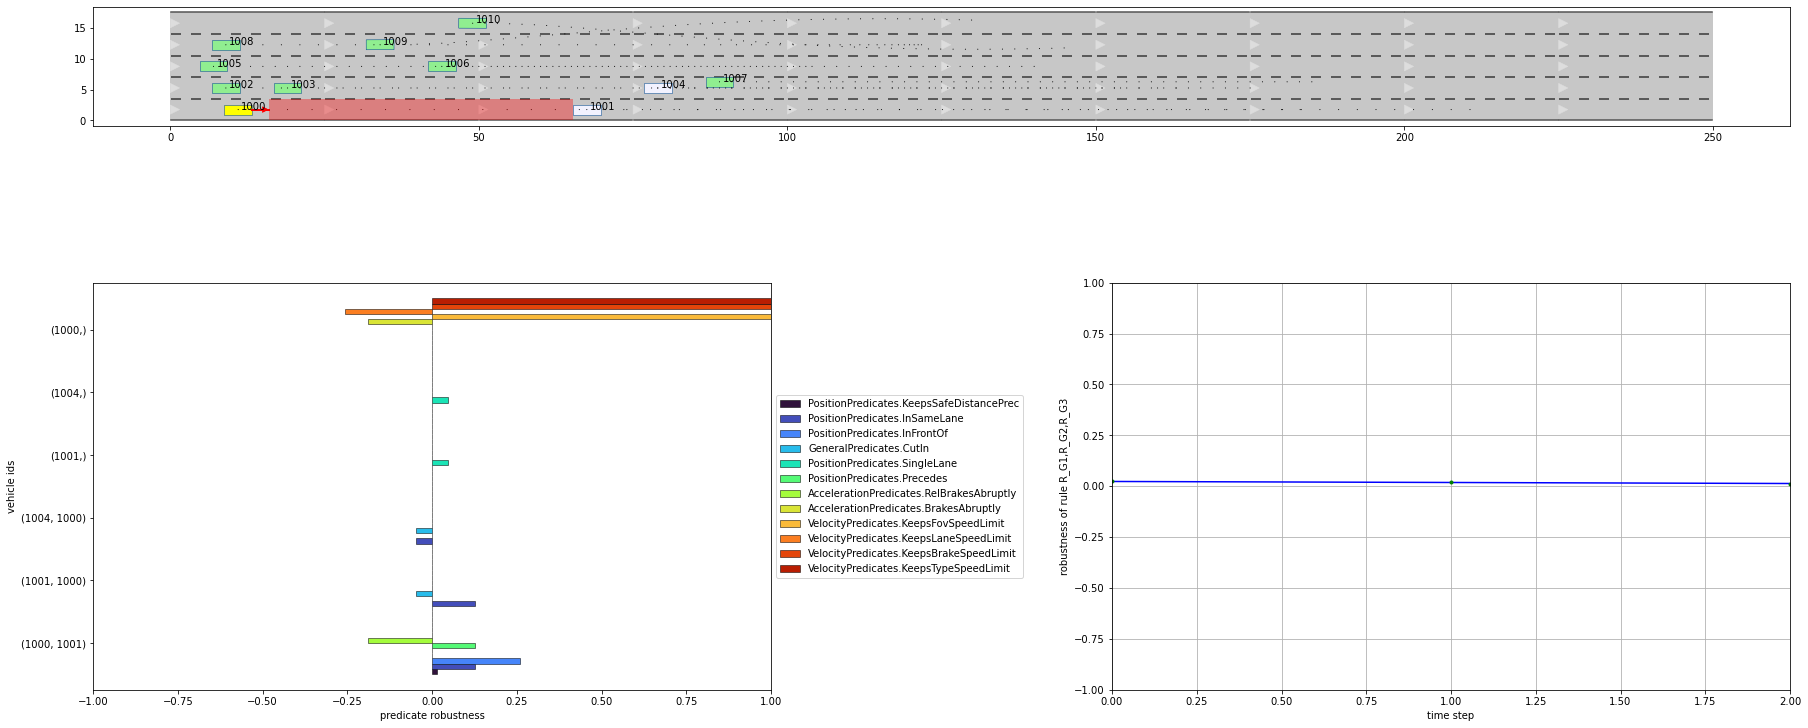

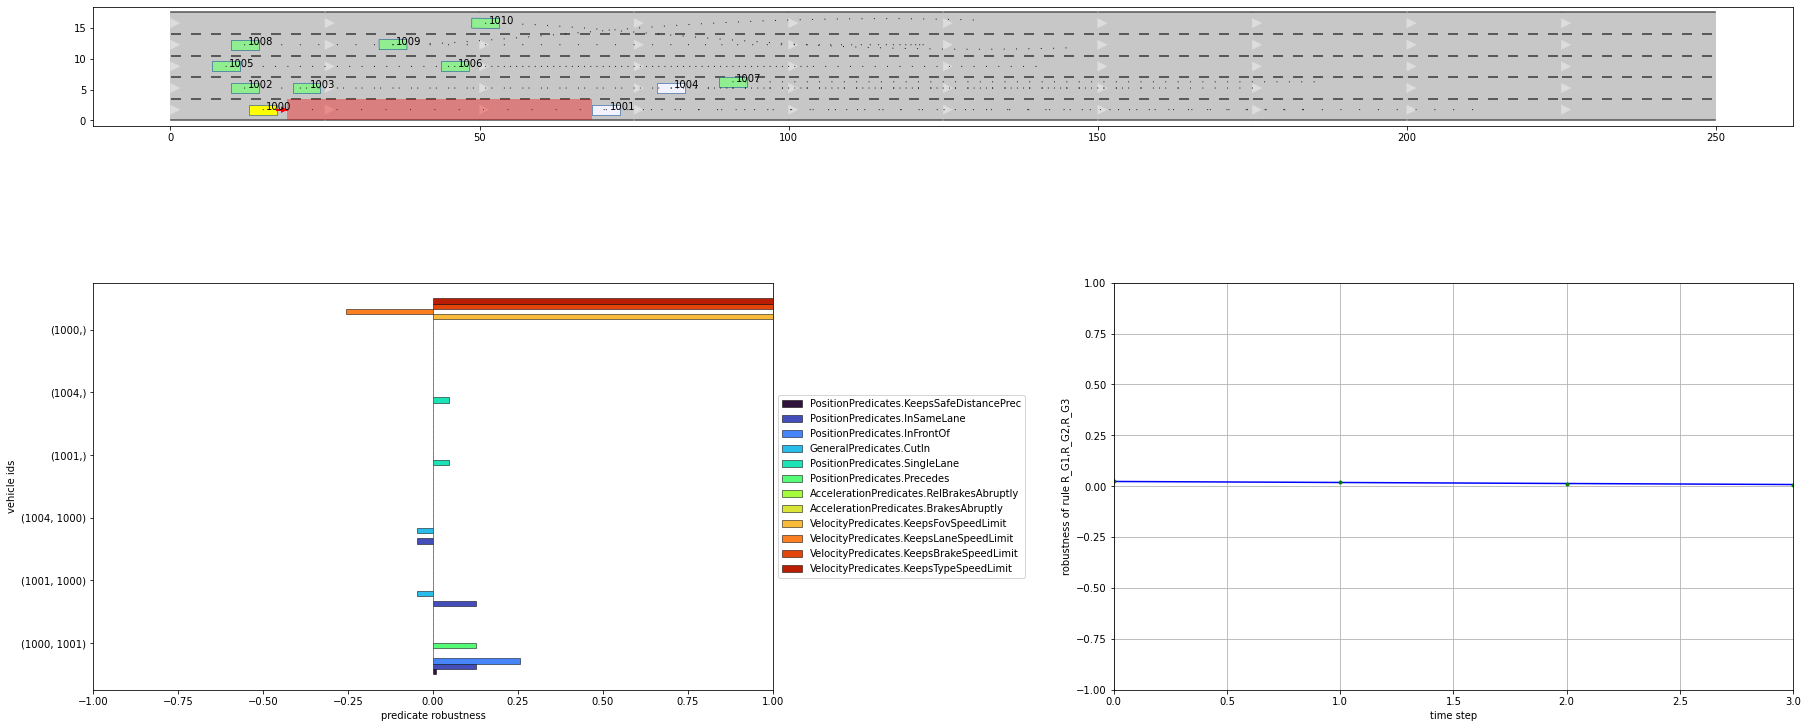

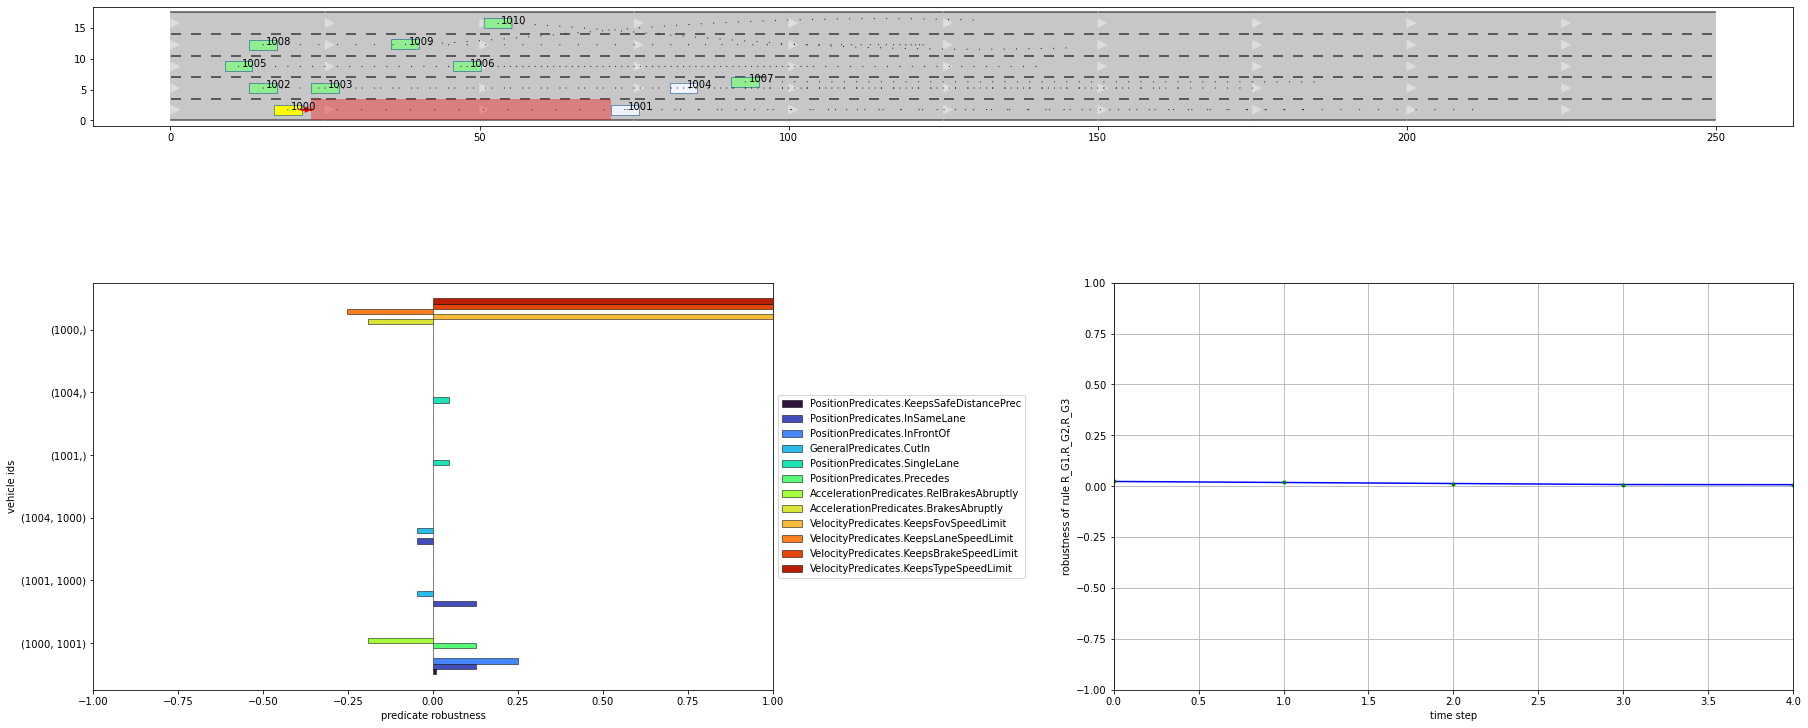

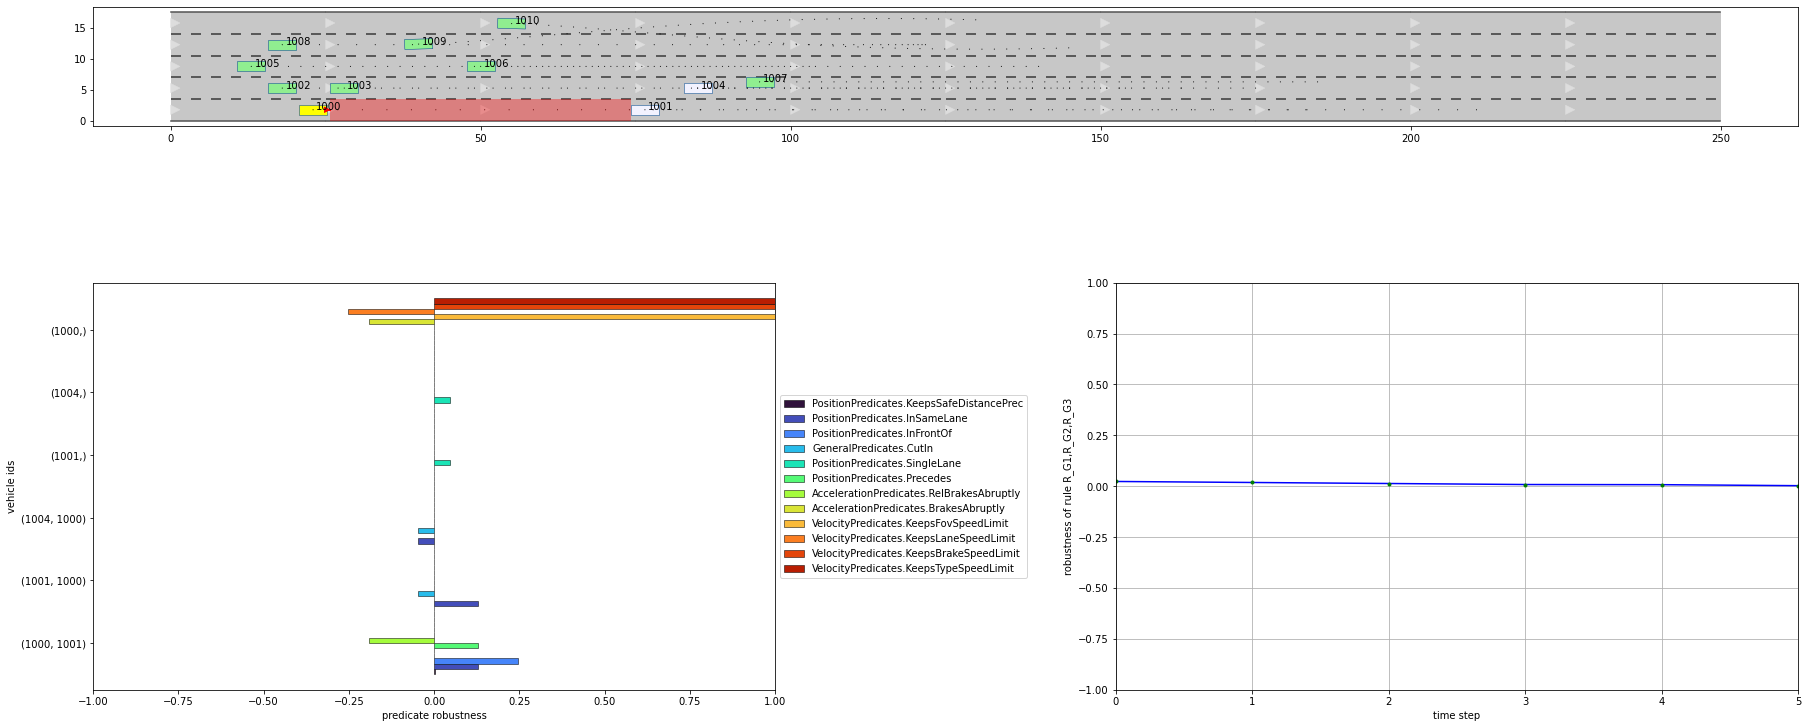

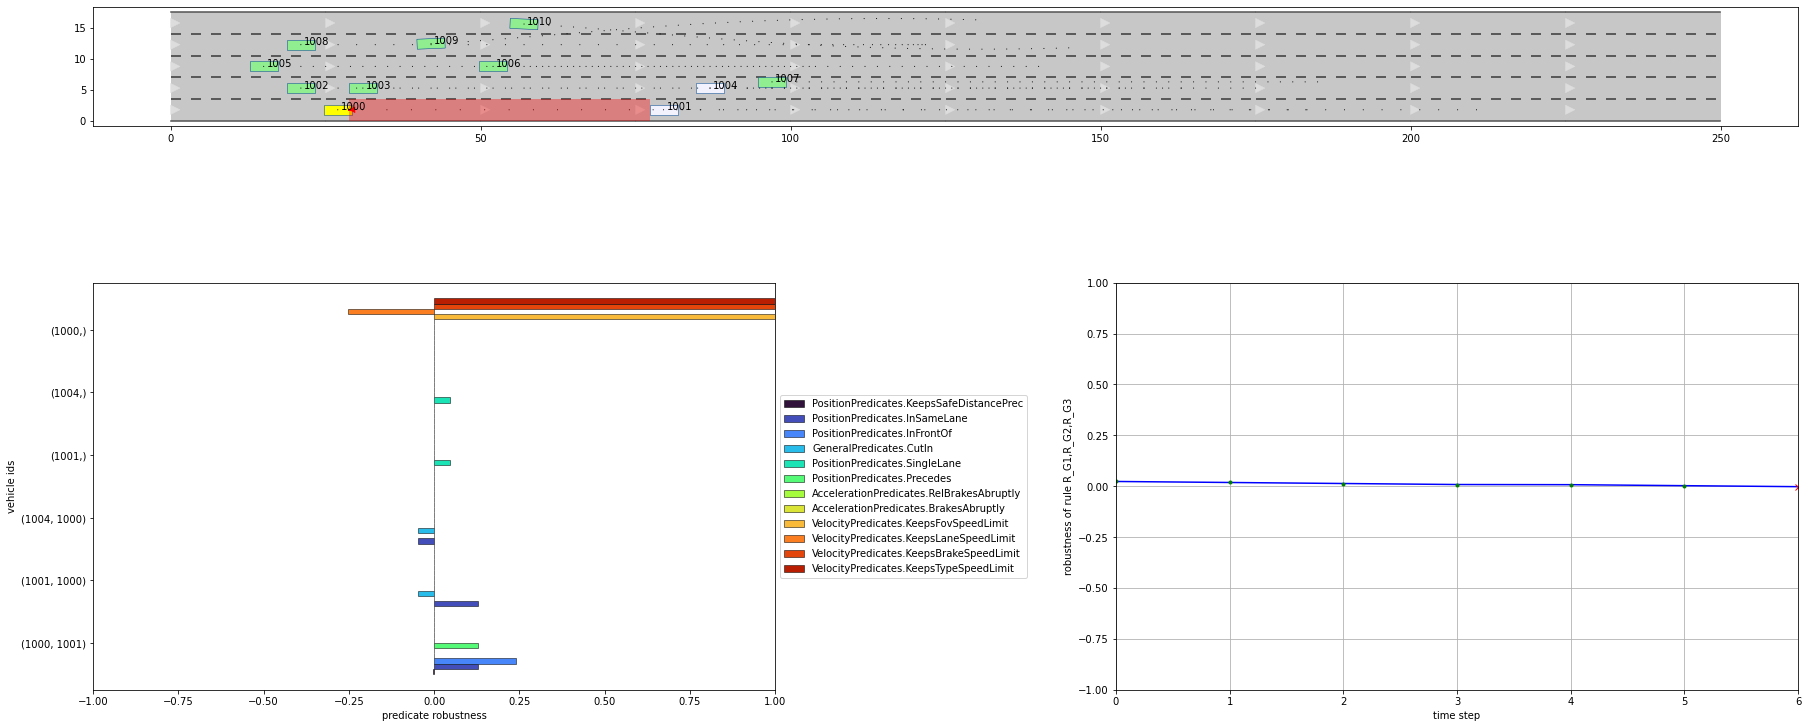

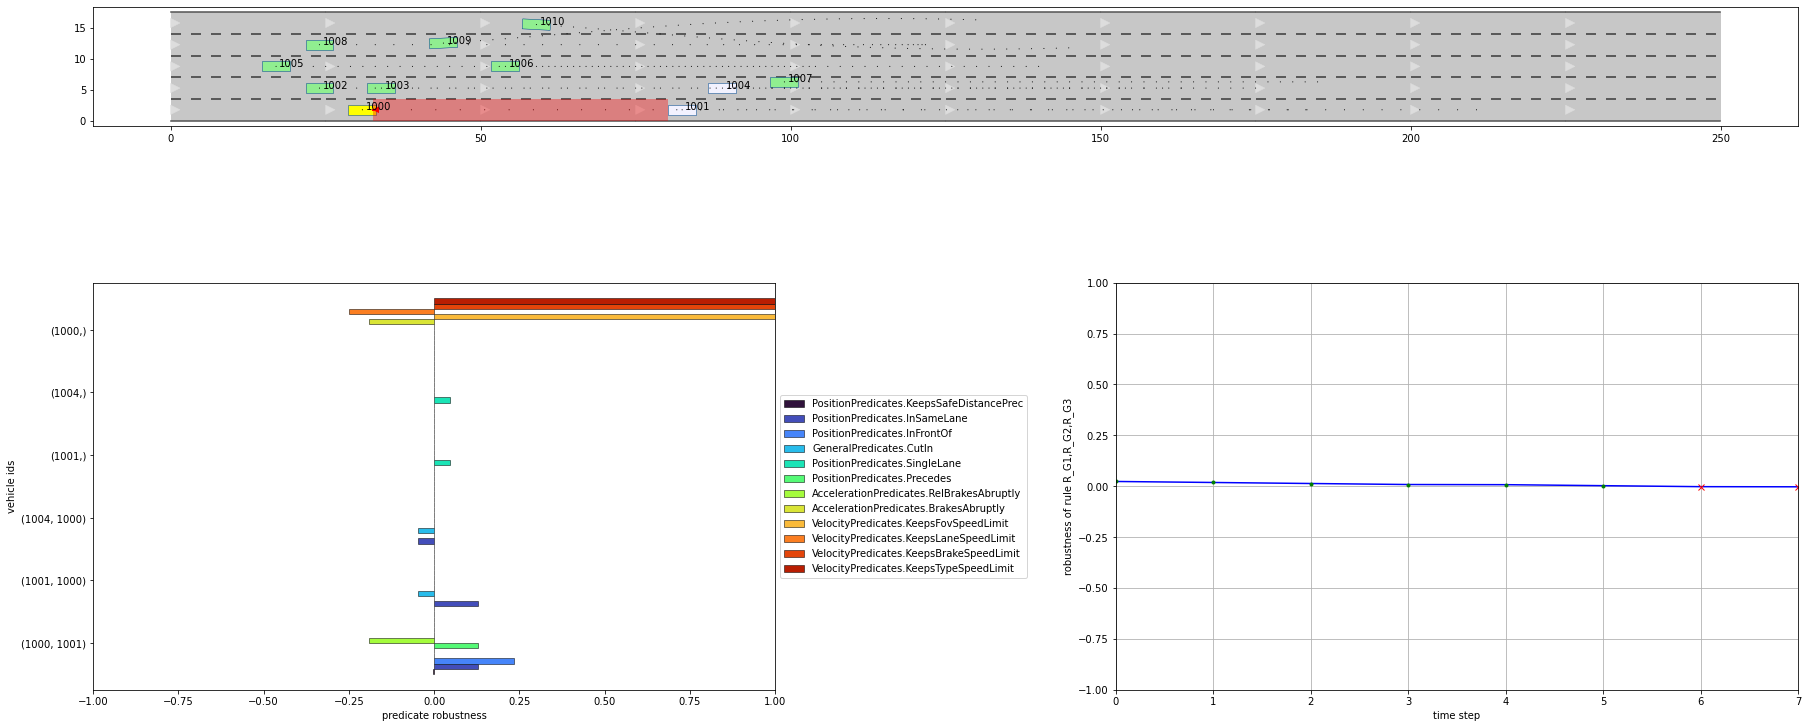

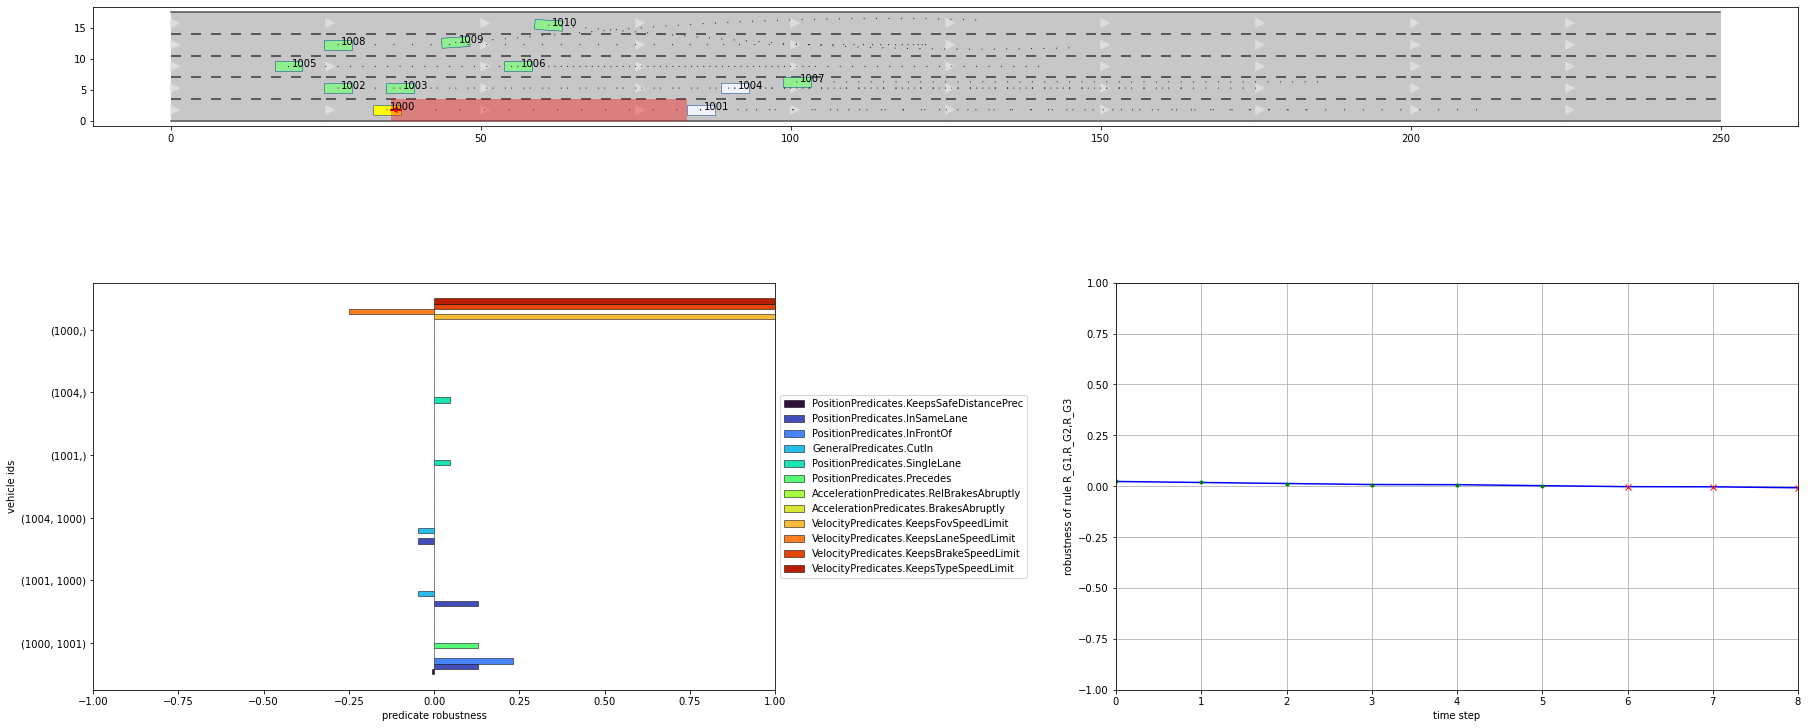

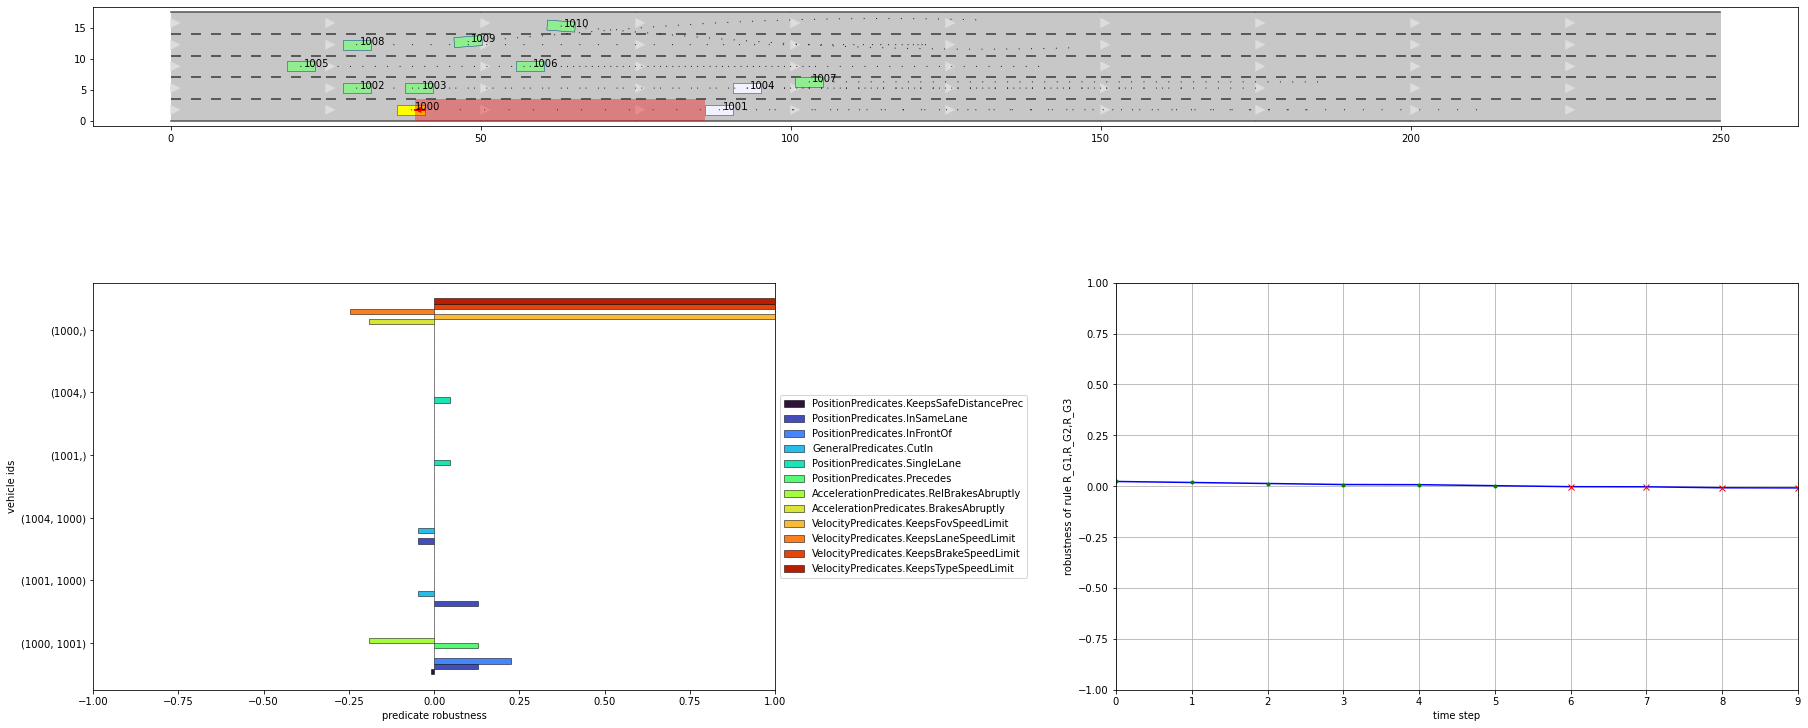

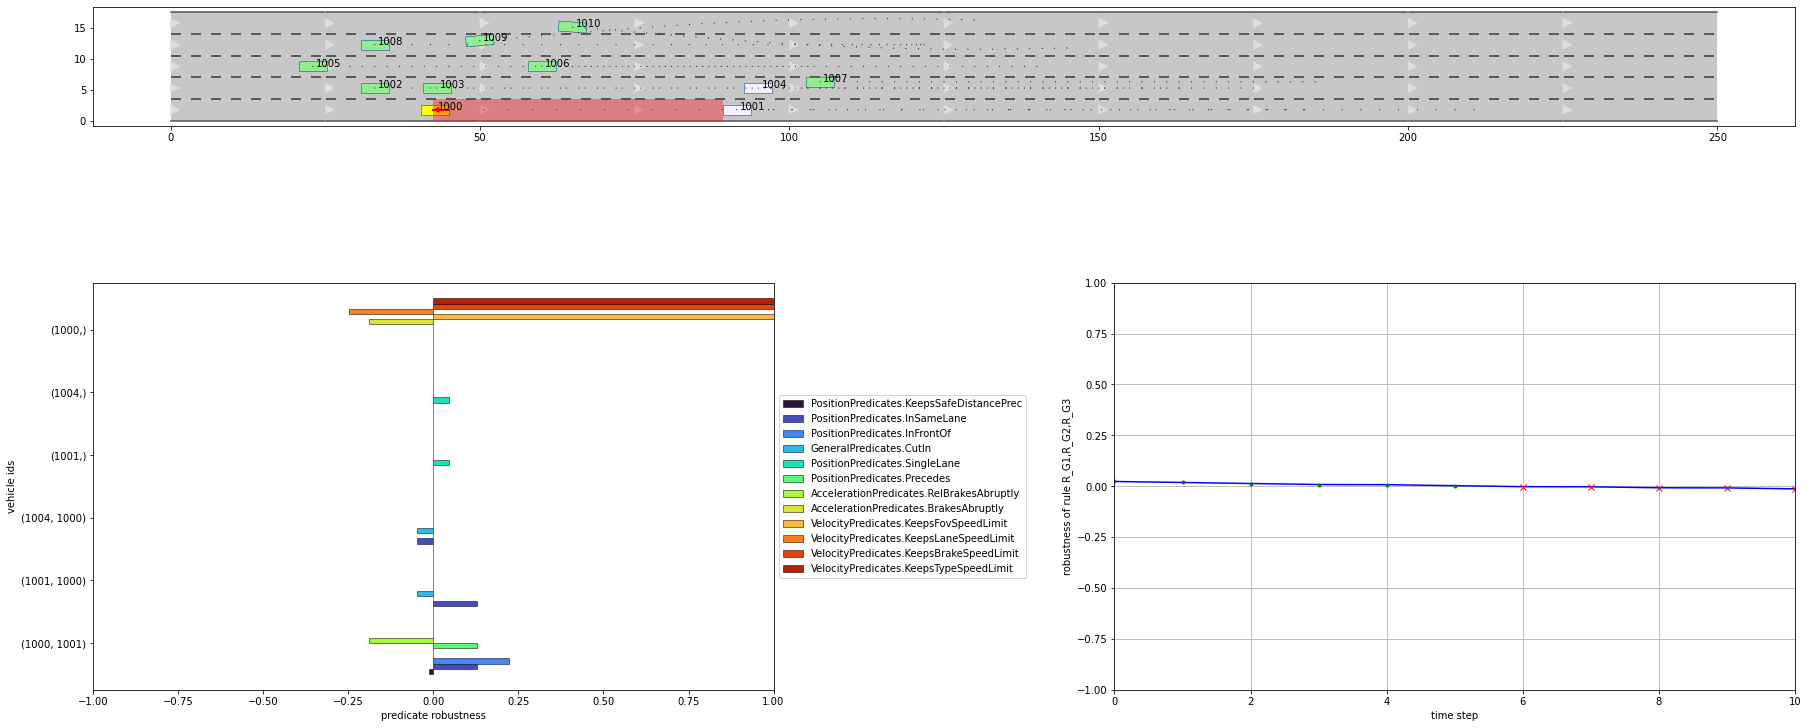

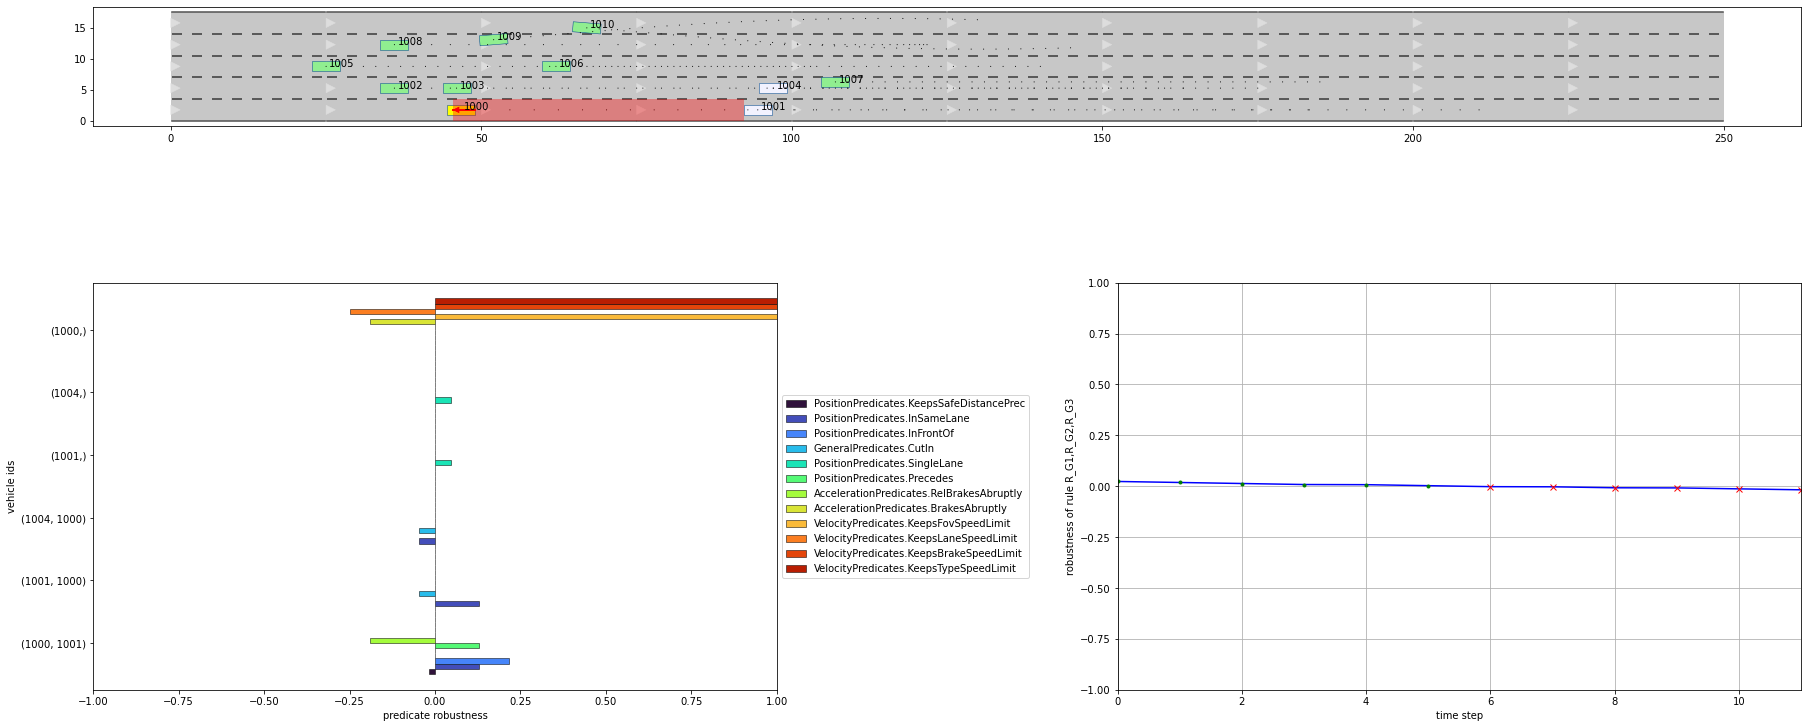

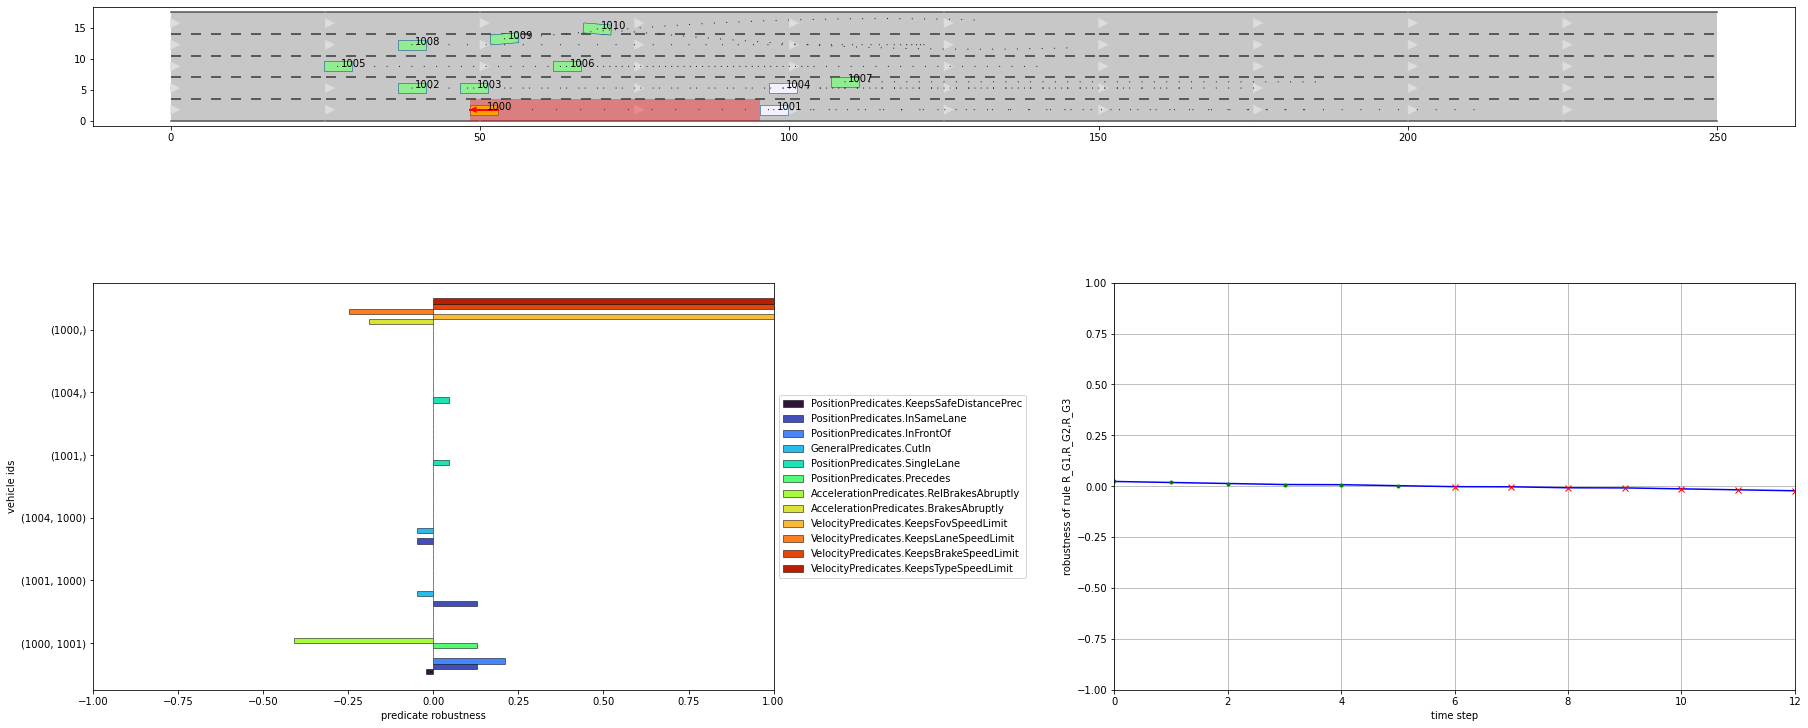

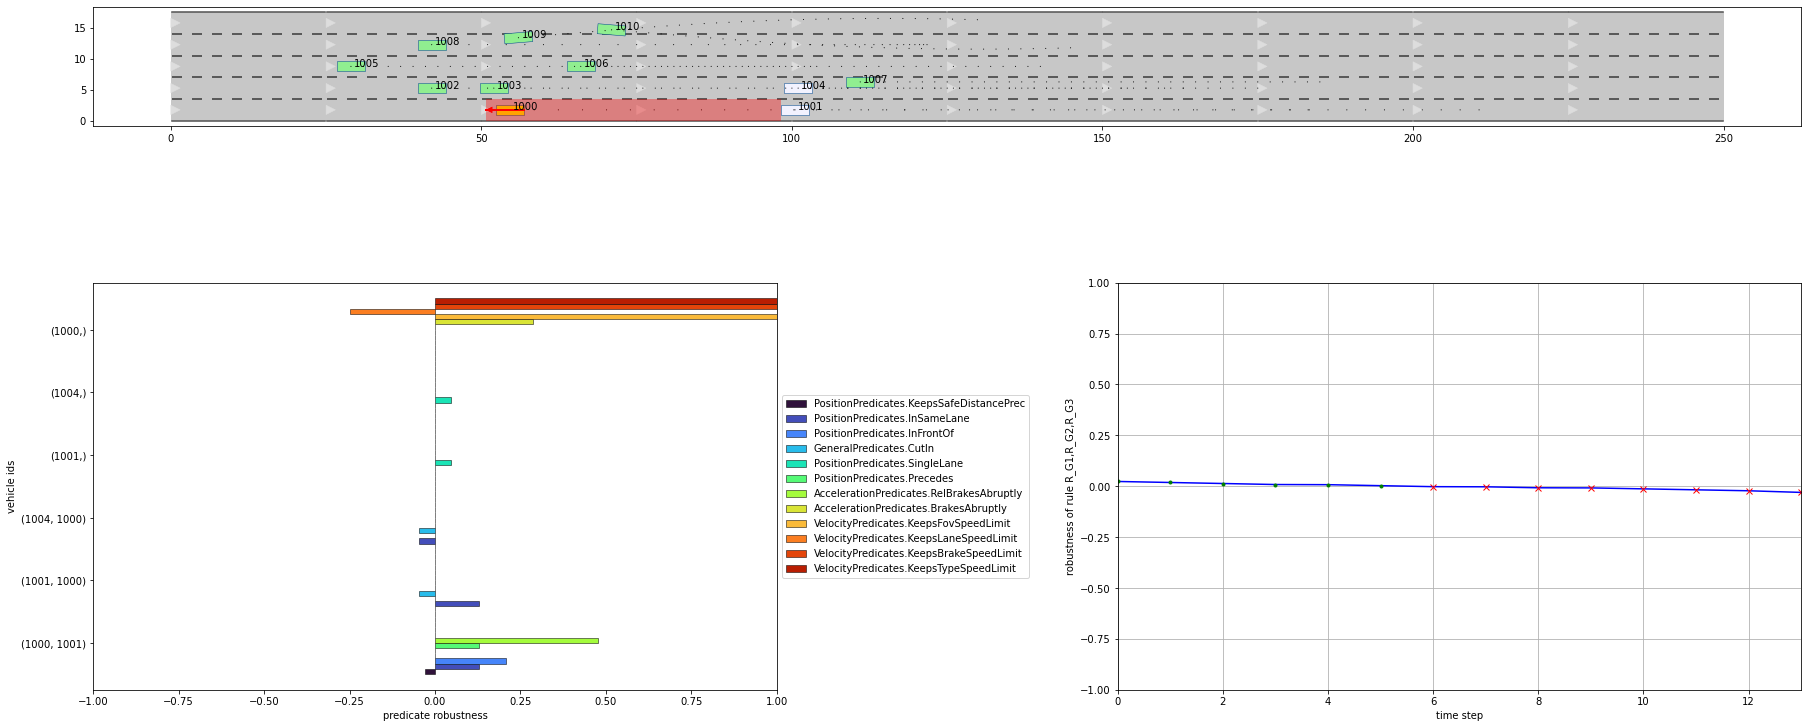

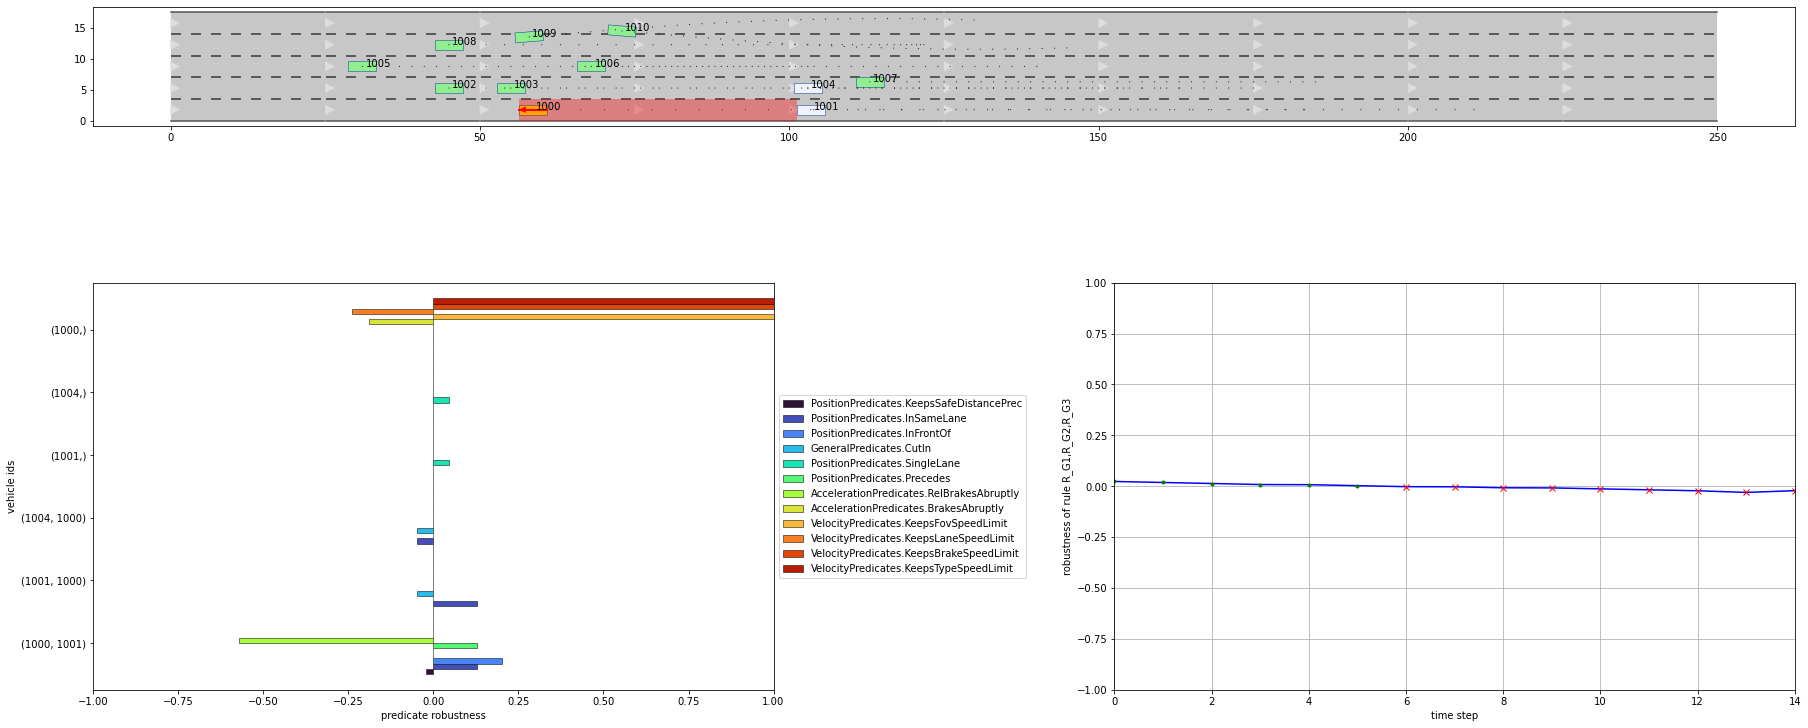

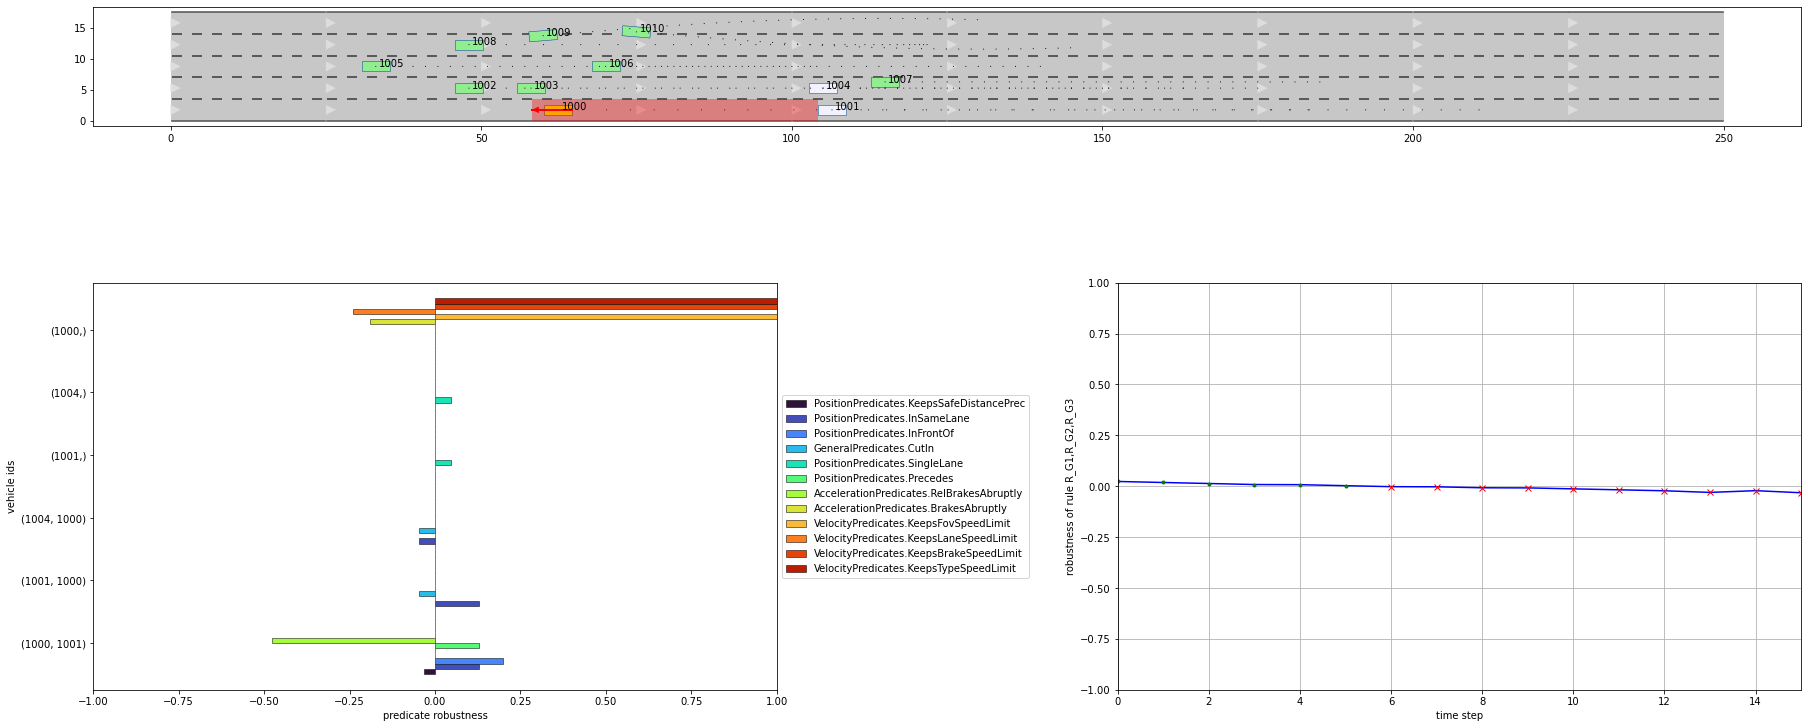

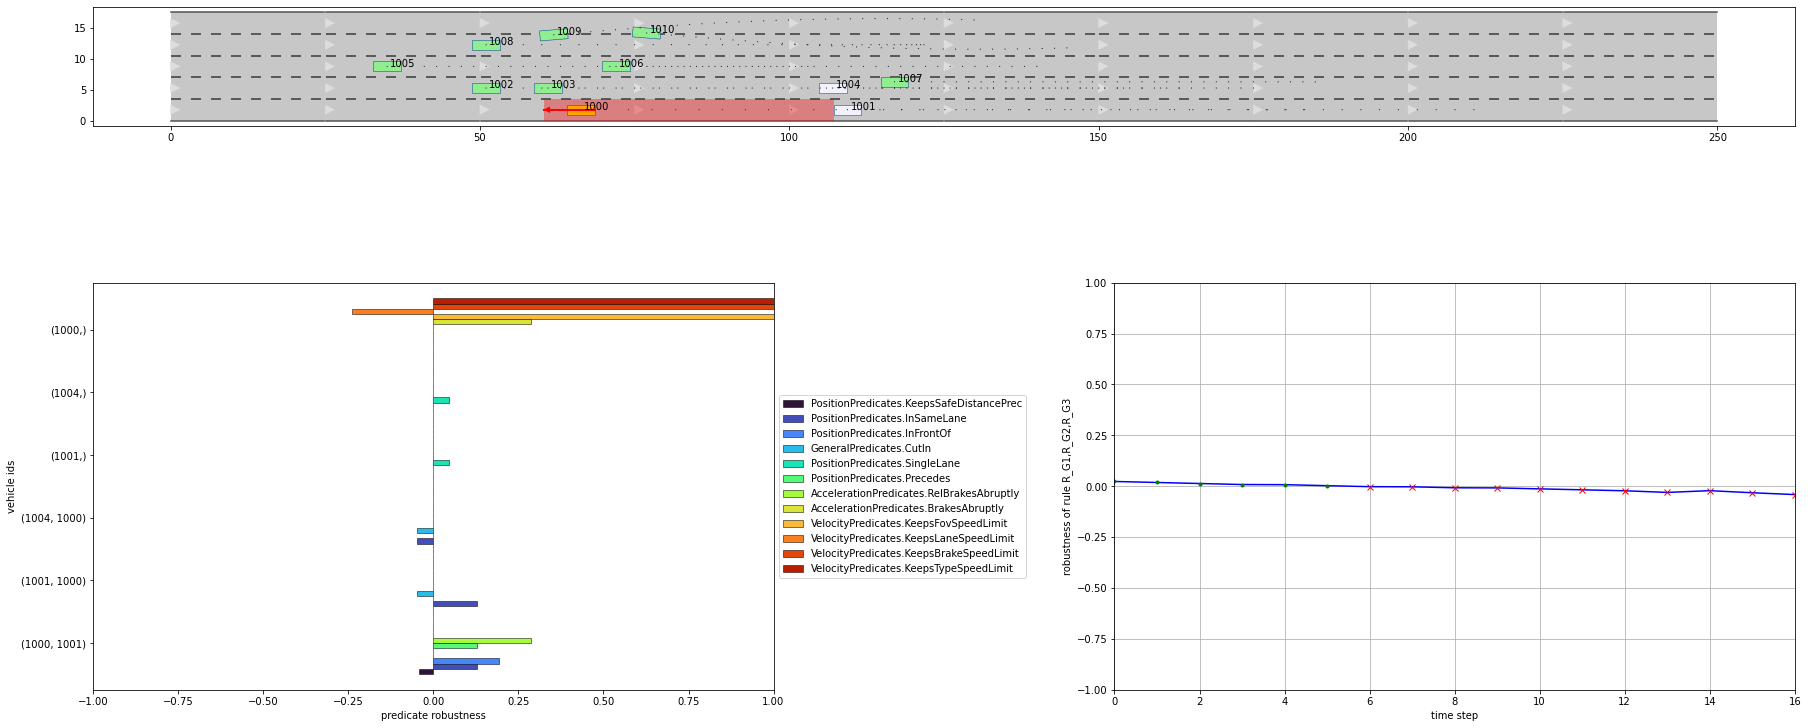

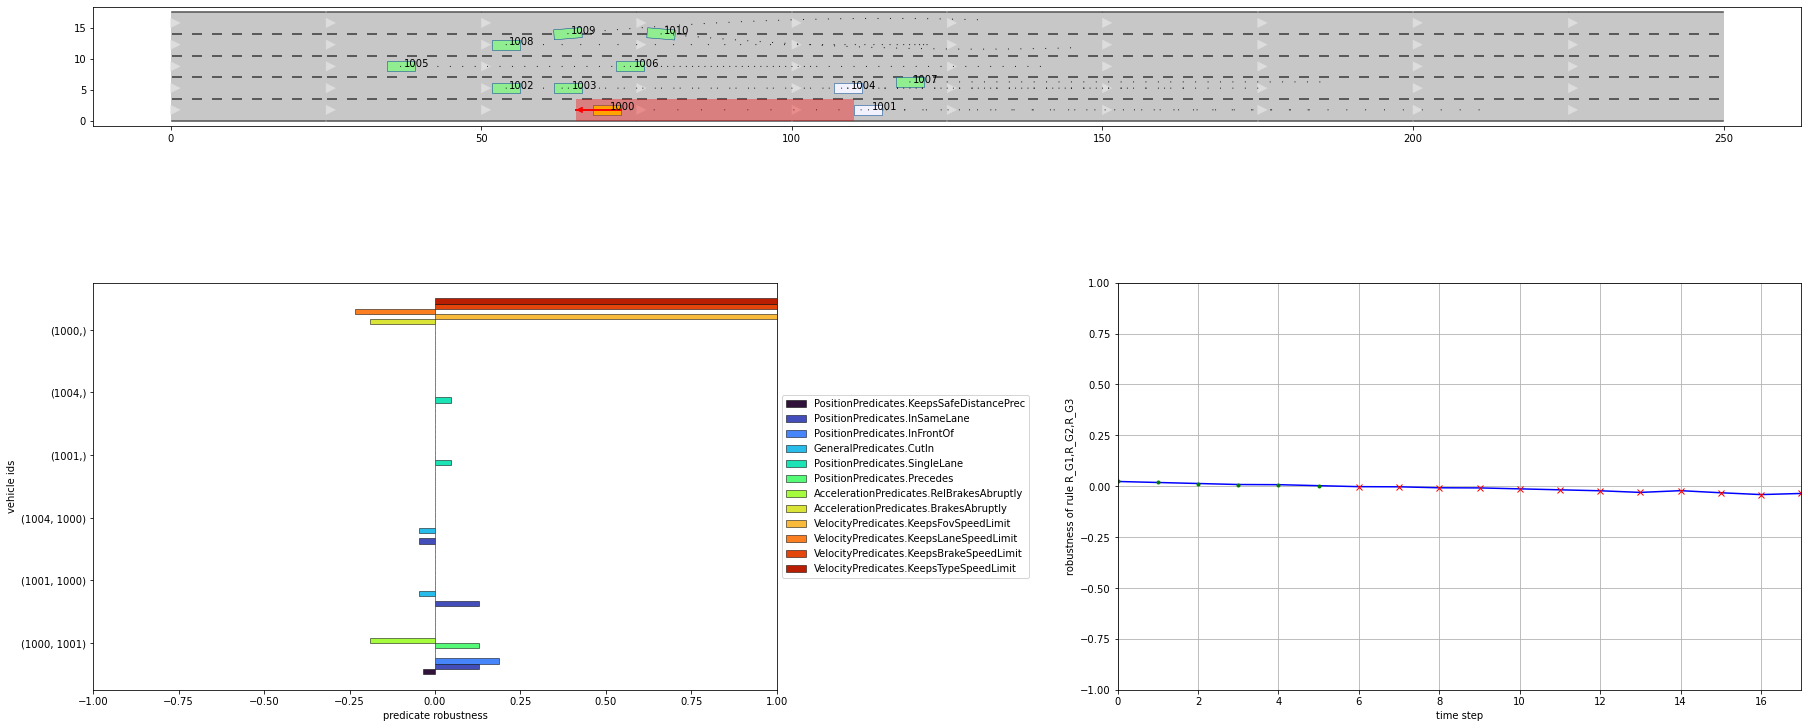

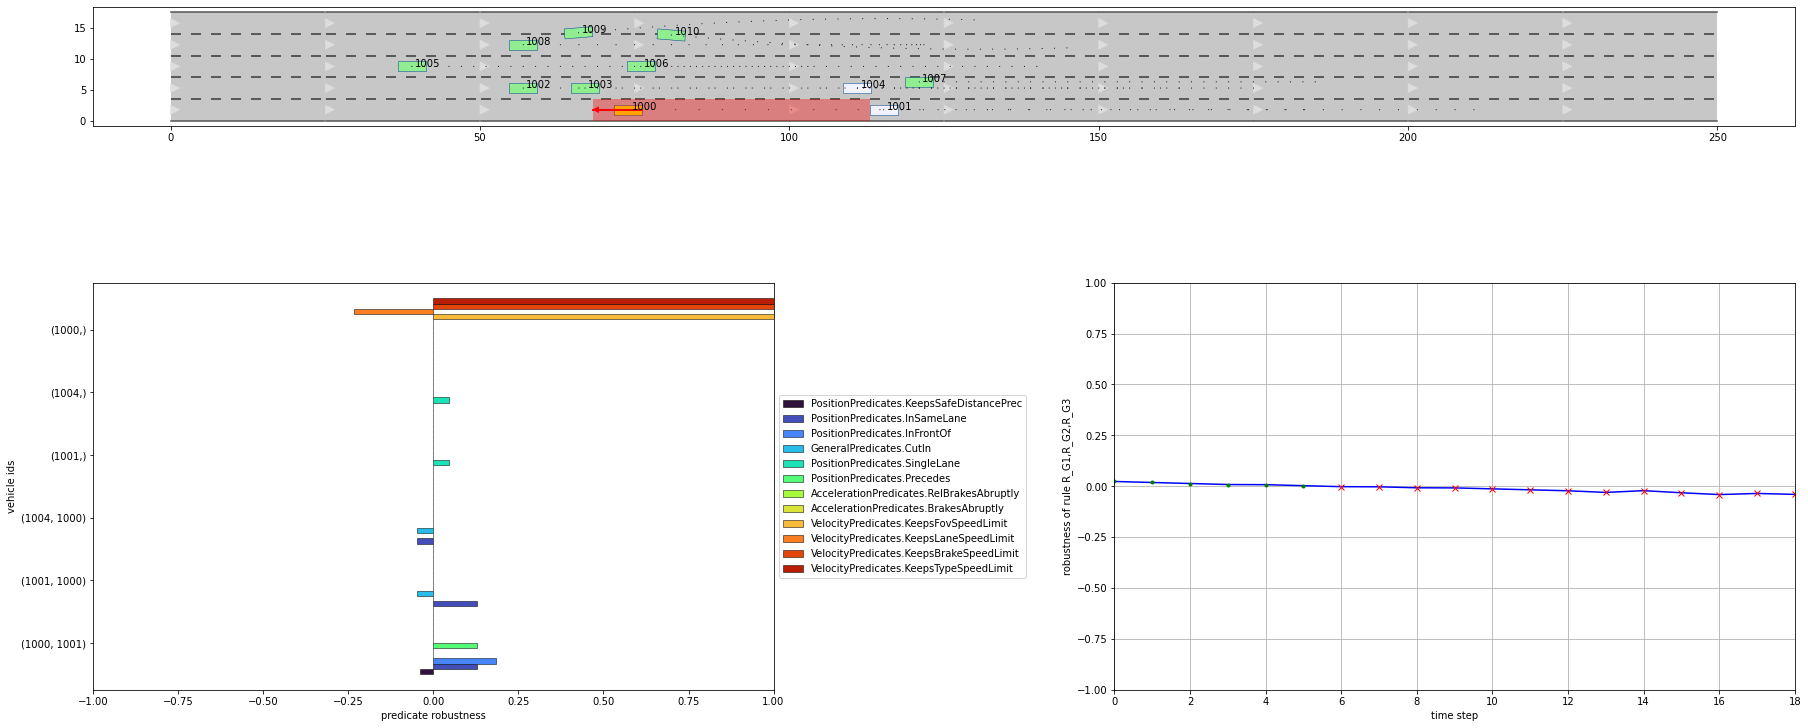

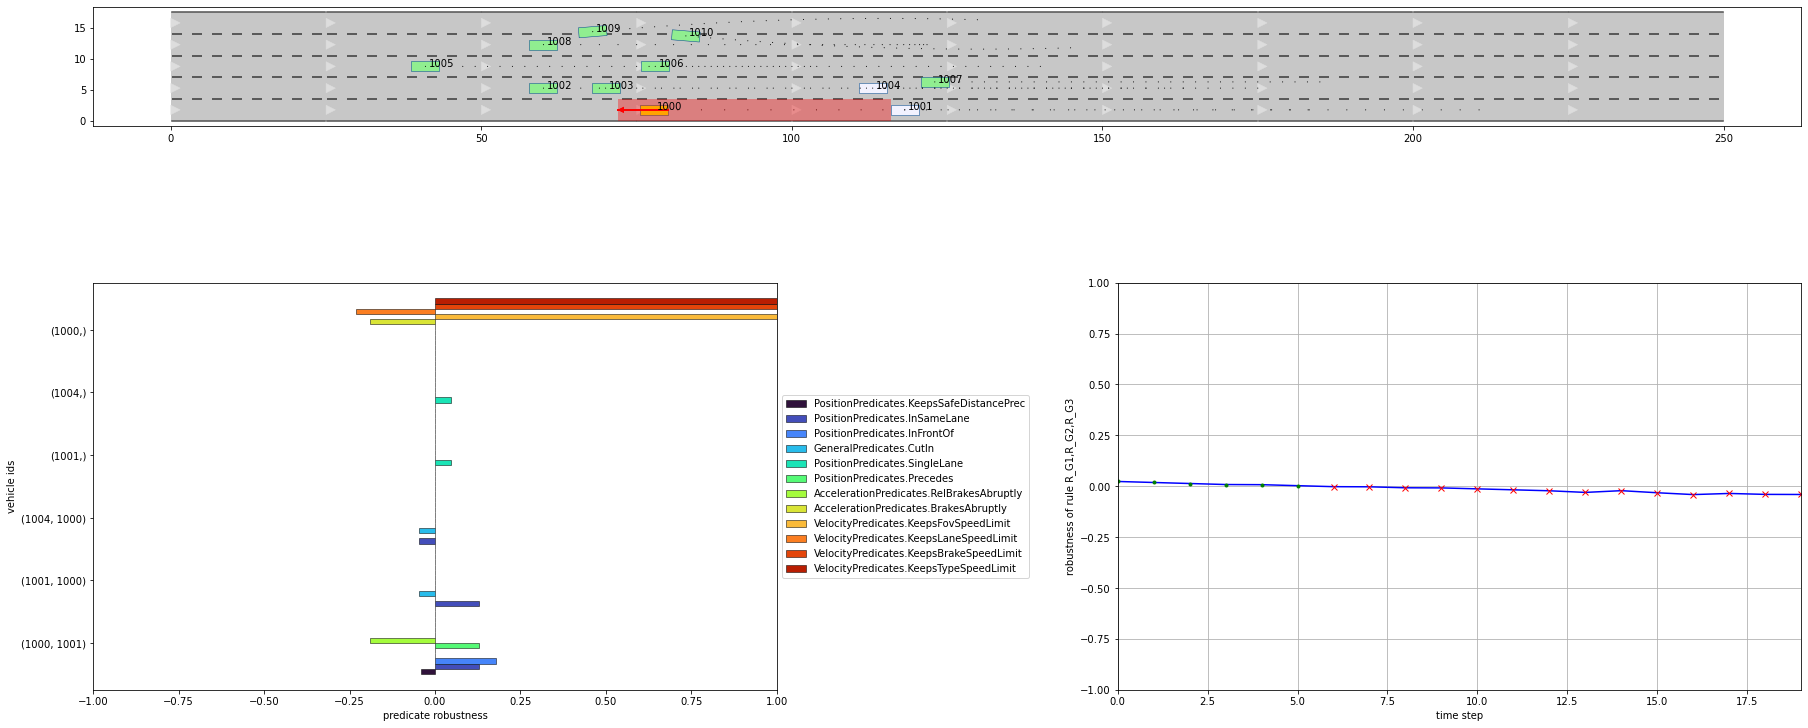

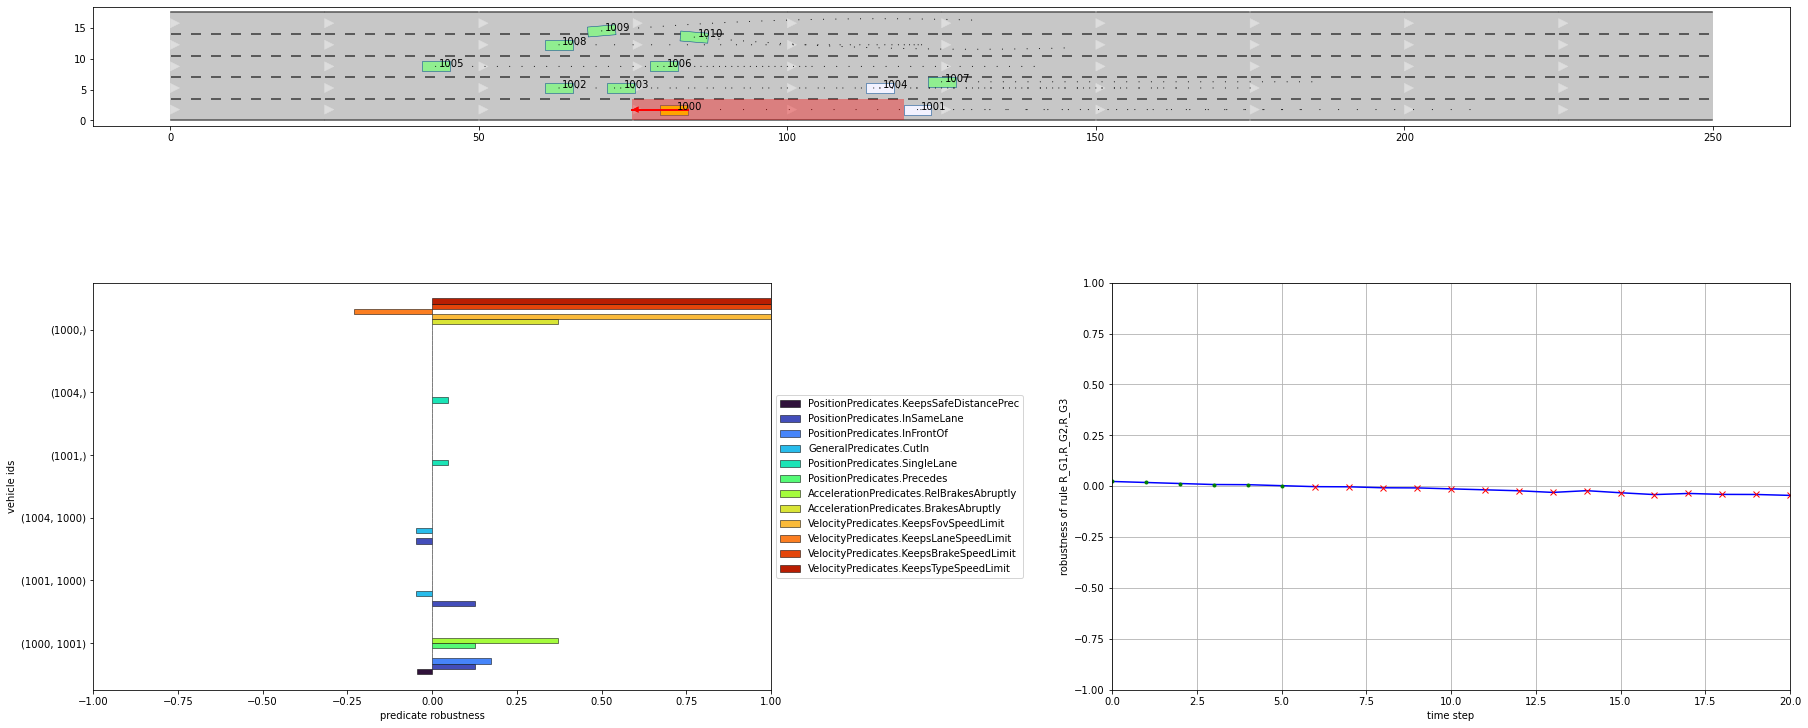

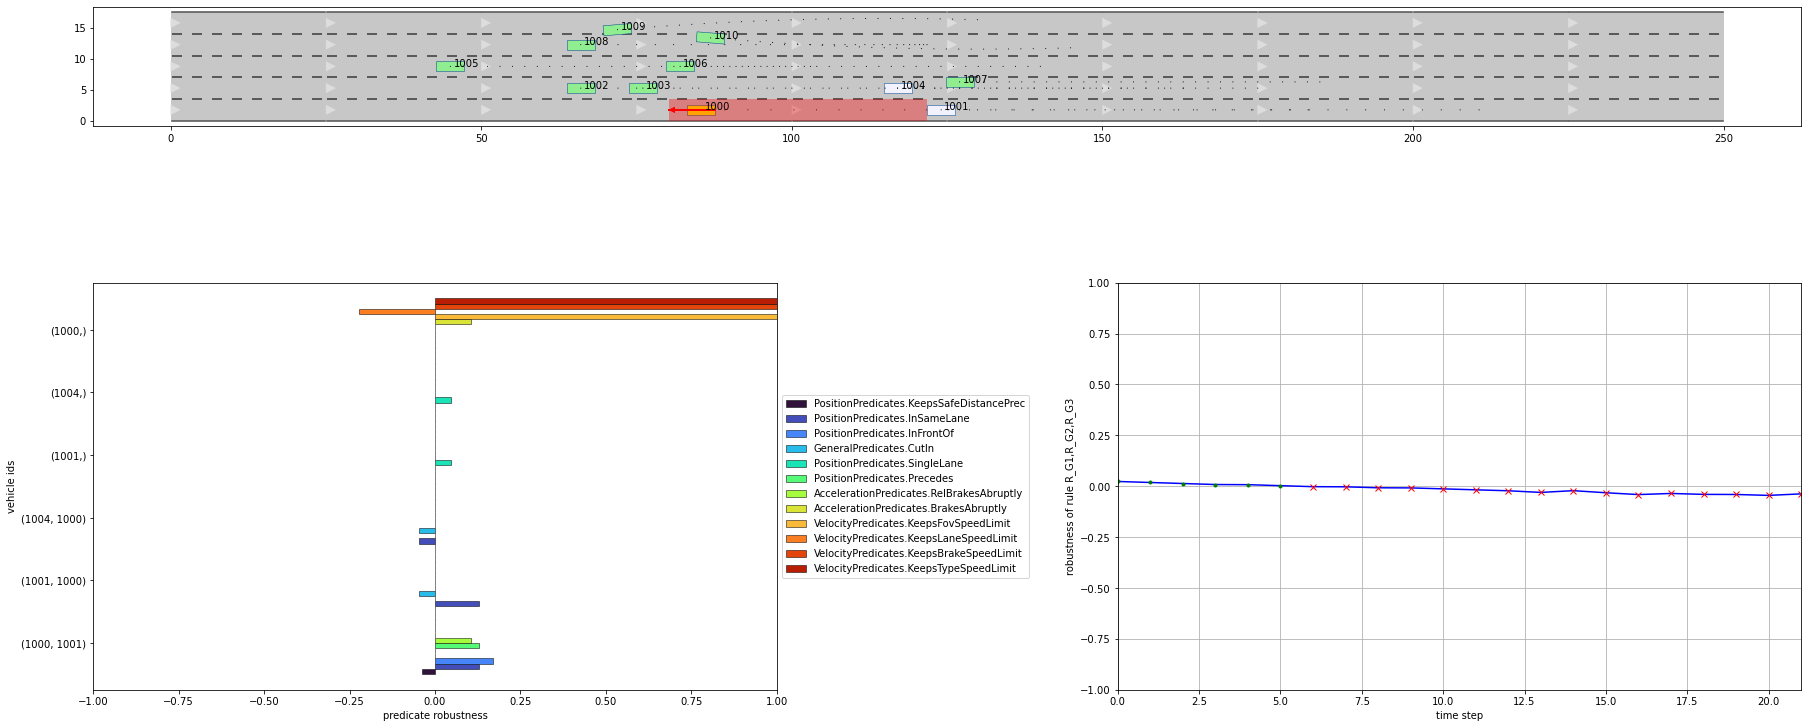

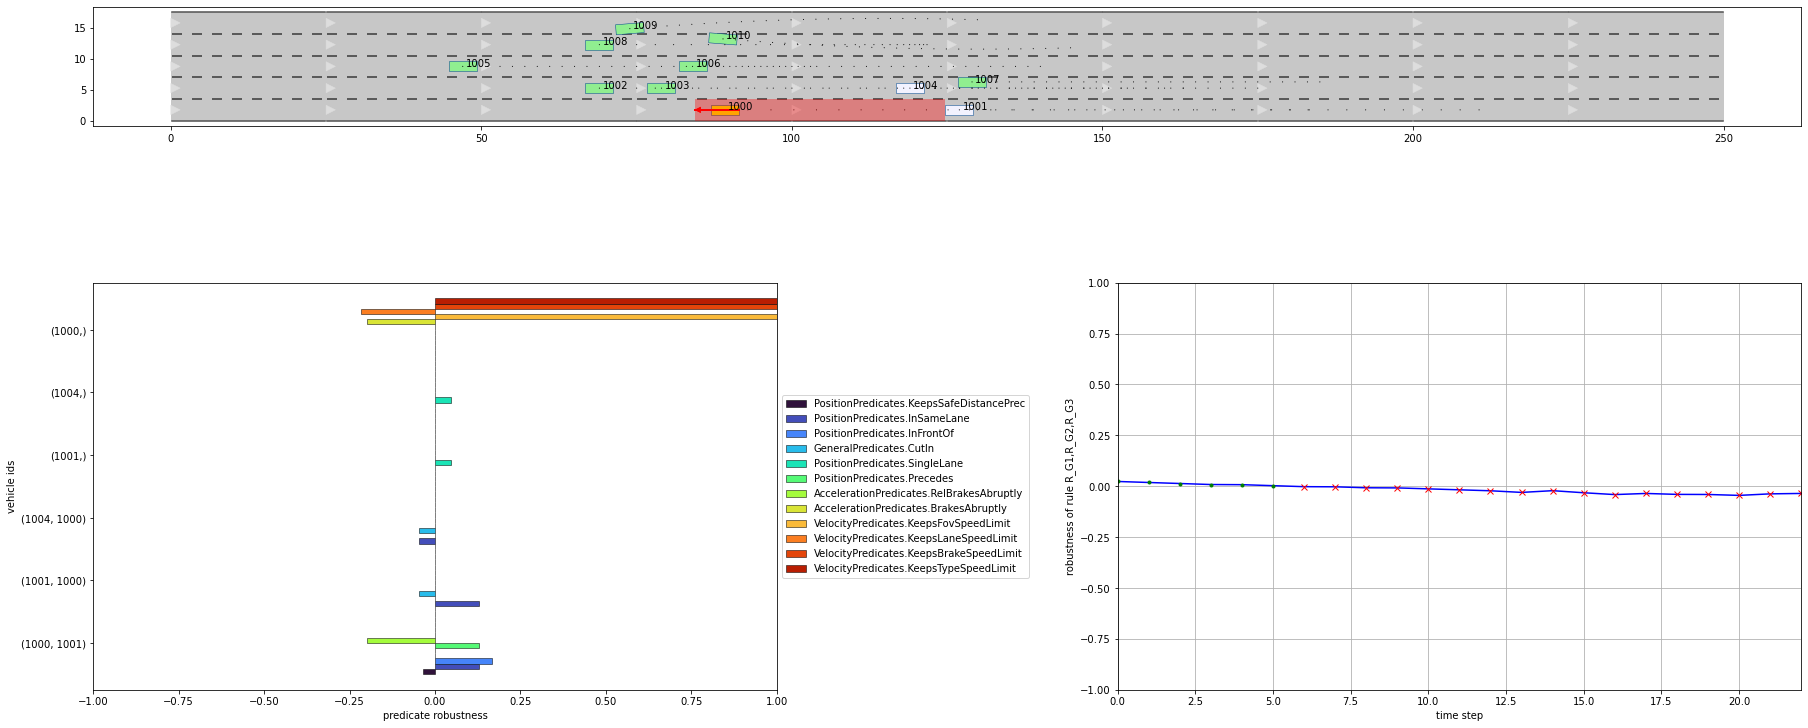

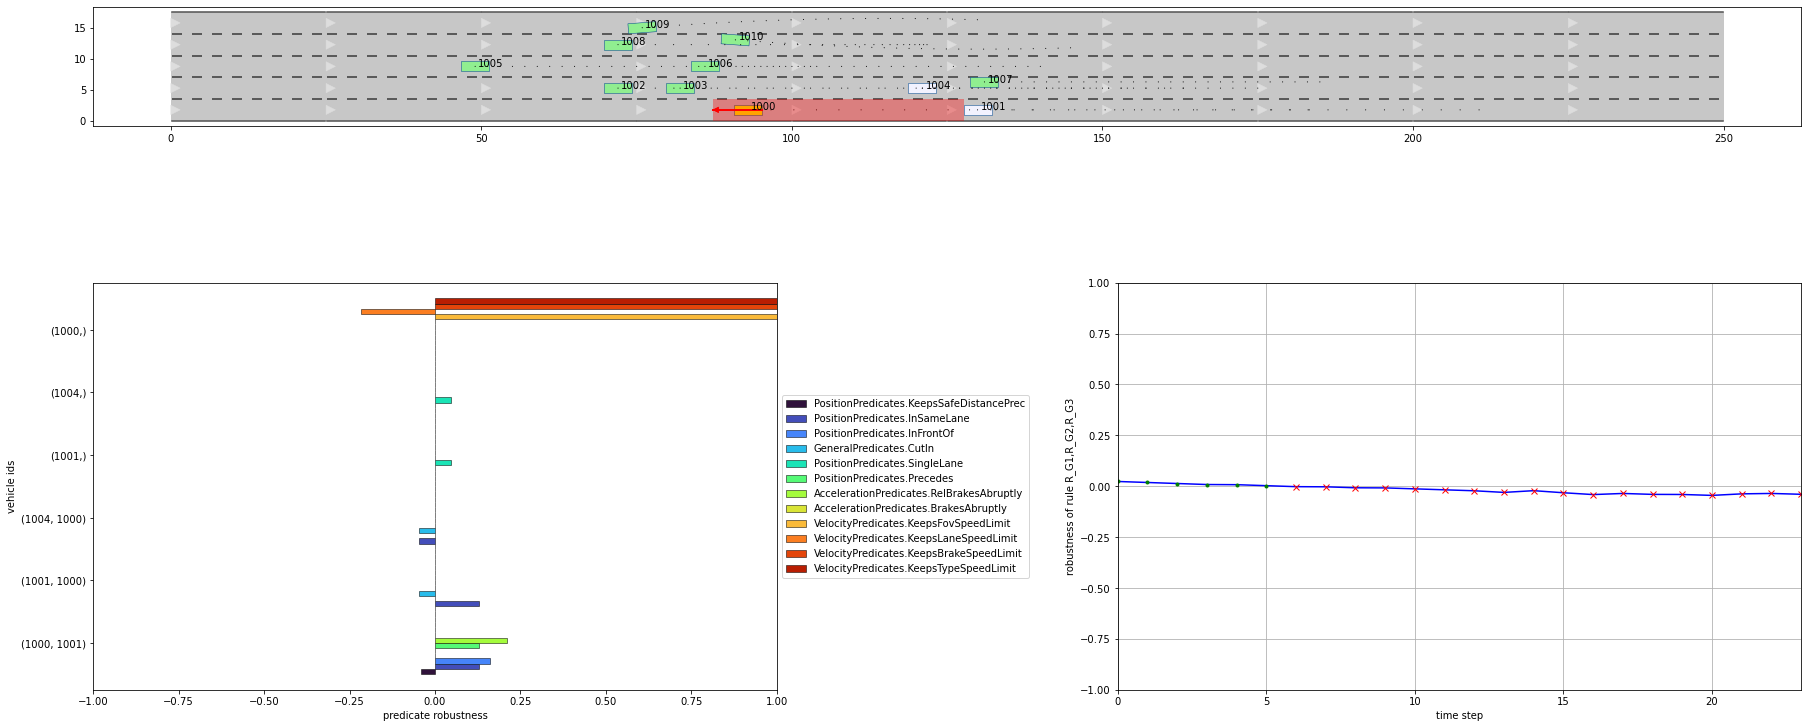

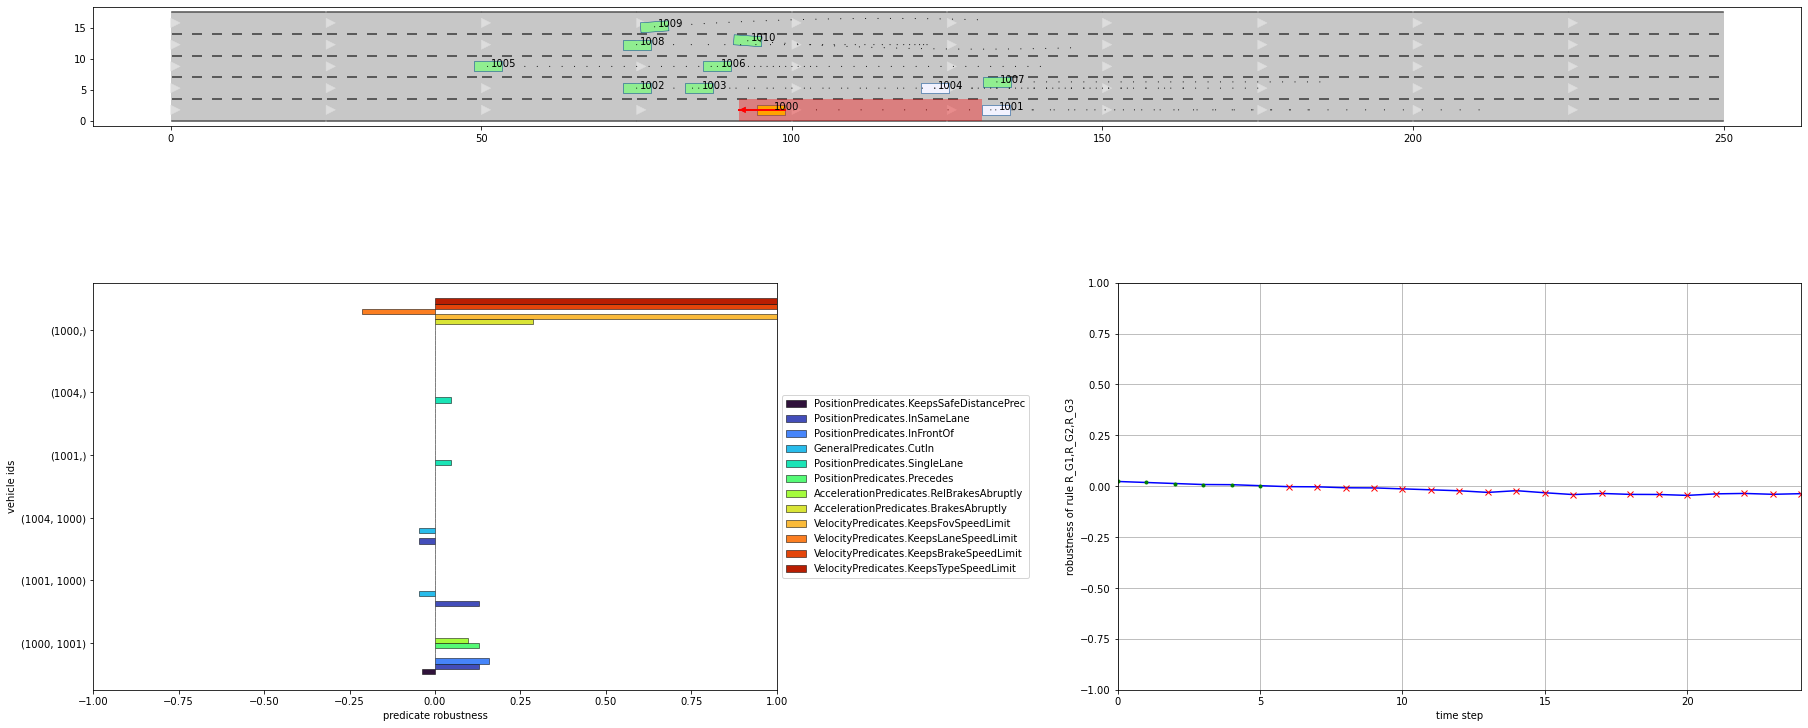

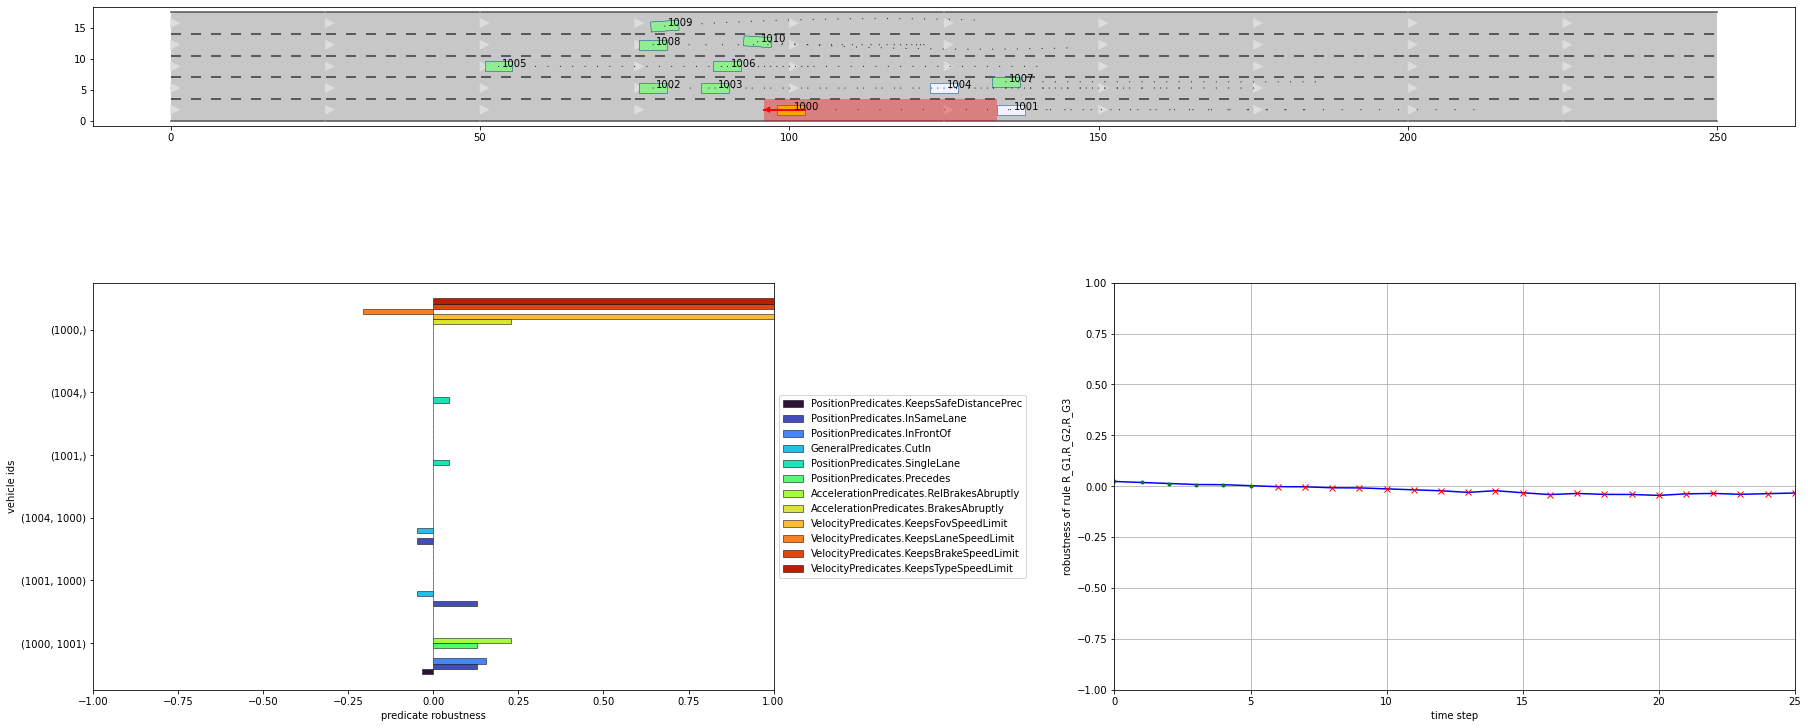

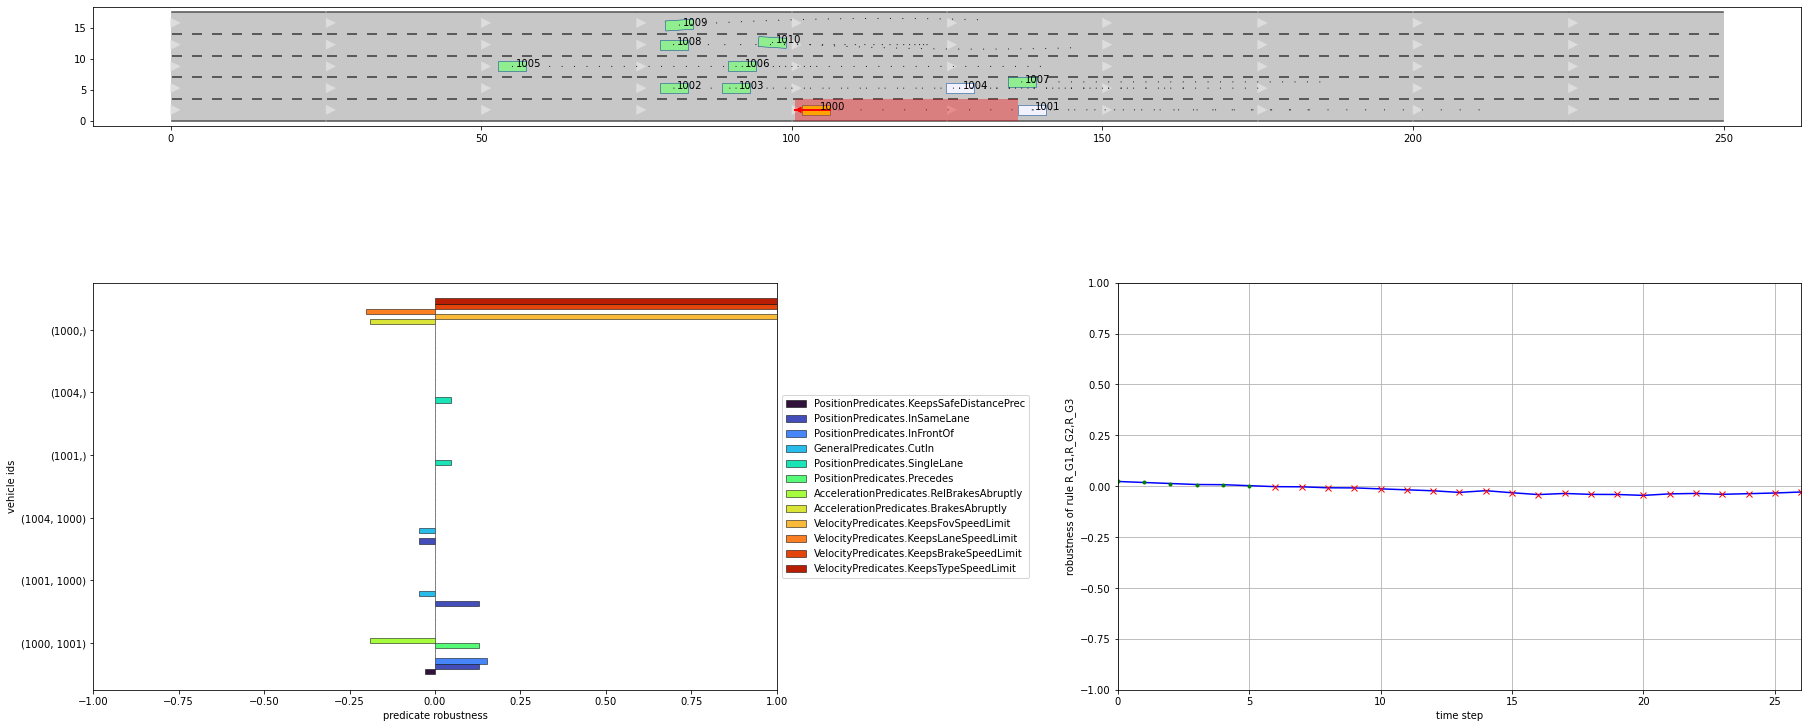

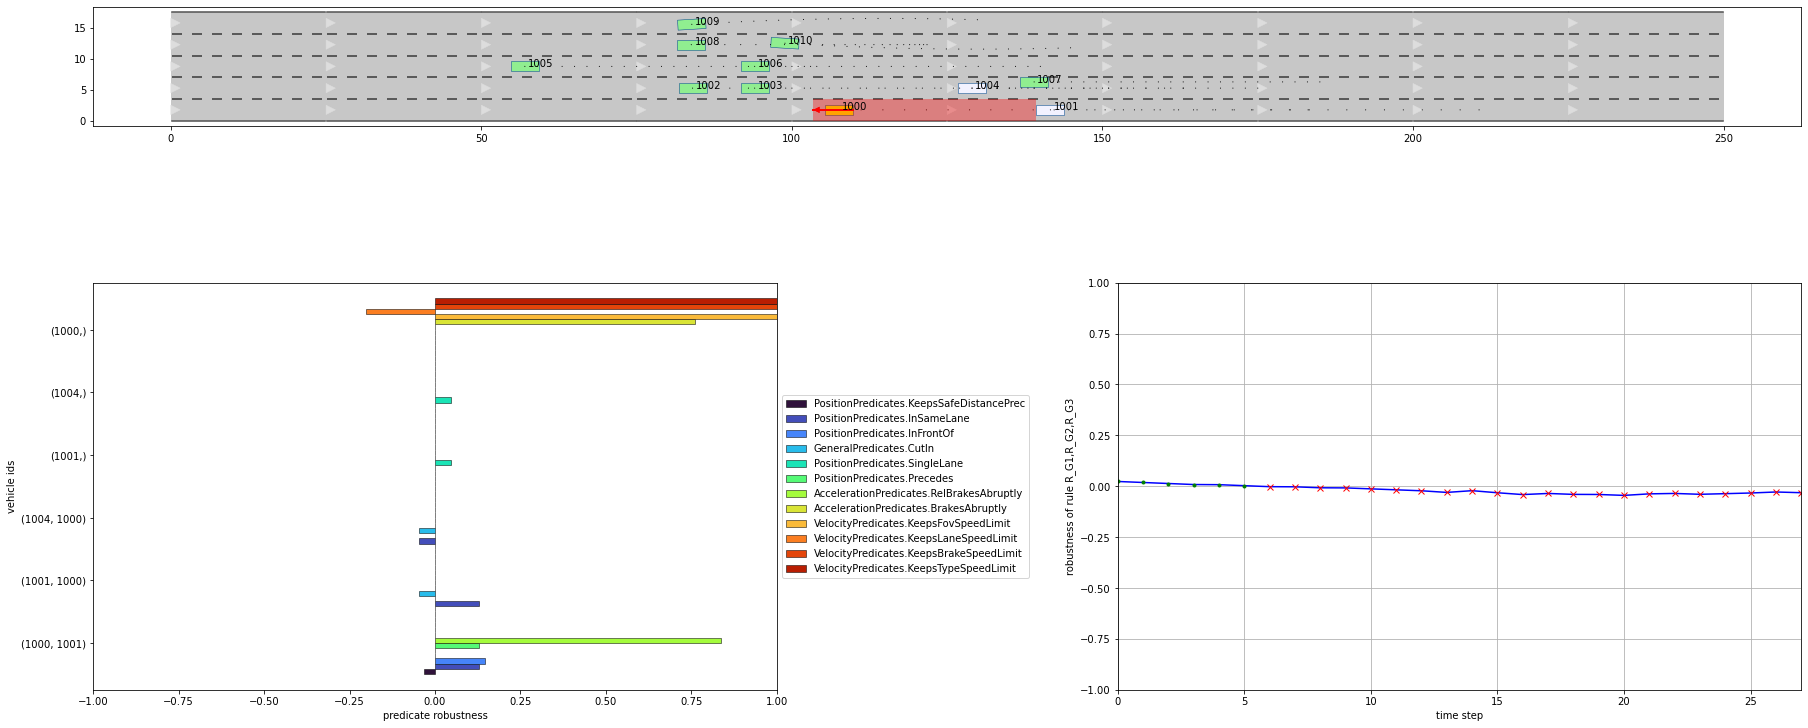

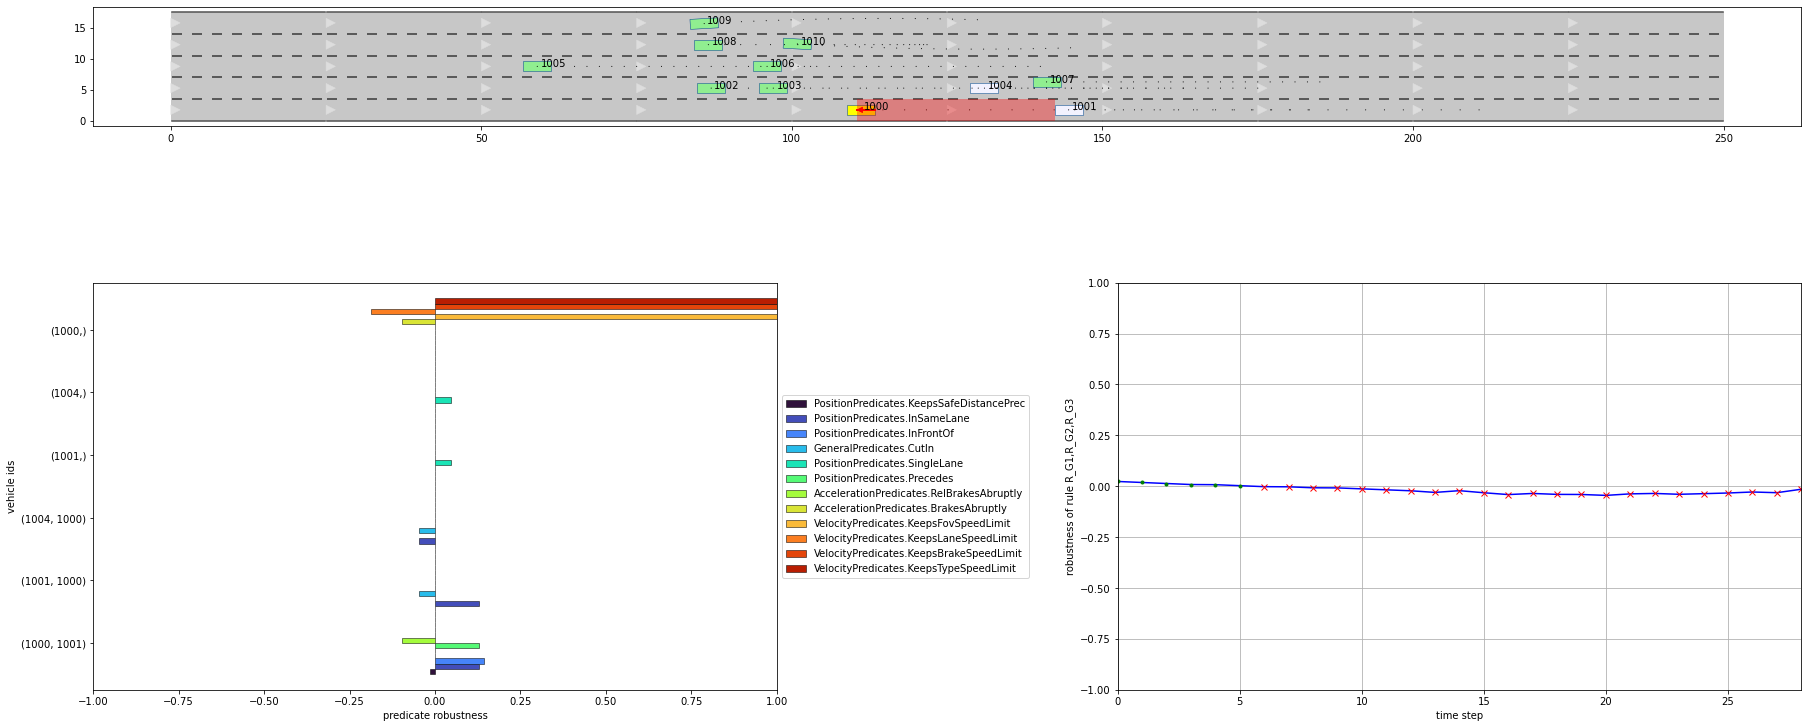

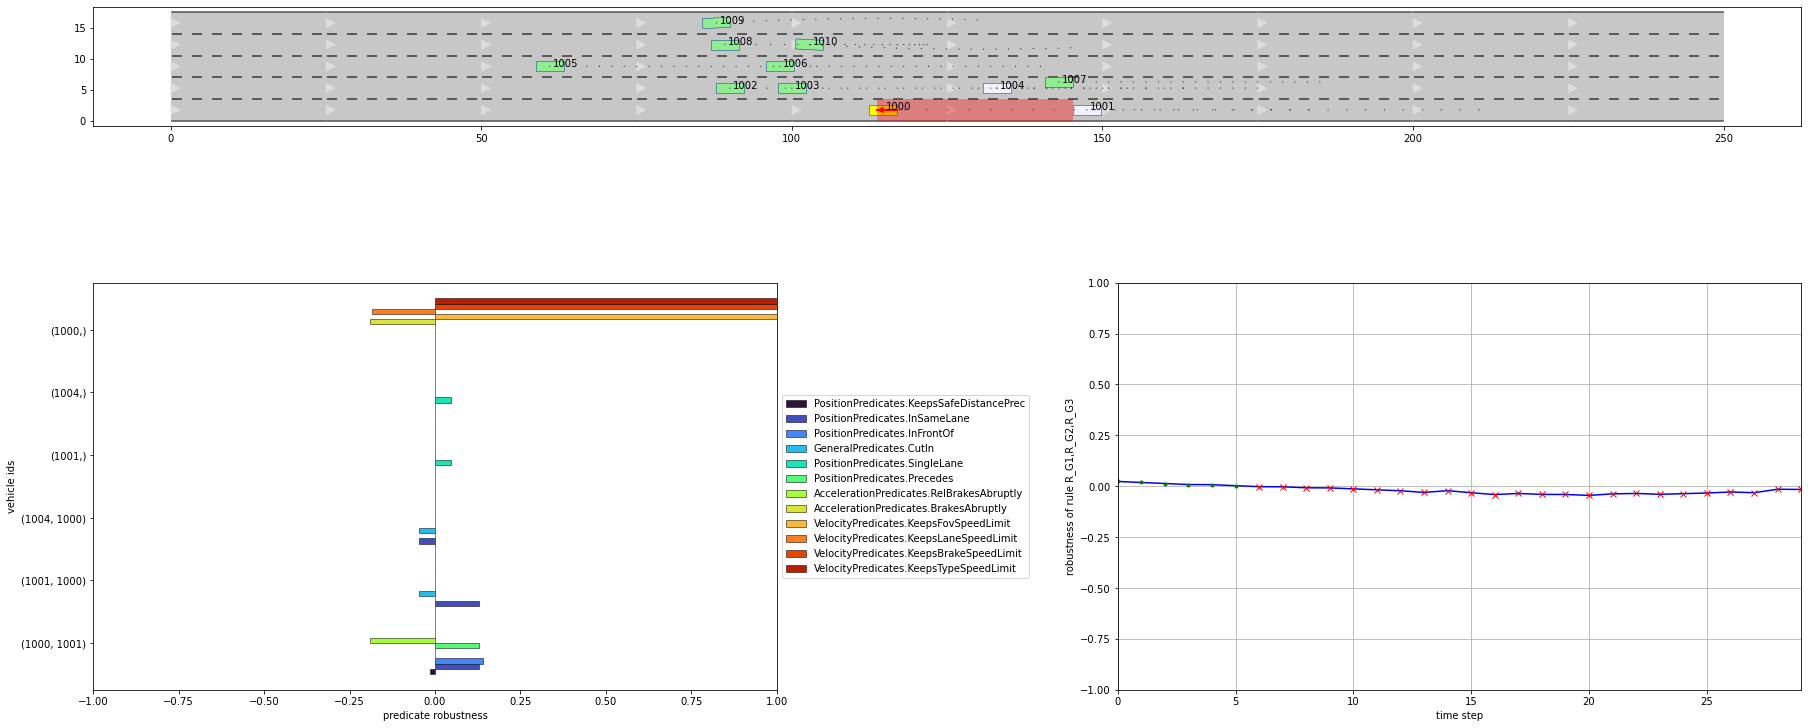

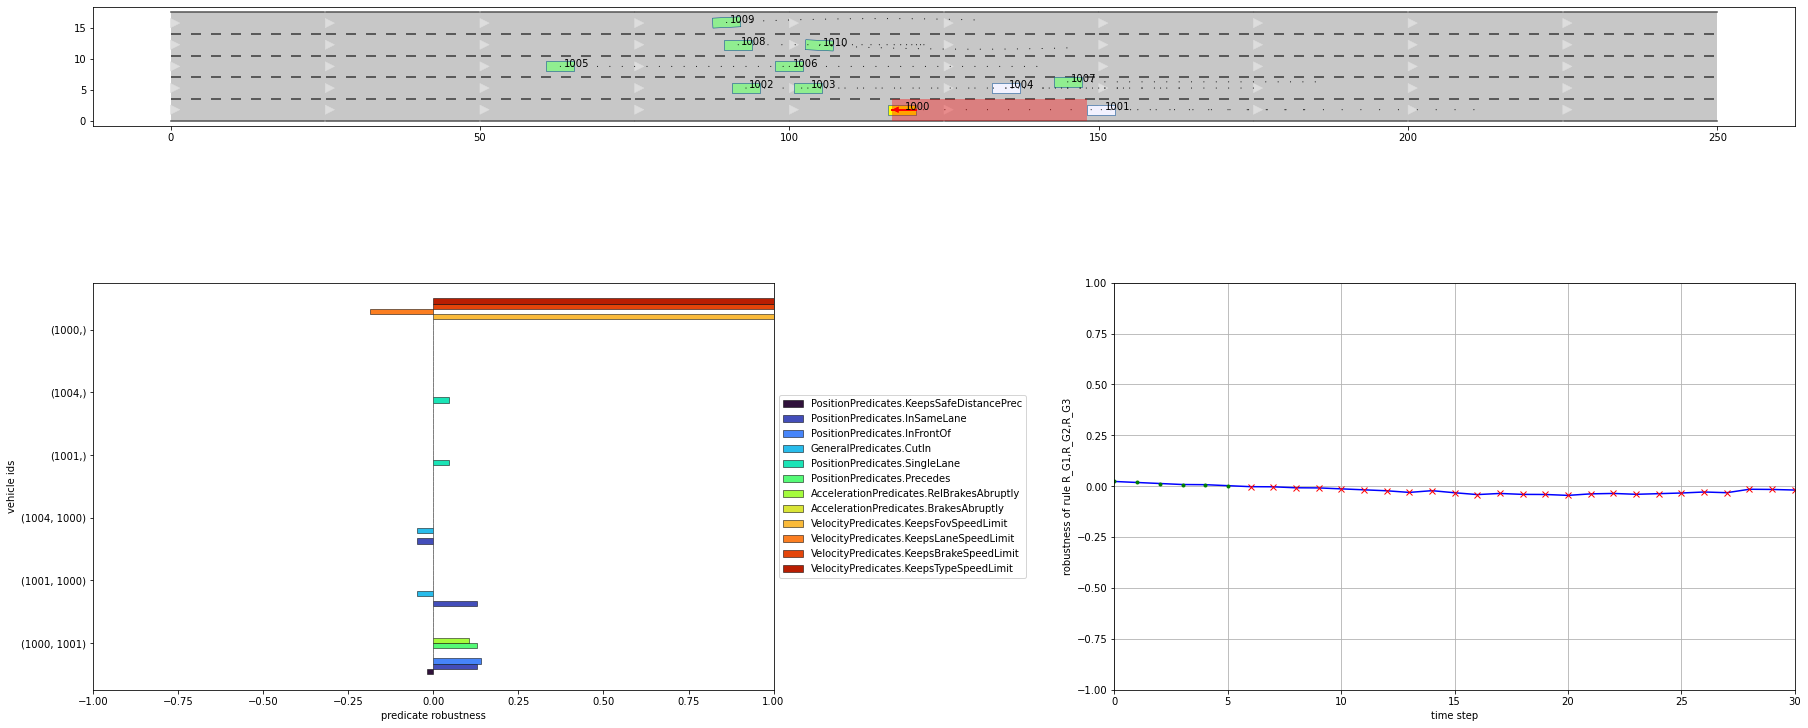

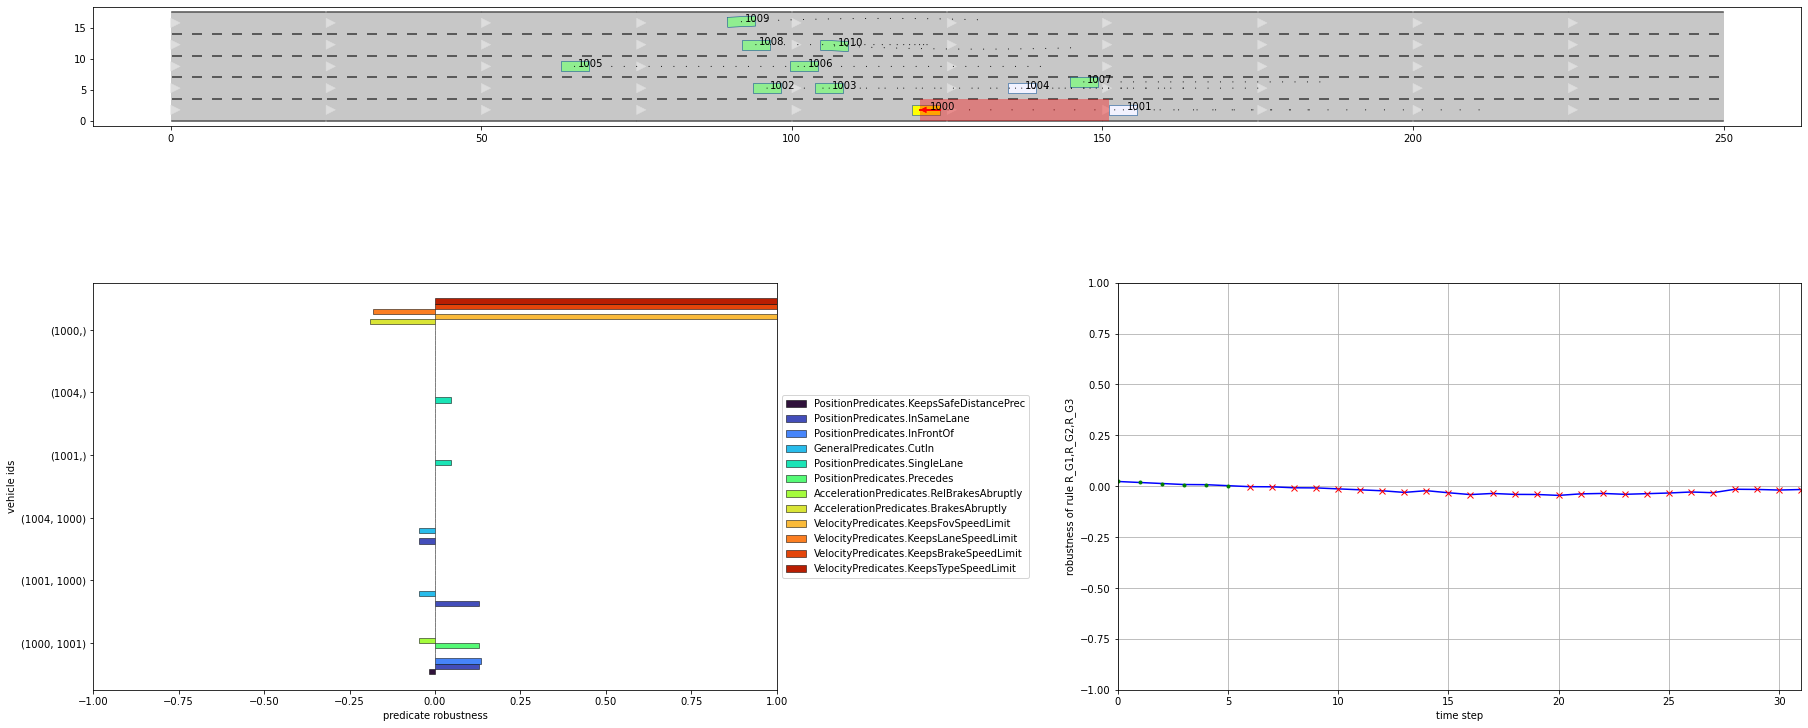

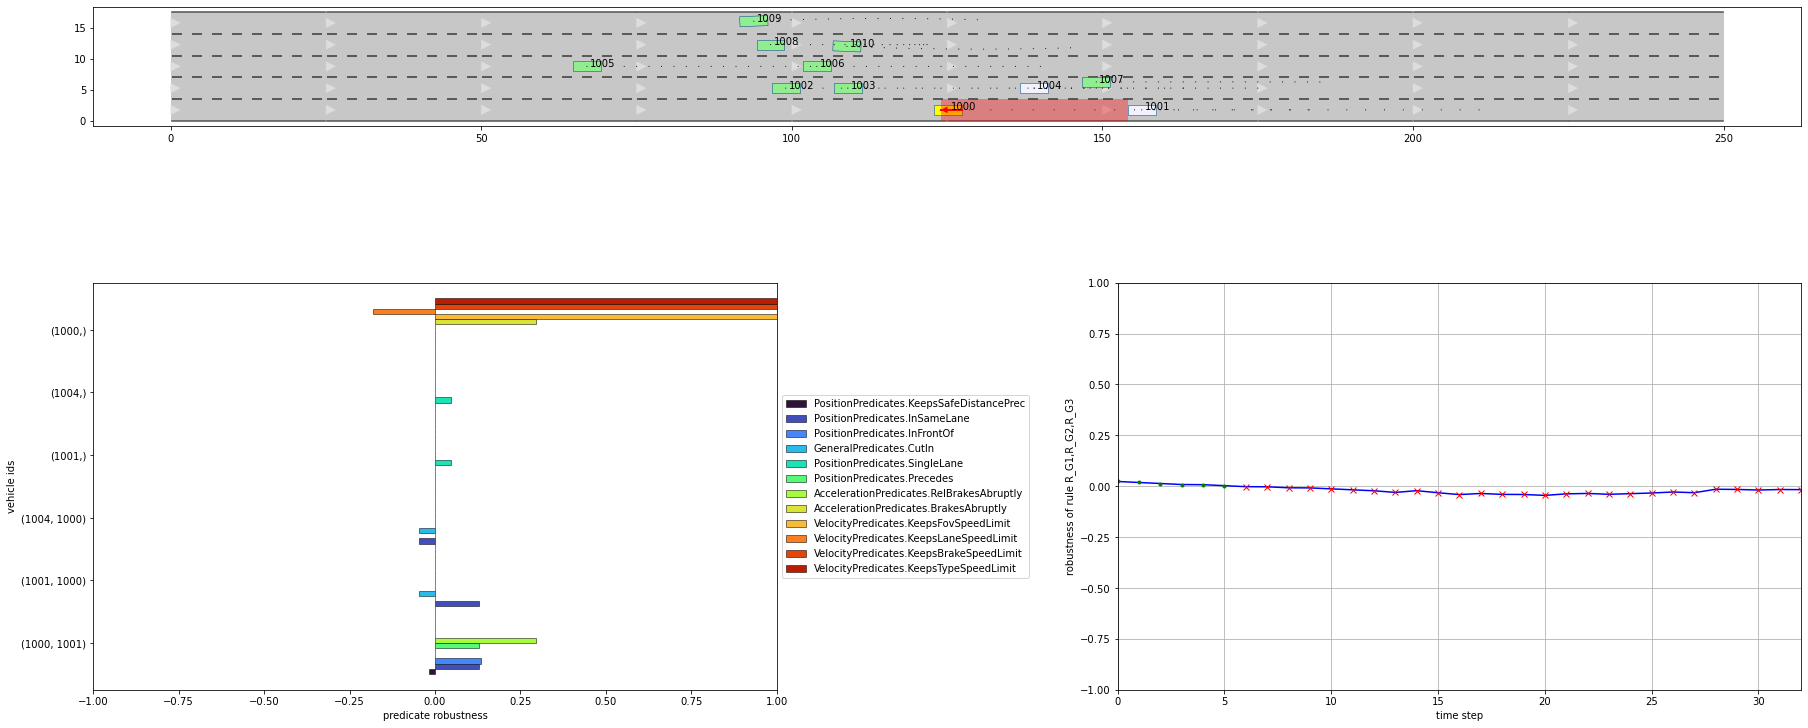

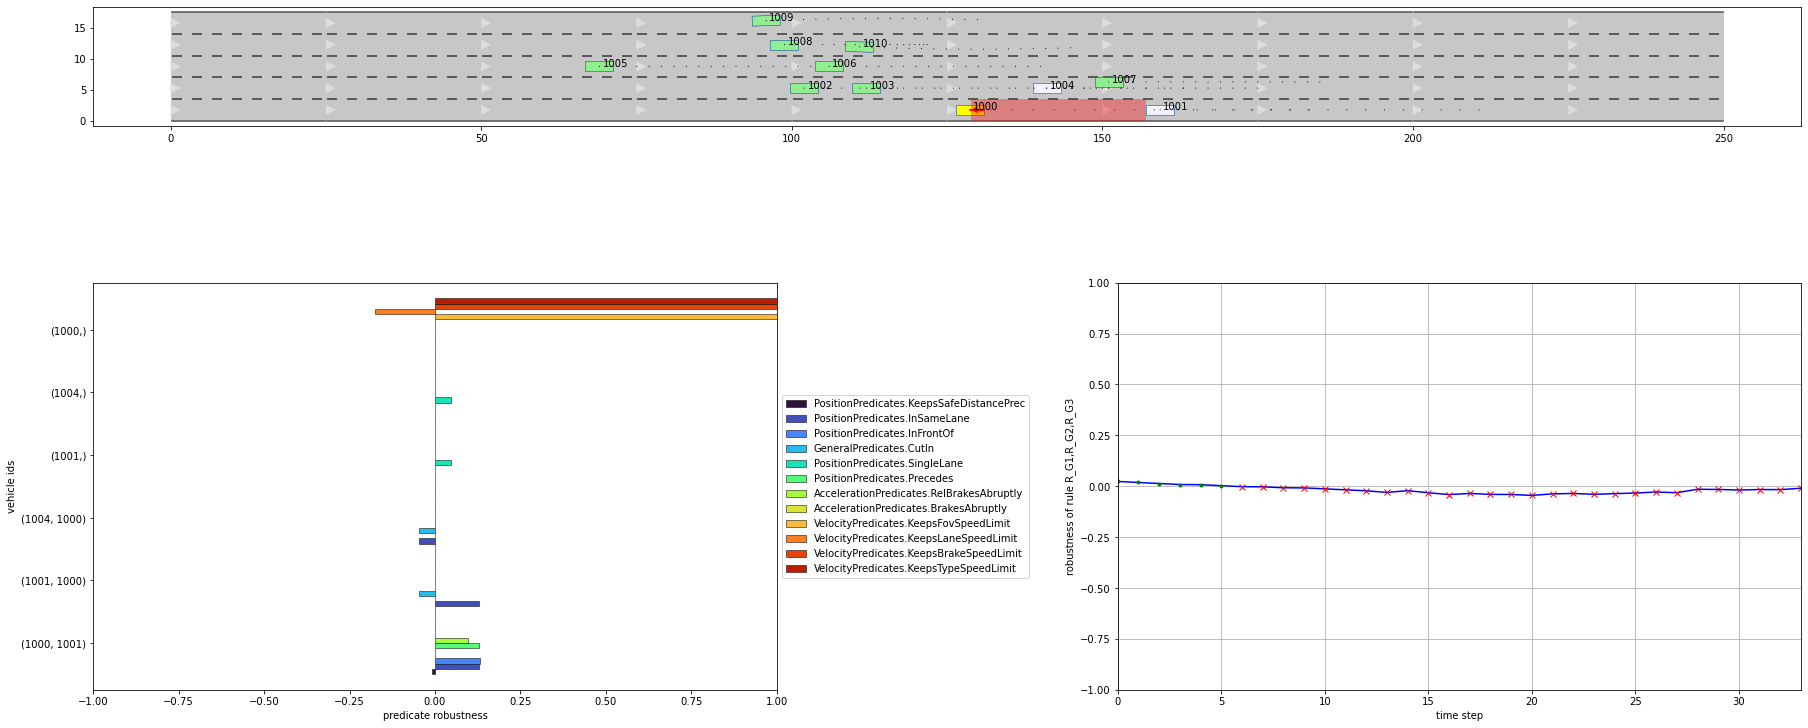

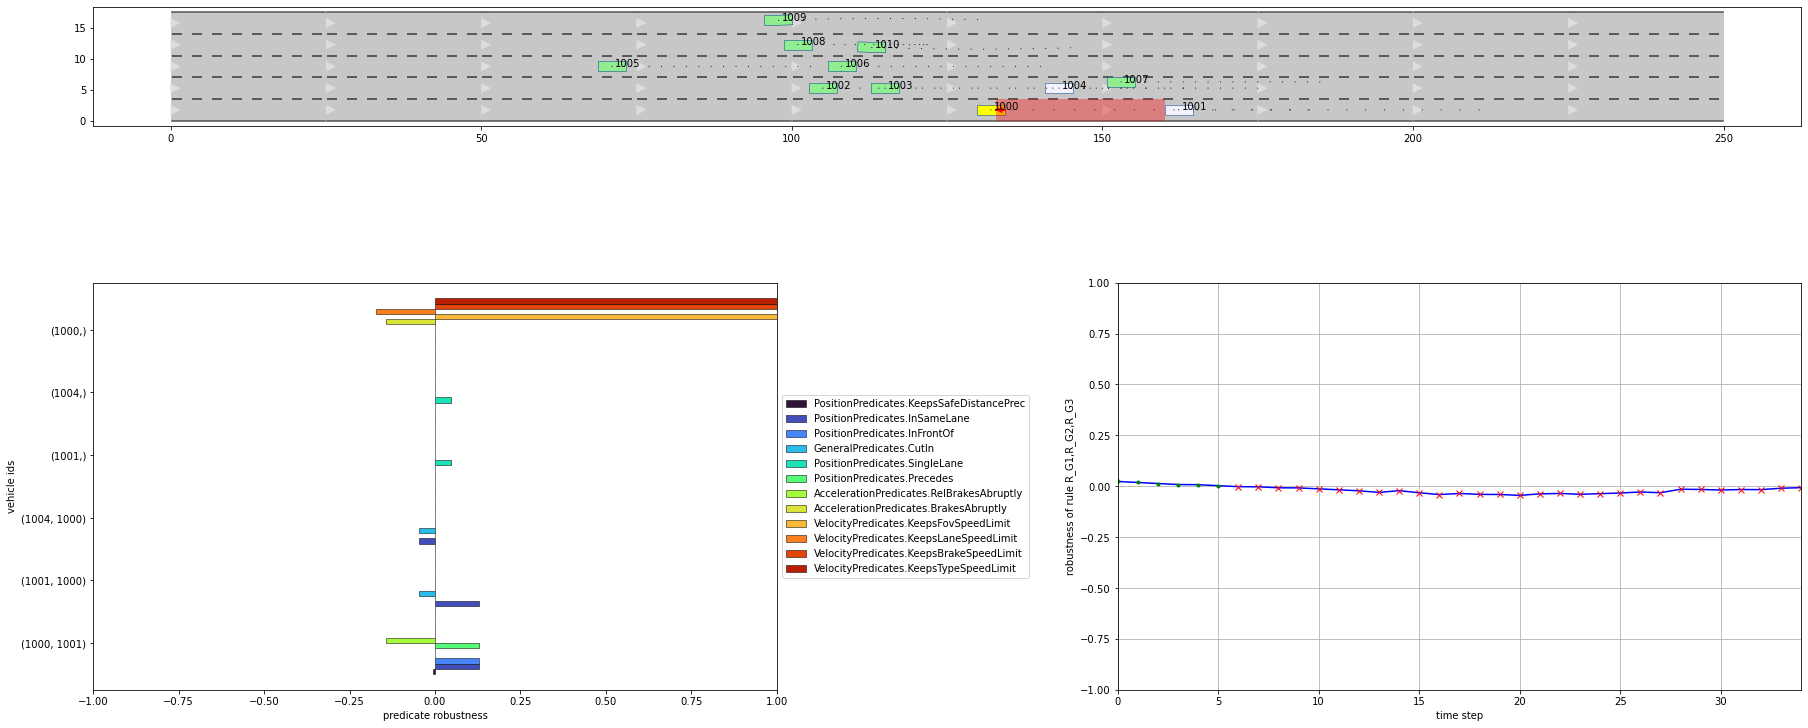

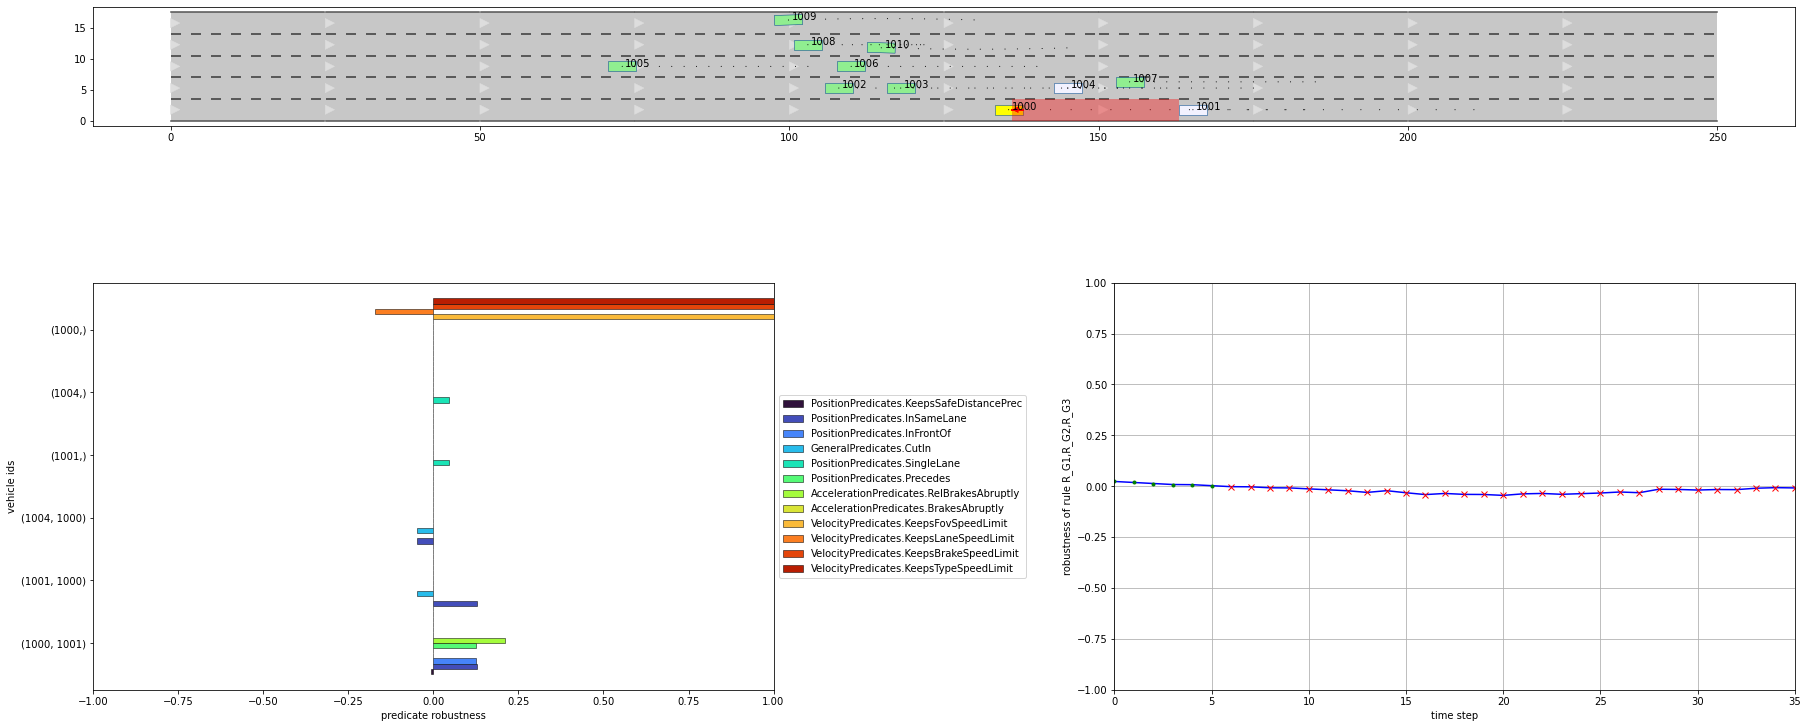

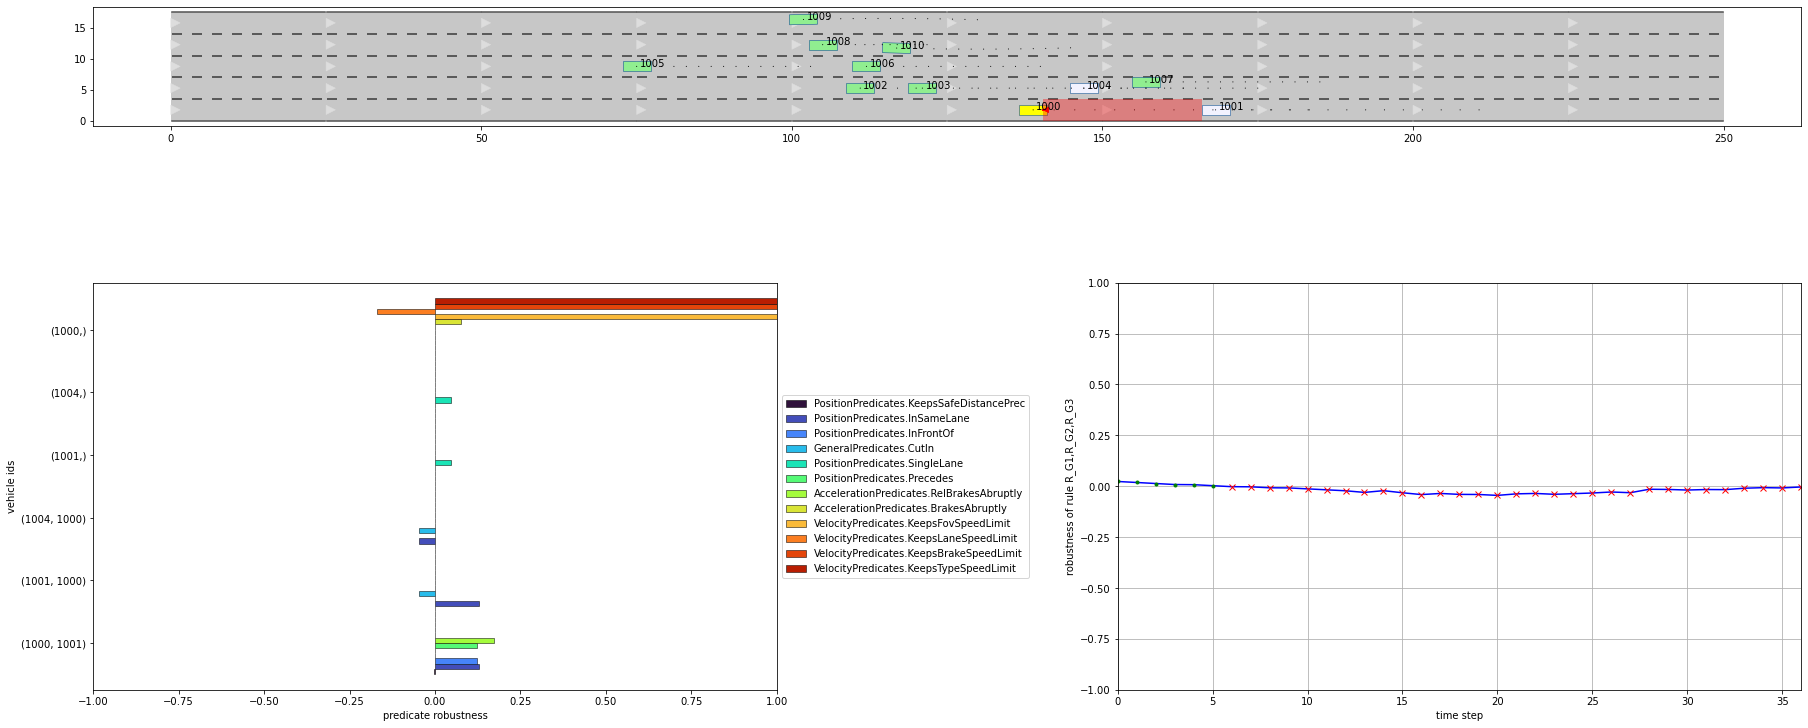

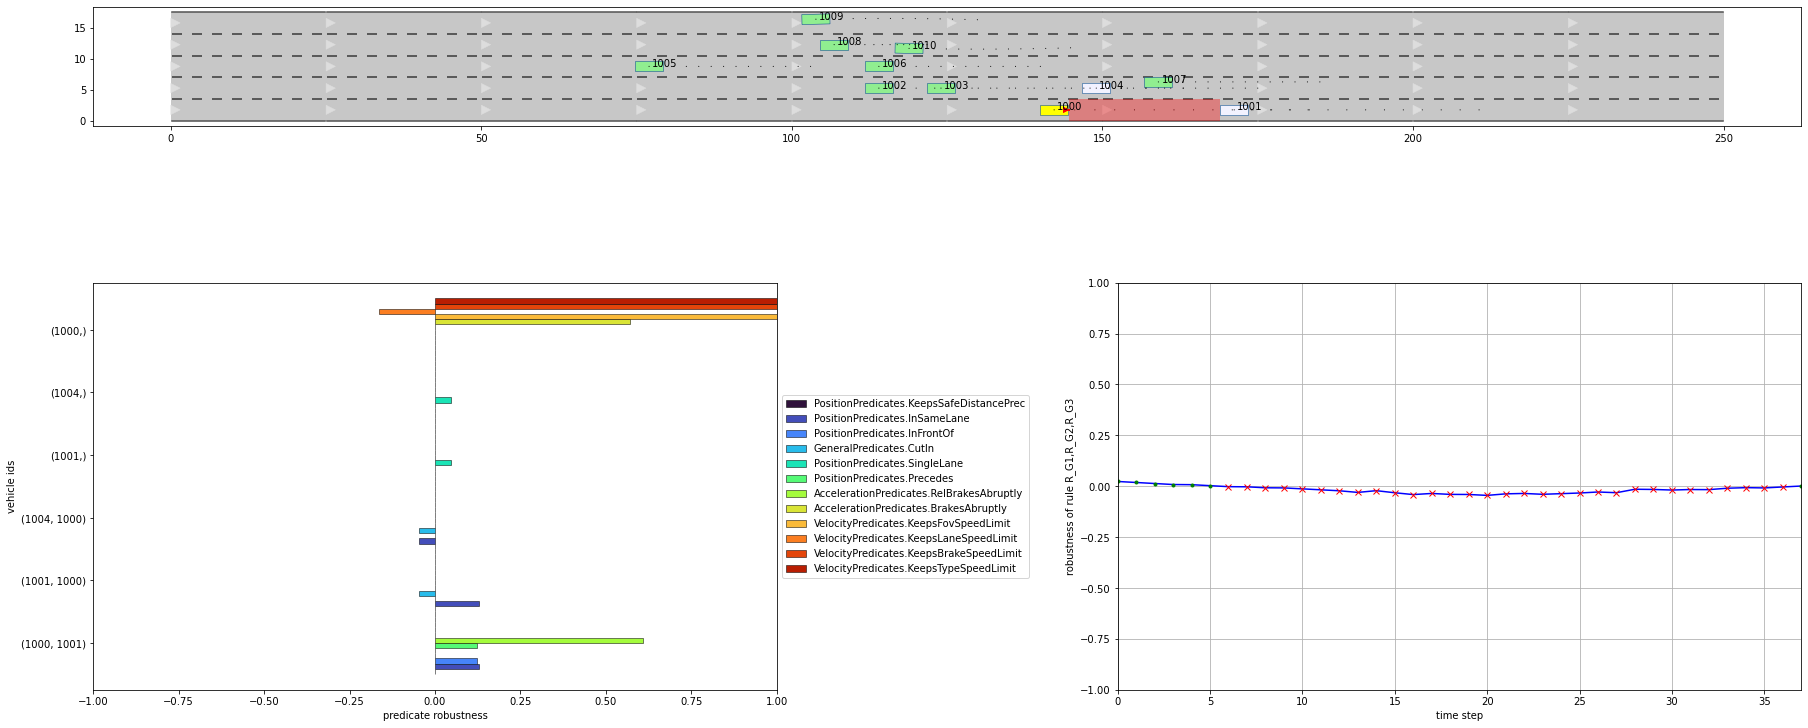

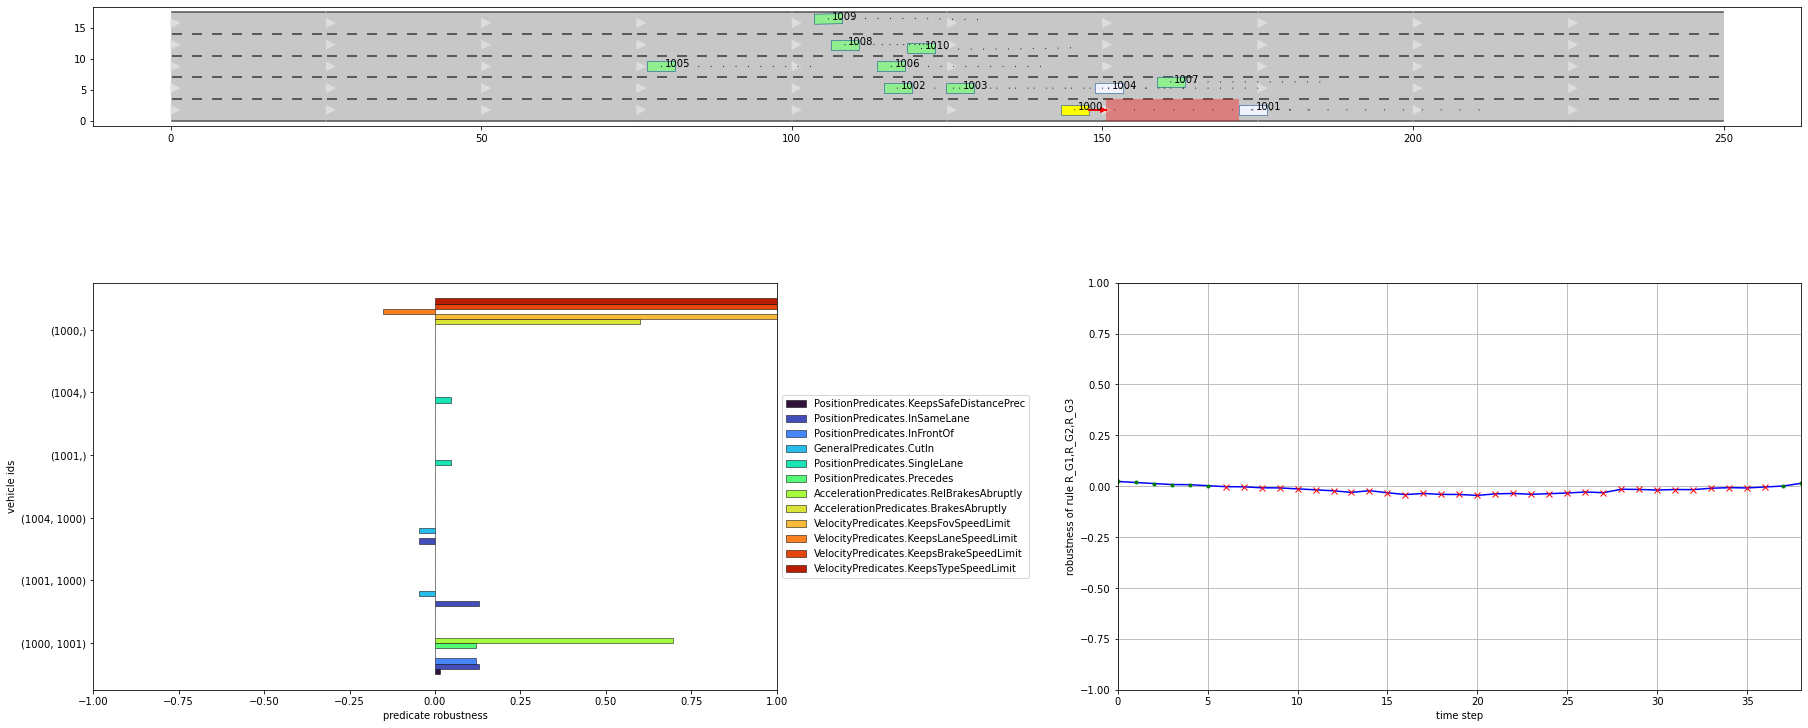

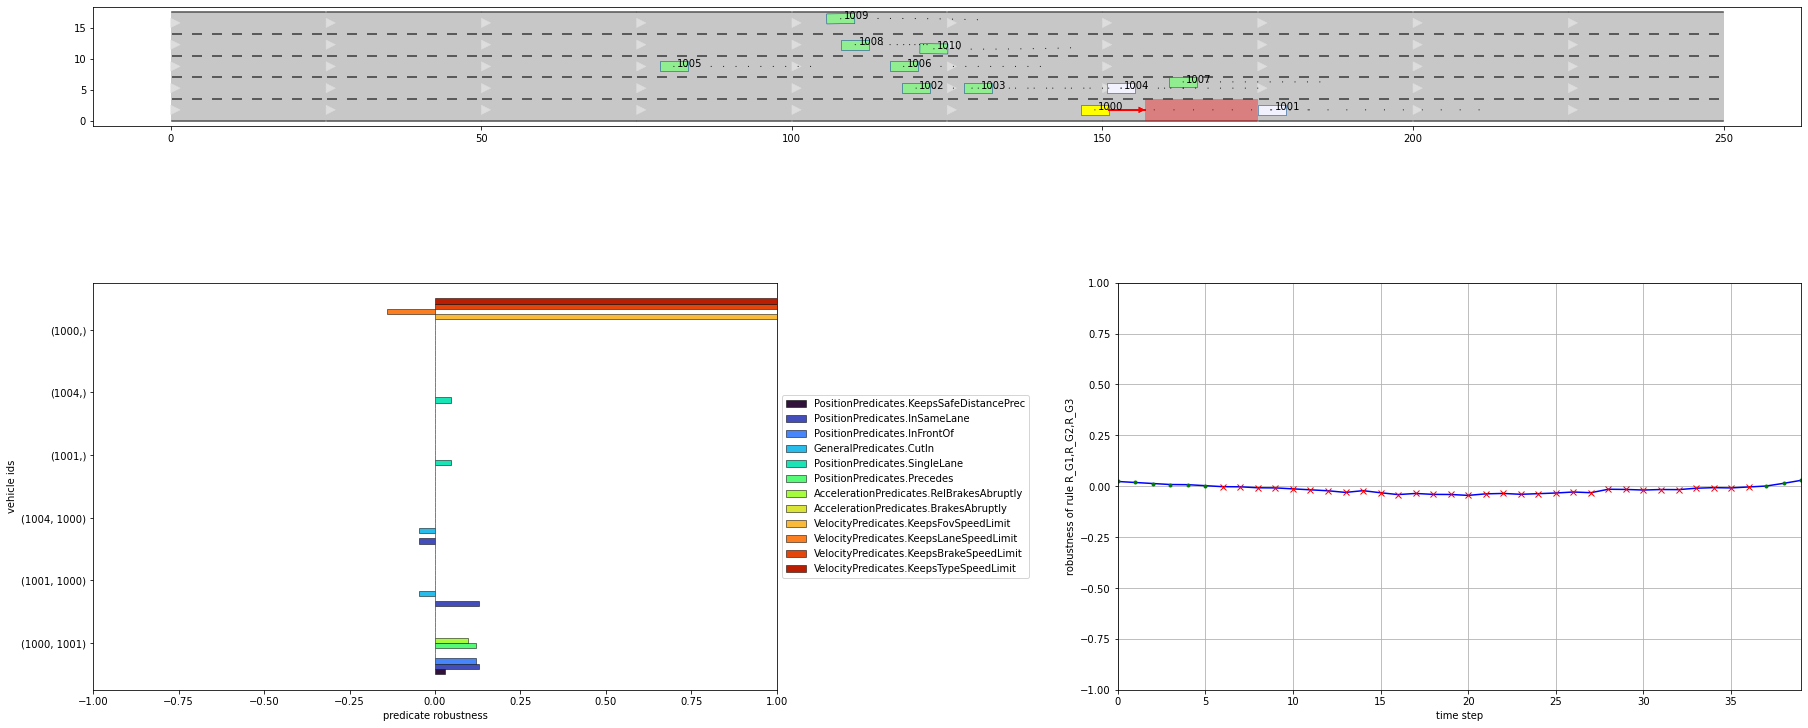

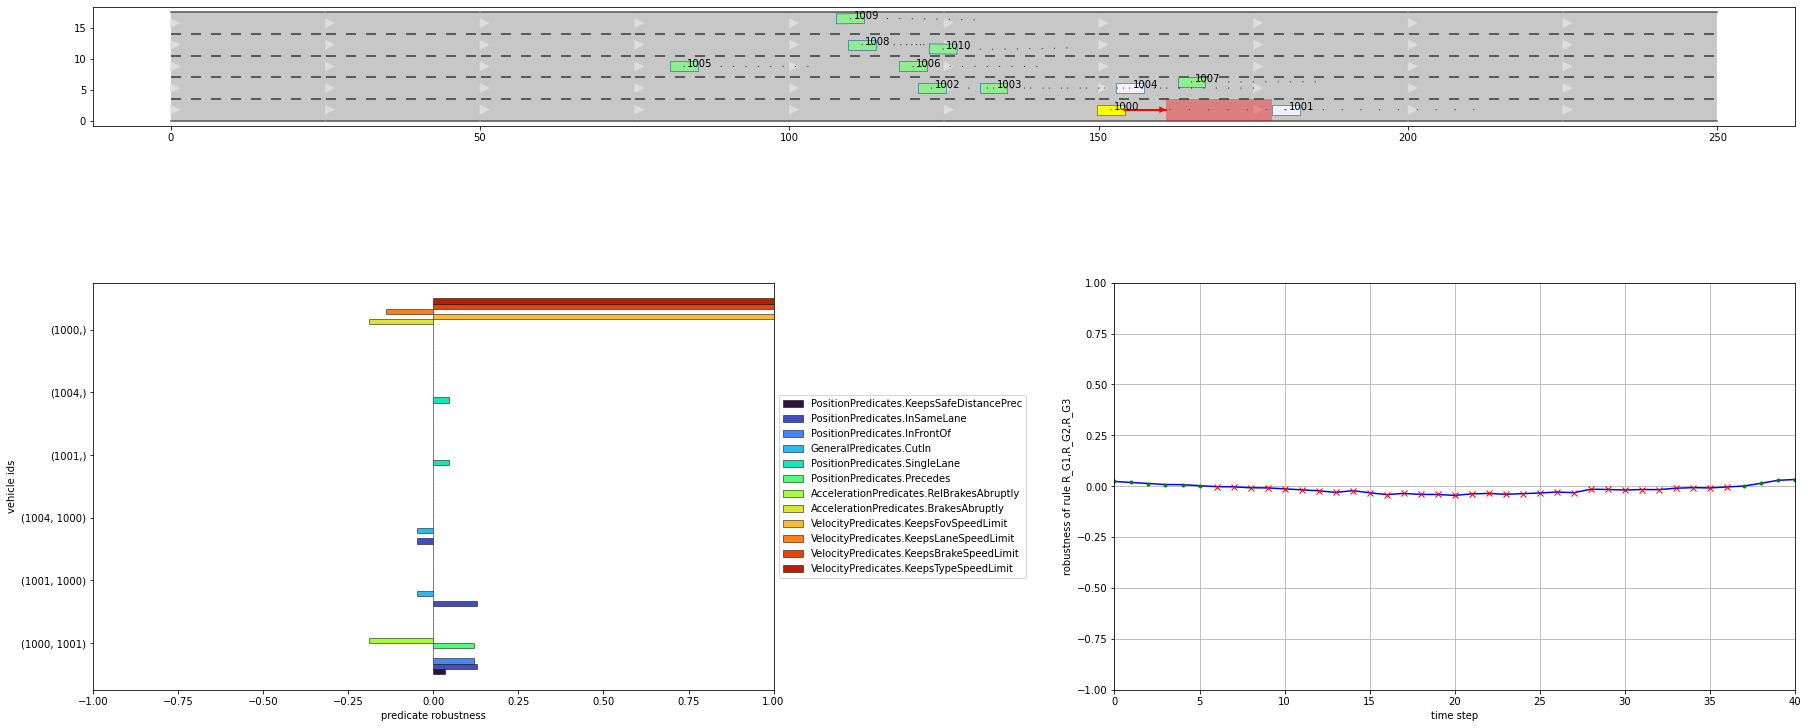

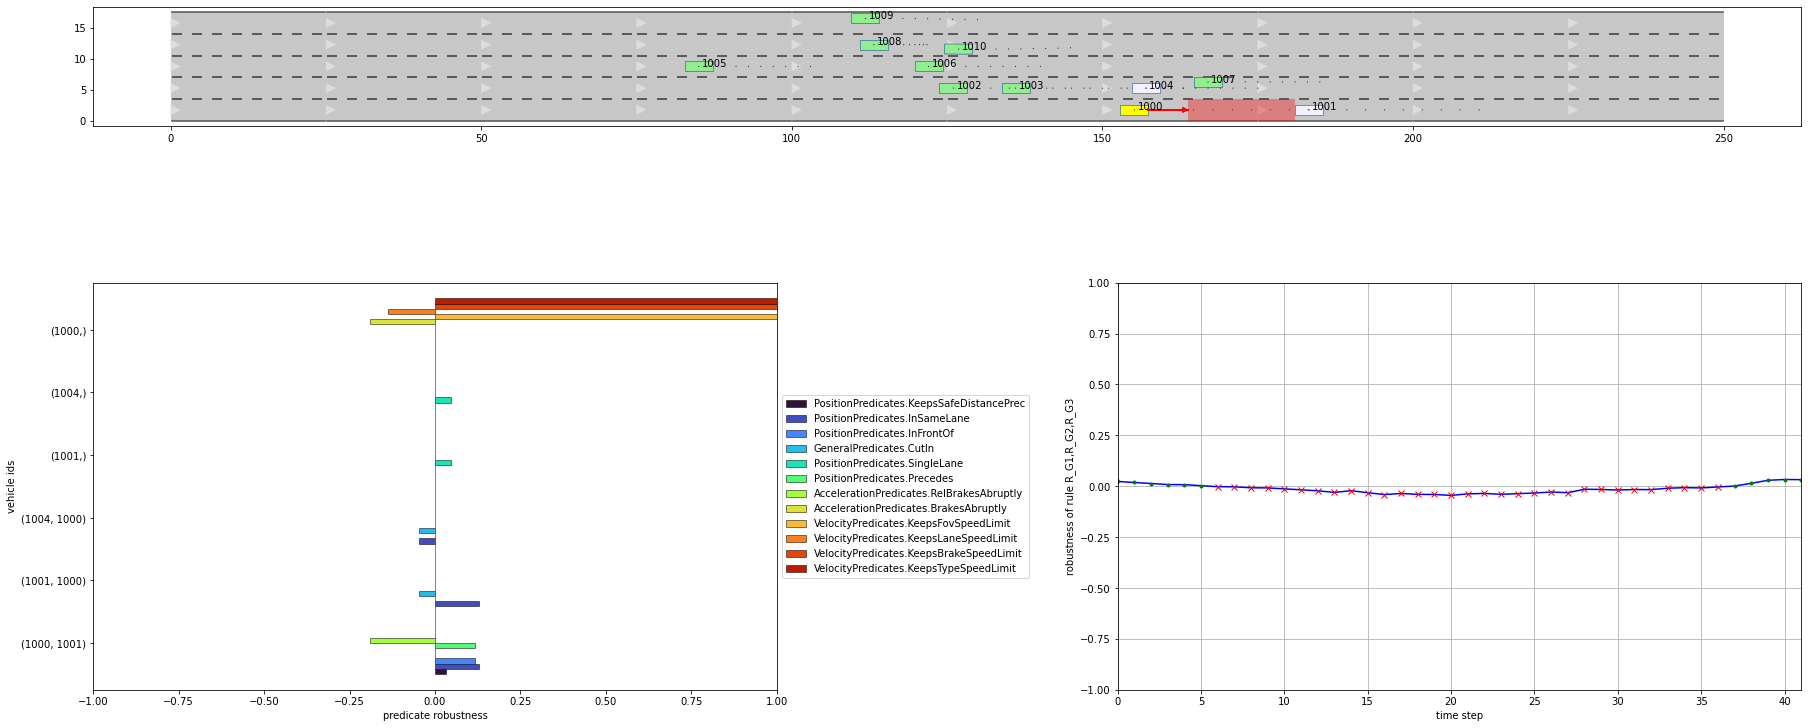

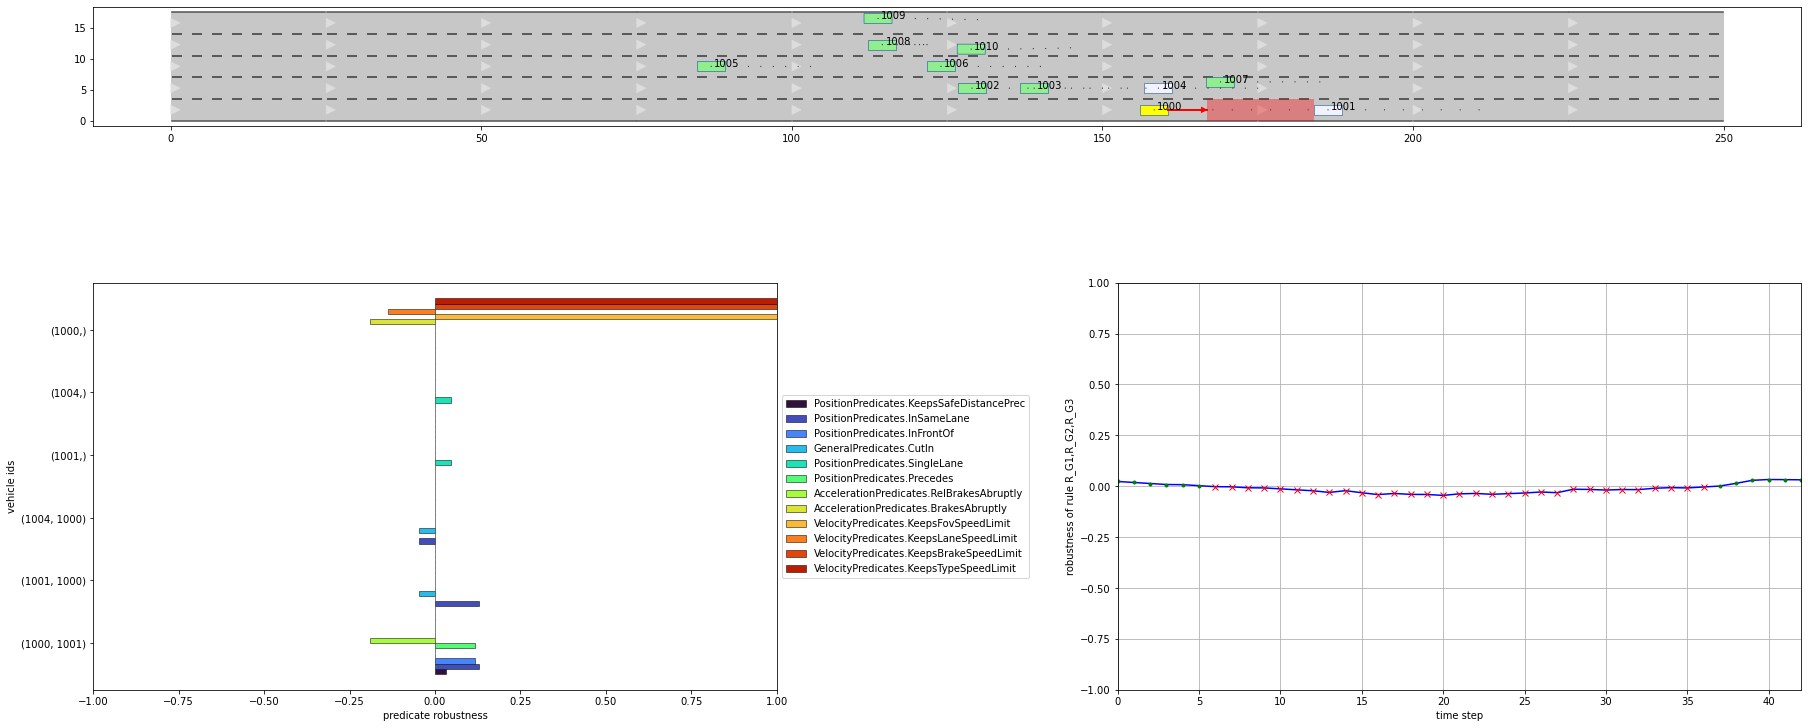

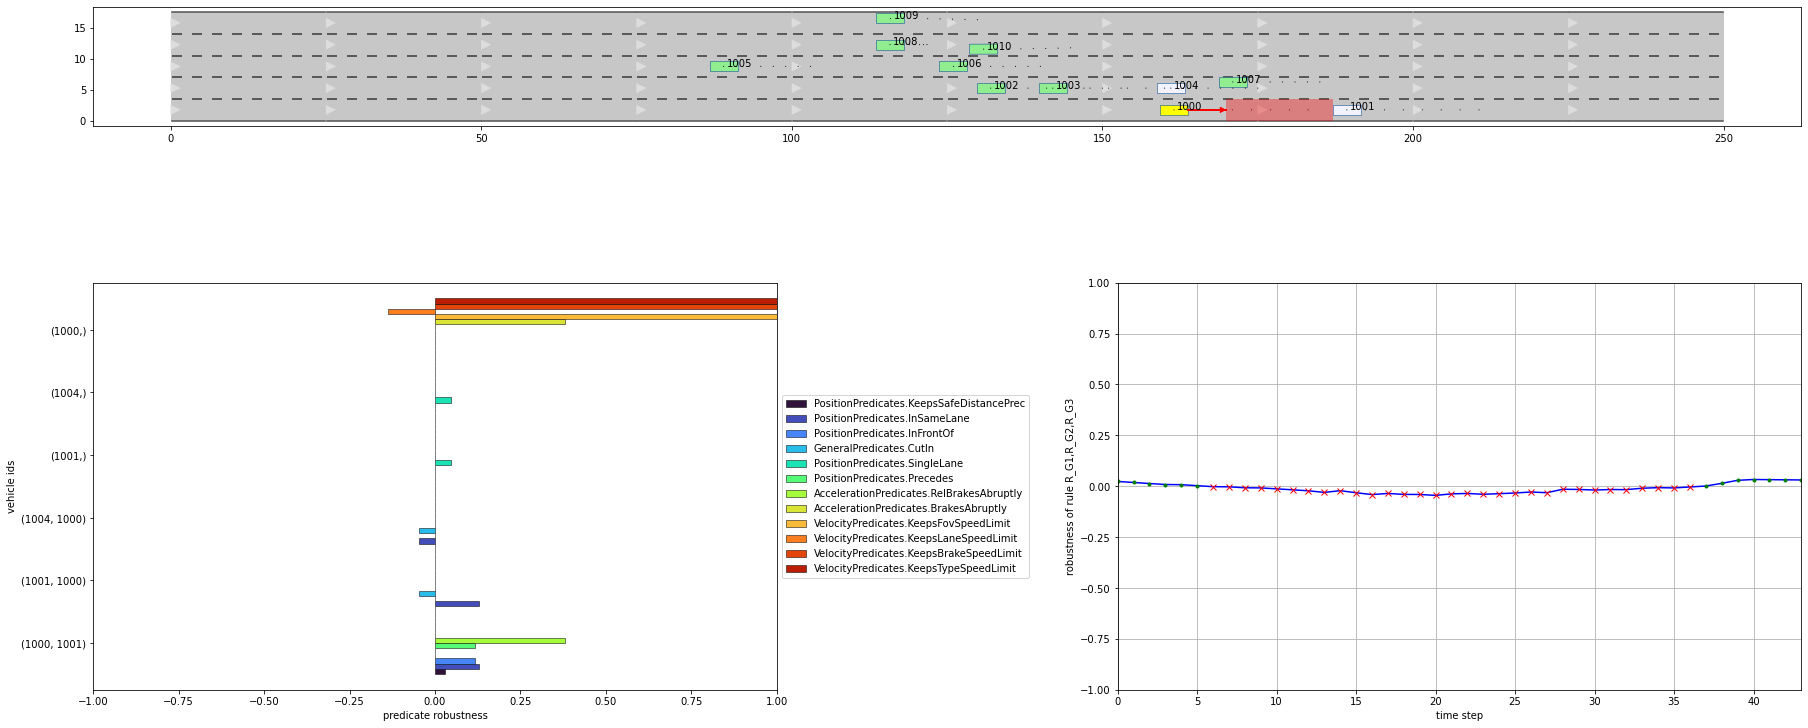

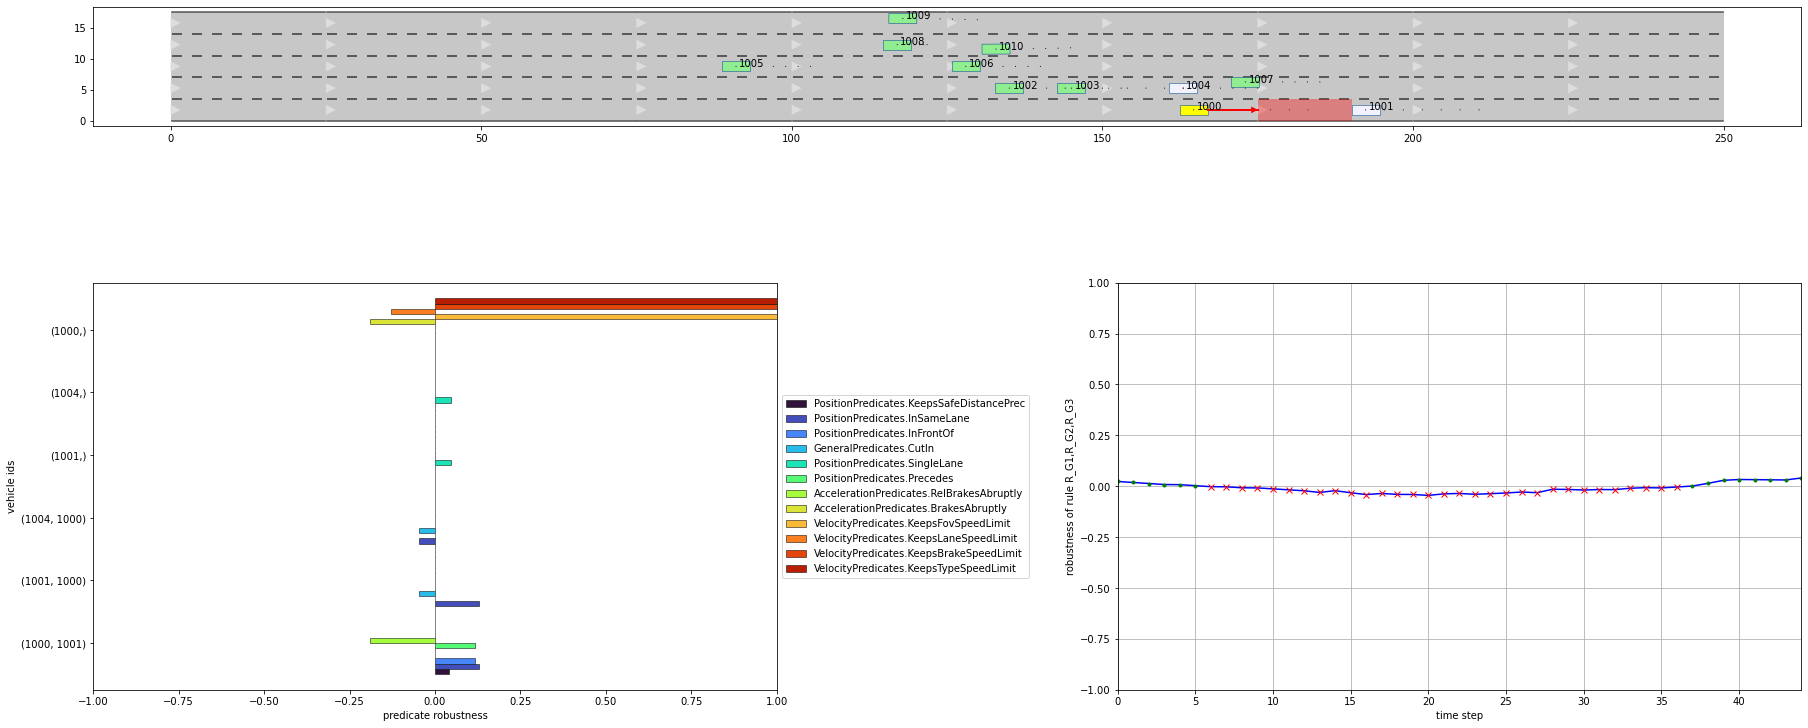

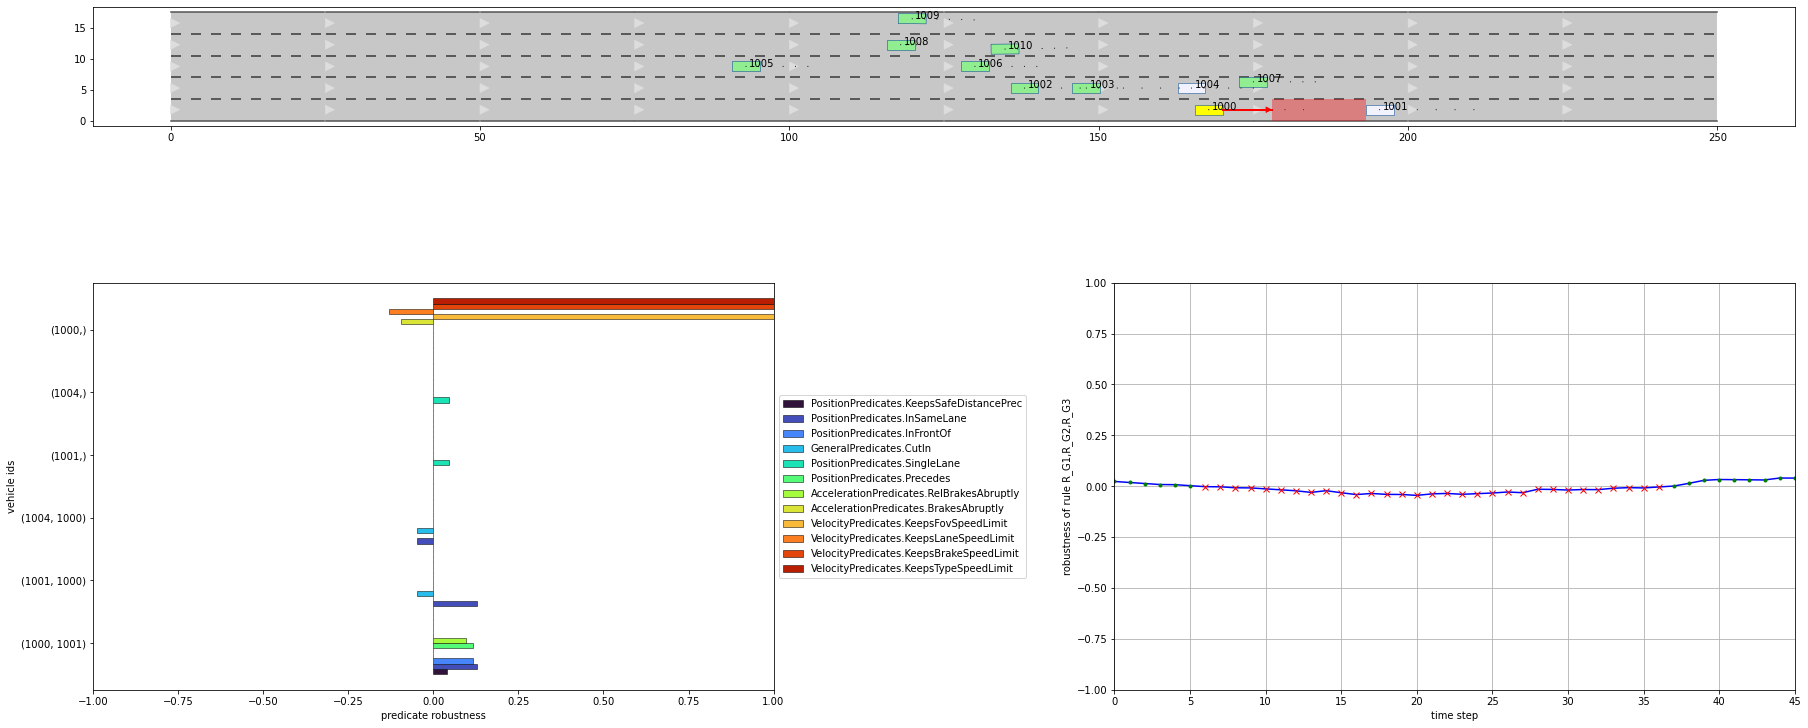

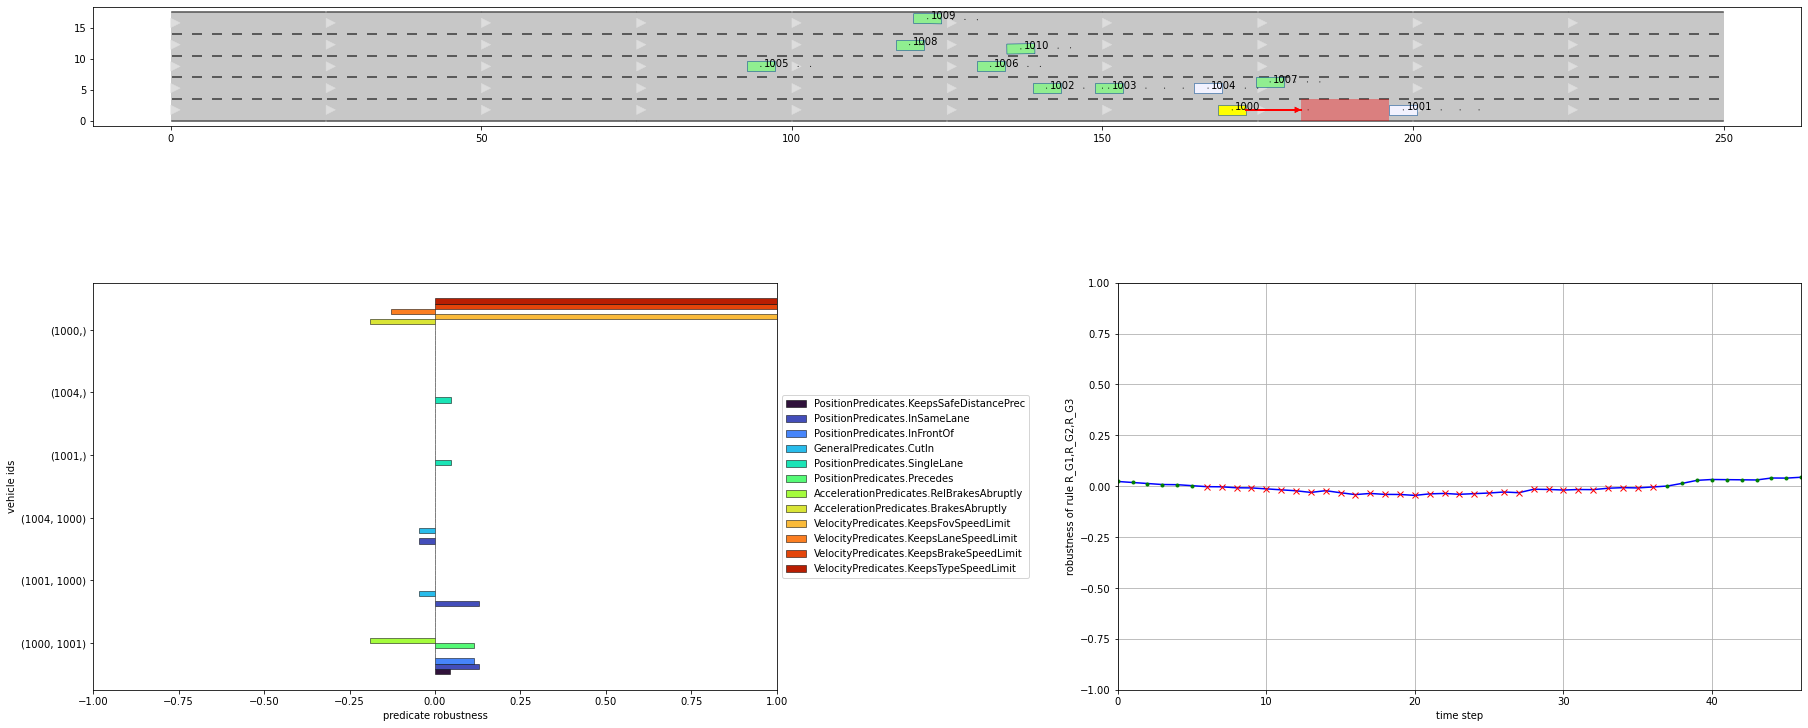

In [ ]:
visualization_config = {
    'cut_in': {
        'show_non_effective_predicate_instances_for_vehicles': [(1004, 1000)] # we want to visualize the cut-in predicate always for the vehicle-pair (1004, 1000),
        # even if the predicate instance is not effective.
    }
}

# For a more quadratic scenario:
# scenario_fig_size=(15., 15.)
# scenario_scale_compared_to_other_plots=4

# For a more rectangular scenario:
scenario_fig_size=(25., 3.)
scenario_scale_compared_to_other_plots=6
# For evaluating all rules together
flag_rule_conjunction=True

current_time_step = 0
while current_time_step < 50:
    plot_rule_visualization(scenario,
                            world_ego_vehicle.id,
                            current_time_step,
                            rule_evaluator_list,
                            visualization_config=visualization_config,
                            scenario_fig_size=scenario_fig_size,
                            bar_chart_plot_limits=(-1.0, 1.0),
                            rule_robustness_course_plot_limits=(-1.0, 1.0),
                            flag_plot_predicate_bar_chart=True,
                            flat_plot_rule_robustness_course=True,
                            scenario_plot_limits=None,
                            flag_rule_conjunction=flag_rule_conjunction
                            )
    current_time_step += 1
    plt.show()